In [1]:
import os
from pathlib import Path

def resolve_input_path(filename):
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path.cwd() / "data" / filename,
        Path.cwd() / "input" / filename,
        Path.cwd() / "inputs" / filename,
        Path("/content") / filename,
        Path("/content/data") / filename,
        Path("outputs") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    return str(Path("/content") / filename) if Path("/content").exists() else filename

def default_output_dir():
    output_dir = Path(os.environ.get("OUTPUT_DIR", "outputs"))
    output_dir.mkdir(parents=True, exist_ok=True)
    return str(output_dir)


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import least_squares

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV

try:
    from IPython.display import display
except Exception:
    display = print


OPTION_PATH = resolve_input_path("option_iv_smart_13_04.csv")
SPOT_RV_PATH = resolve_input_path("result_hope_8_march - Sheet1.csv")
RV_2025_PATH = resolve_input_path("sigma_predictions_2025_h5_bigru.csv")

OUT_DIR = default_output_dir()

DATE_COL_OPT = "trade_date"
DATE_COL_SPOT = "Date"
DATE_COL_RV_2025 = "Date"

TRAIN_START = "2023-01-01"
TRAIN_END   = "2024-12-31"
OOS_START   = "2025-01-01"
OOS_END     = "2025-12-31"


RV_2025_COLS = [
    "sigma_gru_h5_ann",
    "sigma_naive_h5_ann",
    "sigma_mean5_h5_ann",
    "sigma_mean22_h5_ann",
]


HIST_SIGMA_COLS = [
    "hist_sigma_naive_ann",
    "hist_sigma_mean5_ann",
    "hist_sigma_mean22_ann",
]

TRADING_DAYS = 252
RV_HORIZON_DAYS = 5

IV_MIN = 0.01
IV_MAX = 3.00
SIGMA_MIN = 0.001
SIGMA_MAX = 3.00

MIN_T_DAYS = 2
MAX_ABS_MONEYNESS_FOR_FIT = 0.80
MIN_IV_FOR_FIT = 0.01
MAX_IV_FOR_FIT = 3.00


RV_ANCHOR_LAMBDA = 0.70


RUN_SABR = True
SABR_BETA = 1.0
SABR_MIN_POINTS = 4
SABR_MAX_NFEV = 300


RUN_VALIDATION_2024 = True

EPS = 1e-12


def read_csv_smart(path):
    try:
        df = pd.read_csv(path)
        if df.shape[1] > 1:
            return df
    except Exception:
        pass

    for sep in [";", "\t", ","]:
        try:
            df = pd.read_csv(path, sep=sep)
            if df.shape[1] > 1:
                return df
        except Exception:
            continue

    return pd.read_csv(path, sep=None, engine="python")

def to_numeric_safe(s):
    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", ".", regex=False)
         .str.replace("%", "", regex=False)
         .str.replace(" ", "", regex=False),
        errors="coerce"
    )

def to_bool_safe(s):
    if s.dtype == bool:
        return s
    return (
        s.astype(str).str.strip().str.lower()
        .map({
            "true": True, "false": False,
            "1": True, "0": False,
            "yes": True, "no": False,
            "nan": np.nan, "none": np.nan
        })
    )

def parse_date_safe(s):
    return pd.to_datetime(s, errors="coerce", dayfirst=True)

def coalesce_cols(df, cols):
    out = pd.Series(np.nan, index=df.index, dtype=float)
    for c in cols:
        if c in df.columns:
            out = out.fillna(df[c])
    return out

def normalize_option_type(x):
    x = str(x).upper().strip()
    if x in ["C", "CALL"]:
        return "C"
    if x in ["P", "PUT"]:
        return "P"
    return x

def normalize_exercise_type(x):
    x = str(x).upper().strip()
    if x in ["E", "EUROPEAN", "EURO"]:
        return "E"
    if x in ["A", "AMERICAN", "AMER"]:
        return "A"
    return x

def garman_kohlhagen_price(S, K, T, rd, rf, sigma, cp):
    S, K, T, rd, rf, sigma = map(float, [S, K, T, rd, rf, sigma])
    cp = str(cp).upper()

    if not np.isfinite(S + K + T + rd + rf + sigma):
        return np.nan
    if S <= 0 or K <= 0:
        return np.nan

    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0) if cp == "C" else max(K - S, 0.0)

    vol_sqrt = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + (rd - rf + 0.5 * sigma ** 2) * T) / vol_sqrt
    d2 = d1 - vol_sqrt

    if cp == "C":
        return S * np.exp(-rf * T) * norm.cdf(d1) - K * np.exp(-rd * T) * norm.cdf(d2)
    else:
        return K * np.exp(-rd * T) * norm.cdf(-d2) - S * np.exp(-rf * T) * norm.cdf(-d1)

def price_option_row(row, sigma_col):
    return garman_kohlhagen_price(
        S=row["spot_for_pricing"],
        K=row["strike"],
        T=row["T_model"],
        rd=row["rd"],
        rf=row["rf"],
        sigma=row[sigma_col],
        cp=row["option_type"]
    )

def weighted_quadratic_fit(m, y, w=None, ridge=1e-6):
    m = np.asarray(m, dtype=float)
    y = np.asarray(y, dtype=float)

    if w is None:
        w = np.ones_like(y)
    else:
        w = np.asarray(w, dtype=float)

    ok = np.isfinite(m) & np.isfinite(y) & np.isfinite(w)
    m, y, w = m[ok], y[ok], w[ok]

    if len(y) == 0:
        return np.nan, np.nan, np.nan, np.nan

    if len(y) == 1:
        return float(np.clip(y[0], IV_MIN, IV_MAX)), 0.0, 0.0, 0.0

    unique_m = len(np.unique(np.round(m, 8)))

    if unique_m <= 1:
        a = float(np.nanmedian(y))
        return float(np.clip(a, IV_MIN, IV_MAX)), 0.0, 0.0, 0.0

    if len(y) == 2 or unique_m == 2:
        X = np.column_stack([np.ones_like(m), m])
        penalty = np.diag([0.0, ridge])
    else:
        X = np.column_stack([np.ones_like(m), m, m ** 2])
        penalty = np.diag([0.0, ridge, ridge])

    W = np.diag(np.maximum(w, EPS))
    beta = np.linalg.pinv(X.T @ W @ X + penalty) @ (X.T @ W @ y)

    if len(beta) == 2:
        a, b = beta
        c = 0.0
    else:
        a, b, c = beta

    yhat = a + b * m + c * m ** 2
    rmse = float(np.sqrt(np.nanmean((yhat - y) ** 2)))

    if not np.isfinite(a) or a < IV_MIN or a > IV_MAX:
        a = float(y[np.nanargmin(np.abs(m))])

    return float(np.clip(a, IV_MIN, IV_MAX)), float(b), float(c), rmse

def fit_quad_group(g):
    gg = g.copy()
    gg = gg[
        np.isfinite(gg["moneyness"]) &
        np.isfinite(gg["iv"]) &
        (gg["iv"] >= MIN_IV_FOR_FIT) &
        (gg["iv"] <= MAX_IV_FOR_FIT) &
        (gg["moneyness"].abs() <= MAX_ABS_MONEYNESS_FOR_FIT)
    ]

    n = len(gg)

    if n == 0:
        return pd.Series({
            "quad_a": np.nan,
            "quad_b": np.nan,
            "quad_c": np.nan,
            "quad_rmse": np.nan,
            "quad_n": 0
        })

    w = (
        1.0
        + np.log1p(gg["volume"].fillna(0).clip(lower=0))
        + 0.5 * np.log1p(gg["open_interest"].fillna(0).clip(lower=0))
    )

    a, b, c, rmse = weighted_quadratic_fit(
        gg["moneyness"].values,
        gg["iv"].values,
        w.values
    )

    return pd.Series({
        "quad_a": a,
        "quad_b": b,
        "quad_c": c,
        "quad_rmse": rmse,
        "quad_n": n
    })

def sabr_lognormal_vol(F, K, T, alpha, beta, rho, nu):
    F, K, T, alpha, rho, nu = np.broadcast_arrays(
        np.asarray(F, dtype=float),
        np.asarray(K, dtype=float),
        np.asarray(T, dtype=float),
        np.asarray(alpha, dtype=float),
        np.asarray(rho, dtype=float),
        np.asarray(nu, dtype=float)
    )

    F = np.maximum(F, EPS)
    K = np.maximum(K, EPS)
    T = np.maximum(T, EPS)
    alpha = np.maximum(alpha, EPS)
    nu = np.maximum(nu, EPS)
    rho = np.clip(rho, -0.999, 0.999)

    beta = float(beta)
    one_minus_beta = 1.0 - beta

    logFK = np.log(F / K)
    FK_beta = (F * K) ** (one_minus_beta / 2.0)

    denom = FK_beta * (
        1.0
        + (one_minus_beta ** 2 / 24.0) * logFK ** 2
        + (one_minus_beta ** 4 / 1920.0) * logFK ** 4
    )

    z = (nu / alpha) * FK_beta * logFK

    sqrt_term = np.sqrt(np.maximum(1.0 - 2.0 * rho * z + z ** 2, EPS))
    x_z = np.log((sqrt_term + z - rho) / (1.0 - rho))

    z_over_xz = np.where(
        np.abs(z) < 1e-8,
        1.0,
        z / np.where(np.abs(x_z) < EPS, EPS, x_z)
    )

    correction = 1.0 + (
        (one_minus_beta ** 2 / 24.0) * (alpha ** 2 / (FK_beta ** 2))
        + (rho * beta * nu * alpha) / (4.0 * FK_beta)
        + ((2.0 - 3.0 * rho ** 2) * nu ** 2) / 24.0
    ) * T

    vol = (alpha / denom) * z_over_xz * correction
    return np.asarray(vol, dtype=float)

def fit_sabr_group(g):
    gg = g.copy()
    gg = gg[
        np.isfinite(gg["forward_for_pricing"]) &
        np.isfinite(gg["strike"]) &
        np.isfinite(gg["T_model"]) &
        np.isfinite(gg["iv"]) &
        (gg["forward_for_pricing"] > 0) &
        (gg["strike"] > 0) &
        (gg["T_model"] > 0) &
        (gg["iv"] >= MIN_IV_FOR_FIT) &
        (gg["iv"] <= MAX_IV_FOR_FIT) &
        (gg["moneyness"].abs() <= MAX_ABS_MONEYNESS_FOR_FIT)
    ]

    n = len(gg)
    unique_k = gg["strike"].nunique()

    if n < SABR_MIN_POINTS or unique_k < SABR_MIN_POINTS:
        return pd.Series({
            "sabr_alpha": np.nan,
            "sabr_rho": np.nan,
            "sabr_nu": np.nan,
            "sabr_rmse": np.nan,
            "sabr_n": n,
            "sabr_ok": False
        })

    F = float(np.nanmedian(gg["forward_for_pricing"]))
    T = float(np.nanmedian(gg["T_model"]))
    K = gg["strike"].values.astype(float)
    y = gg["iv"].values.astype(float)

    w = (
        1.0
        + np.log1p(gg["volume"].fillna(0).clip(lower=0))
        + 0.5 * np.log1p(gg["open_interest"].fillna(0).clip(lower=0))
    )
    w = np.sqrt(np.maximum(w.values.astype(float), EPS))

    atm_guess = float(y[np.argmin(np.abs(np.log(K / F)))])
    atm_guess = np.clip(atm_guess, IV_MIN, IV_MAX)

    alpha0 = atm_guess * (F ** (1.0 - SABR_BETA))
    rho0 = 0.0
    nu0 = 0.50

    def unpack(x):
        alpha = np.exp(x[0])
        rho = np.tanh(x[1])
        nu = np.exp(x[2])
        return alpha, rho, nu

    def residuals(x):
        alpha, rho, nu = unpack(x)
        pred = sabr_lognormal_vol(F, K, T, alpha, SABR_BETA, rho, nu)
        return w * (pred - y)

    x0 = np.array([
        np.log(np.clip(alpha0, 1e-4, 5.0)),
        np.arctanh(np.clip(rho0, -0.95, 0.95)),
        np.log(np.clip(nu0, 1e-4, 5.0))
    ])

    lower = np.array([np.log(1e-4), np.arctanh(-0.95), np.log(1e-4)])
    upper = np.array([np.log(5.0),  np.arctanh(0.95),  np.log(5.0)])

    try:
        res = least_squares(
            residuals,
            x0=x0,
            bounds=(lower, upper),
            max_nfev=SABR_MAX_NFEV,
            xtol=1e-8,
            ftol=1e-8,
            gtol=1e-8
        )

        alpha, rho, nu = unpack(res.x)
        pred = sabr_lognormal_vol(F, K, T, alpha, SABR_BETA, rho, nu)
        rmse = float(np.sqrt(np.nanmean((pred - y) ** 2)))

        return pd.Series({
            "sabr_alpha": float(alpha),
            "sabr_rho": float(rho),
            "sabr_nu": float(nu),
            "sabr_rmse": rmse,
            "sabr_n": n,
            "sabr_ok": bool(res.success)
        })

    except Exception:
        return pd.Series({
            "sabr_alpha": np.nan,
            "sabr_rho": np.nan,
            "sabr_nu": np.nan,
            "sabr_rmse": np.nan,
            "sabr_n": n,
            "sabr_ok": False
        })

def merge_lag_by_group(left, right, by_col, value_cols, prefix):
    out_parts = []

    right = right.copy()
    right["shape_date"] = pd.to_datetime(right["shape_date"], errors="coerce")

    for key, lgrp in left.groupby(by_col, dropna=False, observed=False):
        lgrp = lgrp.sort_values(DATE_COL_OPT).copy()

        if pd.isna(key):
            rgrp = right[right[by_col].isna()].copy()
        else:
            rgrp = right[right[by_col] == key].copy()

        rgrp = rgrp.sort_values("shape_date")
        rgrp = rgrp[["shape_date"] + value_cols].copy()

        if len(rgrp) == 0:
            for c in value_cols:
                lgrp[f"{prefix}_{c}_lag"] = np.nan
            lgrp[f"{prefix}_shape_date_lag"] = pd.NaT
        else:
            merged = pd.merge_asof(
                lgrp,
                rgrp,
                left_on=DATE_COL_OPT,
                right_on="shape_date",
                direction="backward",
                allow_exact_matches=False
            )

            for c in value_cols:
                merged.rename(columns={c: f"{prefix}_{c}_lag"}, inplace=True)

            merged.rename(columns={"shape_date": f"{prefix}_shape_date_lag"}, inplace=True)
            lgrp = merged

        out_parts.append(lgrp)

    return pd.concat(out_parts, ignore_index=True)

def calc_metrics(df, price_col, label=None):
    d = df[[price_col, "market_price"]].replace([np.inf, -np.inf], np.nan).dropna()
    d = d[d["market_price"] > 0]

    if len(d) == 0:
        return {
            "model": label or price_col,
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "MedianAE": np.nan,
            "WMAPE_pct": np.nan
        }

    err = d[price_col] - d["market_price"]

    return {
        "model": label or price_col,
        "n": len(d),
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "Bias": float(np.mean(err)),
        "MedianAE": float(np.median(np.abs(err))),
        "WMAPE_pct": float(100.0 * np.sum(np.abs(err)) / np.sum(np.abs(d["market_price"])))
    }

def calc_iv_metrics(df, iv_col, label=None):
    d = df[[iv_col, "iv"]].replace([np.inf, -np.inf], np.nan).dropna()

    if len(d) == 0:
        return {
            "model": label or iv_col,
            "n": 0,
            "IV_MAE": np.nan,
            "IV_RMSE": np.nan,
            "IV_Bias": np.nan
        }

    err = d[iv_col] - d["iv"]

    return {
        "model": label or iv_col,
        "n": len(d),
        "IV_MAE": float(np.mean(np.abs(err))),
        "IV_RMSE": float(np.sqrt(np.mean(err ** 2))),
        "IV_Bias": float(np.mean(err))
    }


opt = read_csv_smart(OPTION_PATH)
spot_rv = read_csv_smart(SPOT_RV_PATH)
rv_2025 = read_csv_smart(RV_2025_PATH)

for df_ in [opt, spot_rv, rv_2025]:
    drop_cols = [c for c in df_.columns if str(c).lower().startswith("unnamed")]
    if drop_cols:
        df_.drop(columns=drop_cols, inplace=True)


opt[DATE_COL_OPT] = pd.to_datetime(
    opt[DATE_COL_OPT],
    errors="coerce",
    format="%Y-%m-%d"
)

opt["expiration_date"] = pd.to_datetime(
    opt["expiration_date"],
    errors="coerce",
    format="%Y-%m-%d"
)


spot_rv[DATE_COL_SPOT] = pd.to_datetime(
    spot_rv[DATE_COL_SPOT],
    errors="coerce",
    dayfirst=True
)


rv_2025[DATE_COL_RV_2025] = pd.to_datetime(
    rv_2025[DATE_COL_RV_2025],
    errors="coerce",
    format="%Y-%m-%d"
)


numeric_cols_opt = [
    "strike", "T_days", "T", "T_exact", "T_used",
    "first_trade_price", "last_trade_price", "settle_price",
    "volume", "open_interest", "market_price",
    "spot", "spot_used",
    "r_foreign", "r_domestic", "rd_used", "rf_used",
    "iv", "iv_pct"
]

for c in numeric_cols_opt:
    if c in opt.columns:
        opt[c] = to_numeric_safe(opt[c])

for c in ["RV_gk", "target_RV_gk", "target_vol_gk"]:
    if c in spot_rv.columns:
        spot_rv[c] = to_numeric_safe(spot_rv[c])

for c in RV_2025_COLS:
    if c in rv_2025.columns:
        rv_2025[c] = to_numeric_safe(rv_2025[c])

if "iv_found" in opt.columns:
    opt["iv_found"] = to_bool_safe(opt["iv_found"]).fillna(False)
else:
    opt["iv_found"] = True


opt["option_type"] = opt["option_type"].apply(normalize_option_type)
opt["exercise_type"] = opt["exercise_type"].apply(normalize_exercise_type)

opt["T_model"] = coalesce_cols(opt, ["T_used", "T_exact", "T"])
opt["rd"] = coalesce_cols(opt, ["rd_used", "r_domestic"])
opt["rf"] = coalesce_cols(opt, ["rf_used", "r_foreign"])
opt["spot_for_pricing"] = coalesce_cols(opt, ["spot_used", "spot"])


opt["forward_for_pricing"] = opt["spot_for_pricing"] * np.exp((opt["rd"] - opt["rf"]) * opt["T_model"])
opt["moneyness"] = np.log(opt["strike"] / opt["forward_for_pricing"])

bins = [0, 7, 14, 30, 60, 90, 180, 365, 10_000]
labels = ["0-7d", "8-14d", "15-30d", "31-60d", "61-90d", "91-180d", "181-365d", "365d+"]
opt["maturity_bucket"] = pd.cut(opt["T_days"], bins=bins, labels=labels, include_lowest=True)


CNYP_SEARCH_COLS = [
    "secid_raw",
    "secid_norm",
    "underlying_series",
    "instrument_family",
    "source_file",
    "iv_model",
    "iv_note",
]

cnyp_mask = pd.Series(False, index=opt.index)

for c in CNYP_SEARCH_COLS:
    if c in opt.columns:
        cnyp_mask |= opt[c].astype(str).str.upper().str.contains("CNYP", regex=False, na=False)

european_mask = opt["exercise_type"].eq("E")

base_mask = (
    opt[DATE_COL_OPT].notna() &
    opt["expiration_date"].notna() &
    opt["iv_found"].fillna(False) &
    cnyp_mask &
    european_mask &
    np.isfinite(opt["iv"]) &
    np.isfinite(opt["market_price"]) &
    np.isfinite(opt["strike"]) &
    np.isfinite(opt["T_model"]) &
    np.isfinite(opt["rd"]) &
    np.isfinite(opt["rf"]) &
    np.isfinite(opt["spot_for_pricing"]) &
    np.isfinite(opt["forward_for_pricing"]) &
    (opt["iv"] >= IV_MIN) &
    (opt["iv"] <= IV_MAX) &
    (opt["market_price"] > 0) &
    (opt["strike"] > 0) &
    (opt["T_model"] > 0) &
    (opt["T_days"] >= MIN_T_DAYS) &
    (opt["spot_for_pricing"] > 0) &
    (opt["forward_for_pricing"] > 0) &
    (opt["option_type"].isin(["C", "P"]))
)

opt_clean = opt.loc[base_mask].copy().sort_values(DATE_COL_OPT)

print("================================================")
print("FILTER: ONLY EUROPEAN CNYP OPTIONS")
print("All option rows:", len(opt))
print("European CNYP clean rows:", len(opt_clean))
print("Date range:", opt_clean[DATE_COL_OPT].min(), "->", opt_clean[DATE_COL_OPT].max())
print("================================================")

if len(opt_clean) == 0:
    raise ValueError("No European CNYP rows after filtering.")

print("\nOption types:")
print(opt_clean["option_type"].value_counts(dropna=False))

if "iv_model" in opt_clean.columns:
    print("\nIV models:")
    print(opt_clean["iv_model"].value_counts(dropna=False).head(20))


print("\nFitting exact expiration quadratic smiles...")

quad_exact = (
    opt_clean
    .groupby([DATE_COL_OPT, "expiration_date"], group_keys=False)
    .apply(fit_quad_group)
    .reset_index()
    .rename(columns={DATE_COL_OPT: "shape_date"})
)

print("Exact quadratic smile groups:", len(quad_exact))

print("\nFitting maturity-bucket fallback quadratic smiles...")

quad_bucket = (
    opt_clean
    .dropna(subset=["maturity_bucket"])
    .groupby([DATE_COL_OPT, "maturity_bucket"], group_keys=False, observed=False)
    .apply(fit_quad_group)
    .reset_index()
    .rename(columns={DATE_COL_OPT: "shape_date"})
)

print("Bucket quadratic smile groups:", len(quad_bucket))

if RUN_SABR:
    print("\nFitting exact expiration SABR smiles...")

    sabr_exact = (
        opt_clean
        .groupby([DATE_COL_OPT, "expiration_date"], group_keys=False)
        .apply(fit_sabr_group)
        .reset_index()
        .rename(columns={DATE_COL_OPT: "shape_date"})
    )

    print("SABR groups:", len(sabr_exact))
    print("SABR successful groups:", int(sabr_exact["sabr_ok"].fillna(False).sum()))
else:
    sabr_exact = pd.DataFrame(columns=[
        "shape_date", "expiration_date",
        "sabr_alpha", "sabr_rho", "sabr_nu", "sabr_rmse", "sabr_n", "sabr_ok"
    ])


data_all = opt_clean.copy()

print("\nMerging lagged exact quadratic smiles...")

data_all = merge_lag_by_group(
    data_all,
    quad_exact,
    by_col="expiration_date",
    value_cols=["quad_a", "quad_b", "quad_c", "quad_rmse", "quad_n"],
    prefix="exact"
)

print("Merging lagged bucket quadratic smiles...")

data_all = merge_lag_by_group(
    data_all,
    quad_bucket,
    by_col="maturity_bucket",
    value_cols=["quad_a", "quad_b", "quad_c", "quad_rmse", "quad_n"],
    prefix="bucket"
)

for c in ["quad_a", "quad_b", "quad_c", "quad_rmse", "quad_n"]:
    data_all[f"lag_{c}"] = data_all[f"exact_{c}_lag"].where(
        np.isfinite(data_all[f"exact_{c}_lag"]),
        data_all[f"bucket_{c}_lag"]
    )

daily_median_iv = (
    opt_clean
    .groupby(DATE_COL_OPT)["iv"]
    .median()
    .reset_index()
    .rename(columns={DATE_COL_OPT: "shape_date", "iv": "global_median_iv"})
    .sort_values("shape_date")
)

data_all = pd.merge_asof(
    data_all.sort_values(DATE_COL_OPT),
    daily_median_iv,
    left_on=DATE_COL_OPT,
    right_on="shape_date",
    direction="backward",
    allow_exact_matches=False
).rename(columns={"shape_date": "global_iv_shape_date_lag"})

data_all["lag_quad_a"] = data_all["lag_quad_a"].where(
    np.isfinite(data_all["lag_quad_a"]),
    data_all["global_median_iv"]
)
data_all["lag_quad_b"] = data_all["lag_quad_b"].fillna(0.0)
data_all["lag_quad_c"] = data_all["lag_quad_c"].fillna(0.0)

if RUN_SABR and len(sabr_exact) > 0:
    print("Merging lagged SABR smiles...")

    data_all = merge_lag_by_group(
        data_all,
        sabr_exact,
        by_col="expiration_date",
        value_cols=["sabr_alpha", "sabr_rho", "sabr_nu", "sabr_rmse", "sabr_n", "sabr_ok"],
        prefix="exact_sabr"
    )

    data_all["lag_sabr_rho"] = data_all["exact_sabr_sabr_rho_lag"]
    data_all["lag_sabr_nu"]  = data_all["exact_sabr_sabr_nu_lag"]
else:
    data_all["lag_sabr_rho"] = np.nan
    data_all["lag_sabr_nu"] = np.nan

data_all["lag_sabr_rho"] = data_all["lag_sabr_rho"].where(np.isfinite(data_all["lag_sabr_rho"]), 0.0)
data_all["lag_sabr_nu"]  = data_all["lag_sabr_nu"].where(np.isfinite(data_all["lag_sabr_nu"]), 0.50)


spot_rv = spot_rv.sort_values(DATE_COL_SPOT).copy()

if "RV_gk" not in spot_rv.columns:
    raise ValueError("result_hope_8_march.csv must contain RV_gk column.")

spot_rv["RV_gk"] = to_numeric_safe(spot_rv["RV_gk"])
spot_rv["RV_gk_lag1"] = spot_rv["RV_gk"].shift(1)


spot_rv["hist_sigma_naive_ann"] = np.sqrt(
    spot_rv["RV_gk_lag1"].clip(lower=EPS) * TRADING_DAYS
)

spot_rv["hist_sigma_mean5_ann"] = np.sqrt(
    spot_rv["RV_gk"].shift(1).rolling(5, min_periods=2).mean().clip(lower=EPS) * TRADING_DAYS
)

spot_rv["hist_sigma_mean22_ann"] = np.sqrt(
    spot_rv["RV_gk"].shift(1).rolling(22, min_periods=5).mean().clip(lower=EPS) * TRADING_DAYS
)

hist_rv_small = spot_rv[[DATE_COL_SPOT] + HIST_SIGMA_COLS].copy()
hist_rv_small = hist_rv_small.rename(columns={DATE_COL_SPOT: DATE_COL_OPT})

data_hist = data_all.merge(hist_rv_small, on=DATE_COL_OPT, how="inner")

print("\n================================================")
print("HISTORICAL TRAINING DATA")
print("Rows with historical RV proxies:", len(data_hist))
print("Date range:", data_hist[DATE_COL_OPT].min(), "->", data_hist[DATE_COL_OPT].max())
print("================================================")


FEATURE_COLS = [
    "log_rv_var",
    "log_lag_atm_var",
    "log_lag_smile_var",
    "rv_minus_atm_logvar",
    "rv_minus_smile_logvar",
    "m",
    "m2",
    "abs_m",
    "T",
    "sqrt_T",
    "log_T",
    "put",
    "put_m",
    "put_m2",
    "rd_rf_spread",
    "lag_skew",
    "lag_curvature",
    "lag_sabr_rho",
    "lag_sabr_nu",
    "short_maturity",
    "medium_maturity",
]

def make_feature_frame(df, sigma_col):
    sig = pd.to_numeric(df[sigma_col], errors="coerce").astype(float)
    sig = sig.clip(lower=SIGMA_MIN, upper=SIGMA_MAX)

    rv_var = sig ** 2

    m = pd.to_numeric(df["moneyness"], errors="coerce").astype(float)
    T = pd.to_numeric(df["T_model"], errors="coerce").astype(float).clip(lower=EPS)

    lag_atm_iv = pd.to_numeric(df["lag_quad_a"], errors="coerce").astype(float).clip(lower=IV_MIN, upper=IV_MAX)

    lag_smile_iv = (
        lag_atm_iv
        + pd.to_numeric(df["lag_quad_b"], errors="coerce").fillna(0.0).astype(float) * m
        + pd.to_numeric(df["lag_quad_c"], errors="coerce").fillna(0.0).astype(float) * m ** 2
    ).clip(lower=IV_MIN, upper=IV_MAX)

    put = (df["option_type"].astype(str).str.upper() == "P").astype(float)

    X = pd.DataFrame(index=df.index)

    X["log_rv_var"] = np.log(rv_var.clip(lower=EPS))
    X["log_lag_atm_var"] = np.log((lag_atm_iv ** 2).clip(lower=EPS))
    X["log_lag_smile_var"] = np.log((lag_smile_iv ** 2).clip(lower=EPS))

    X["rv_minus_atm_logvar"] = X["log_rv_var"] - X["log_lag_atm_var"]
    X["rv_minus_smile_logvar"] = X["log_rv_var"] - X["log_lag_smile_var"]

    X["m"] = m
    X["m2"] = m ** 2
    X["abs_m"] = np.abs(m)

    X["T"] = T
    X["sqrt_T"] = np.sqrt(T)
    X["log_T"] = np.log(T)

    X["put"] = put
    X["put_m"] = put * m
    X["put_m2"] = put * (m ** 2)

    X["rd_rf_spread"] = pd.to_numeric(df["rd"], errors="coerce") - pd.to_numeric(df["rf"], errors="coerce")

    X["lag_skew"] = pd.to_numeric(df["lag_quad_b"], errors="coerce")
    X["lag_curvature"] = pd.to_numeric(df["lag_quad_c"], errors="coerce")

    X["lag_sabr_rho"] = pd.to_numeric(df.get("lag_sabr_rho", 0.0), errors="coerce")
    X["lag_sabr_nu"] = pd.to_numeric(df.get("lag_sabr_nu", 0.50), errors="coerce")

    X["short_maturity"] = (pd.to_numeric(df["T_days"], errors="coerce") <= 14).astype(float)
    X["medium_maturity"] = (
        (pd.to_numeric(df["T_days"], errors="coerce") > 14)
        & (pd.to_numeric(df["T_days"], errors="coerce") <= 60)
    ).astype(float)

    X = X[FEATURE_COLS]
    X = X.replace([np.inf, -np.inf], np.nan)

    return X

def make_stacked_training_data(df_base, sigma_cols):
    parts = []

    for sig_col in sigma_cols:
        if sig_col not in df_base.columns:
            continue

        tmp = df_base.copy()
        tmp["rv_sigma_ann_input"] = tmp[sig_col]
        tmp["rv_signal_source"] = sig_col

        parts.append(tmp)

    if len(parts) == 0:
        raise ValueError("No historical sigma columns found for training.")

    out = pd.concat(parts, ignore_index=True)

    out = out[
        np.isfinite(out["rv_sigma_ann_input"]) &
        (out["rv_sigma_ann_input"] > 0) &
        np.isfinite(out["iv"]) &
        np.isfinite(out["lag_quad_a"])
    ].copy()

    return out

def fit_iv_mapping_model(train_df):
    y = np.log(
        pd.to_numeric(train_df["iv"], errors="coerce")
        .astype(float)
        .clip(lower=IV_MIN, upper=IV_MAX) ** 2
    )

    X = make_feature_frame(train_df, "rv_sigma_ann_input")

    ok = np.isfinite(y)
    X = X.loc[ok].copy()
    y = y.loc[ok].copy()
    train_df_ok = train_df.loc[ok].copy()

    weights = (
        1.0
        + np.log1p(pd.to_numeric(train_df_ok["volume"], errors="coerce").fillna(0).clip(lower=0))
        + 0.5 * np.log1p(pd.to_numeric(train_df_ok["open_interest"], errors="coerce").fillna(0).clip(lower=0))
    )
    weights = weights.clip(lower=1.0, upper=np.nanpercentile(weights, 99))

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_imp = imputer.fit_transform(X)
    X_scaled = scaler.fit_transform(X_imp)

    ridge = RidgeCV(alphas=np.logspace(-4, 4, 41), fit_intercept=True)

    try:
        ridge.fit(X_scaled, y.values, sample_weight=weights.values)
    except TypeError:
        ridge.fit(X_scaled, y.values)

    fitted = {
        "imputer": imputer,
        "scaler": scaler,
        "model": ridge,
        "feature_cols": FEATURE_COLS,
        "n_train": len(y),
        "alpha": getattr(ridge, "alpha_", np.nan)
    }

    return fitted

def predict_iv_mapping(df, sigma_col, fitted):
    X = make_feature_frame(df, sigma_col)
    X_imp = fitted["imputer"].transform(X)
    X_scaled = fitted["scaler"].transform(X_imp)

    pred_log_var = fitted["model"].predict(X_scaled)
    pred_iv = np.sqrt(np.exp(pred_log_var))

    return pd.Series(pred_iv, index=df.index).clip(lower=IV_MIN, upper=IV_MAX)


if RUN_VALIDATION_2024:
    train_2023_base = data_hist[
        (data_hist[DATE_COL_OPT] >= pd.Timestamp("2023-01-01")) &
        (data_hist[DATE_COL_OPT] <= pd.Timestamp("2023-12-31"))
    ].copy()

    valid_2024_base = data_hist[
        (data_hist[DATE_COL_OPT] >= pd.Timestamp("2024-01-01")) &
        (data_hist[DATE_COL_OPT] <= pd.Timestamp("2024-12-31"))
    ].copy()

    train_2023_stack = make_stacked_training_data(train_2023_base, HIST_SIGMA_COLS)

    print("\n================================================")
    print("VALIDATION CHECK")
    print("Train 2023 stacked rows:", len(train_2023_stack))
    print("Validation 2024 option rows:", len(valid_2024_base))
    print("================================================")

    if len(train_2023_stack) > 100 and len(valid_2024_base) > 0:
        fitted_2023 = fit_iv_mapping_model(train_2023_stack)

        val_metrics_price = []
        val_metrics_iv = []

        valid_2024_eval = valid_2024_base.copy()
        valid_2024_eval["price_current_market_iv_check"] = valid_2024_eval.apply(
            lambda r: price_option_row(r, "iv"),
            axis=1
        )

        for sig_col in HIST_SIGMA_COLS:
            if sig_col not in valid_2024_eval.columns:
                continue

            iv_col = f"iv_ml_trained_{sig_col}"
            price_col = f"price_ml_trained_{sig_col}"

            valid_2024_eval[iv_col] = predict_iv_mapping(valid_2024_eval, sig_col, fitted_2023)
            valid_2024_eval[price_col] = valid_2024_eval.apply(
                lambda r: price_option_row(r, iv_col),
                axis=1
            )

            val_metrics_iv.append(calc_iv_metrics(valid_2024_eval, iv_col, label=iv_col))
            val_metrics_price.append(calc_metrics(valid_2024_eval, price_col, label=price_col))

        val_price_metrics = pd.DataFrame(val_metrics_price).sort_values("MAE")
        val_iv_metrics = pd.DataFrame(val_metrics_iv).sort_values("IV_MAE")

        print("\n================ VALIDATION 2024 PRICE METRICS ================")
        display(val_price_metrics)

        print("\n================ VALIDATION 2024 IV METRICS ================")
        display(val_iv_metrics)
    else:
        print("Not enough 2023/2024 rows for validation check.")


train_base = data_hist[
    (data_hist[DATE_COL_OPT] >= pd.Timestamp(TRAIN_START)) &
    (data_hist[DATE_COL_OPT] <= pd.Timestamp(TRAIN_END))
].copy()

train_stack = make_stacked_training_data(train_base, HIST_SIGMA_COLS)

print("\n================================================")
print("FINAL TRAINING 2023-2024")
print("Base option rows:", len(train_base))
print("Stacked training rows:", len(train_stack))
print("Historical RV signals:", HIST_SIGMA_COLS)
print("================================================")

fitted_final = fit_iv_mapping_model(train_stack)

print("Ridge alpha:", fitted_final["alpha"])
print("Training rows used:", fitted_final["n_train"])

coef_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coef_standardized": fitted_final["model"].coef_
})
coef_df["abs_coef"] = coef_df["coef_standardized"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("\nTop trained mapping coefficients:")
display(coef_df.head(15))


rv_2025_cols_existing = [c for c in RV_2025_COLS if c in rv_2025.columns]

if len(rv_2025_cols_existing) == 0:
    raise ValueError(
        "No 2025 RV forecast columns found. "
        f"Requested: {RV_2025_COLS}. "
        f"Available columns: {list(rv_2025.columns)}"
    )

rv_2025_small = rv_2025[[DATE_COL_RV_2025] + rv_2025_cols_existing].copy()
rv_2025_small = rv_2025_small.rename(columns={DATE_COL_RV_2025: DATE_COL_OPT})

oos = data_all.merge(rv_2025_small, on=DATE_COL_OPT, how="inner")

oos = oos[
    (oos[DATE_COL_OPT] >= pd.Timestamp(OOS_START)) &
    (oos[DATE_COL_OPT] <= pd.Timestamp(OOS_END))
].copy()

print("\n================================================")
print("OOS 2025 DATA")
print("Rows:", len(oos))
print("Date range:", oos[DATE_COL_OPT].min(), "->", oos[DATE_COL_OPT].max())
print("2025 RV forecast columns:", rv_2025_cols_existing)
print("================================================")

if len(oos) == 0:
    raise ValueError("No OOS rows after merging option data with 2025 RV forecasts.")


oos["price_current_market_iv_check"] = oos.apply(
    lambda r: price_option_row(r, "iv"),
    axis=1
)

price_cols_for_metrics = ["price_current_market_iv_check"]
iv_cols_for_metrics = []


H = RV_HORIZON_DAYS / TRADING_DAYS

for sig_col in rv_2025_cols_existing:
    print(f"\nBuilding 2025 models for: {sig_col}")


    iv_ml_col = f"iv_ml_trained_{sig_col}"
    price_ml_col = f"price_ml_trained_{sig_col}"

    oos[iv_ml_col] = predict_iv_mapping(oos, sig_col, fitted_final)
    oos[price_ml_col] = oos.apply(lambda r: price_option_row(r, iv_ml_col), axis=1)

    iv_cols_for_metrics.append(iv_ml_col)
    price_cols_for_metrics.append(price_ml_col)


    sig = pd.to_numeric(oos[sig_col], errors="coerce").astype(float).clip(lower=SIGMA_MIN, upper=SIGMA_MAX)
    ann_var_rv = sig ** 2

    iv_flat_col = f"iv_rv_flat_{sig_col}"
    price_flat_col = f"price_rv_flat_{sig_col}"

    oos[iv_flat_col] = np.sqrt(ann_var_rv).clip(lower=IV_MIN, upper=IV_MAX)
    oos[price_flat_col] = oos.apply(lambda r: price_option_row(r, iv_flat_col), axis=1)

    iv_cols_for_metrics.append(iv_flat_col)
    price_cols_for_metrics.append(price_flat_col)


    lag_atm_iv = oos["lag_quad_a"].clip(lower=IV_MIN, upper=IV_MAX)
    lag_atm_var = lag_atm_iv ** 2

    T = oos["T_model"].clip(lower=EPS)

    short_part = np.minimum(T, H)
    long_part = np.maximum(T - H, 0.0)

    rv_term_var = (short_part * ann_var_rv + long_part * lag_atm_var) / T

    anchored_atm_var = (
        RV_ANCHOR_LAMBDA * rv_term_var
        + (1.0 - RV_ANCHOR_LAMBDA) * lag_atm_var
    )

    anchored_atm_iv = np.sqrt(anchored_atm_var).clip(lower=IV_MIN, upper=IV_MAX)

    iv_quad_col = f"iv_quad_anchor_{sig_col}"
    price_quad_col = f"price_quad_anchor_{sig_col}"

    oos[iv_quad_col] = (
        anchored_atm_iv
        + oos["lag_quad_b"] * oos["moneyness"]
        + oos["lag_quad_c"] * oos["moneyness"] ** 2
    ).clip(lower=IV_MIN, upper=IV_MAX)

    oos[price_quad_col] = oos.apply(lambda r: price_option_row(r, iv_quad_col), axis=1)

    iv_cols_for_metrics.append(iv_quad_col)
    price_cols_for_metrics.append(price_quad_col)


    iv_sabr_col = f"iv_sabr_anchor_{sig_col}"
    price_sabr_col = f"price_sabr_anchor_{sig_col}"

    sabr_alpha_anchor = (
        anchored_atm_iv
        * (oos["forward_for_pricing"].clip(lower=EPS) ** (1.0 - SABR_BETA))
    ).clip(lower=1e-4, upper=5.0)

    oos[iv_sabr_col] = sabr_lognormal_vol(
        oos["forward_for_pricing"].values,
        oos["strike"].values,
        oos["T_model"].values,
        sabr_alpha_anchor.values,
        SABR_BETA,
        oos["lag_sabr_rho"].values,
        oos["lag_sabr_nu"].values
    )

    oos[iv_sabr_col] = pd.Series(oos[iv_sabr_col], index=oos.index).replace([np.inf, -np.inf], np.nan)

    bad_sabr = (
        oos[iv_sabr_col].isna()
        | (oos[iv_sabr_col] < IV_MIN)
        | (oos[iv_sabr_col] > IV_MAX)
    )

    oos.loc[bad_sabr, iv_sabr_col] = oos.loc[bad_sabr, iv_quad_col]
    oos[iv_sabr_col] = oos[iv_sabr_col].clip(lower=IV_MIN, upper=IV_MAX)

    oos[price_sabr_col] = oos.apply(lambda r: price_option_row(r, iv_sabr_col), axis=1)

    iv_cols_for_metrics.append(iv_sabr_col)
    price_cols_for_metrics.append(price_sabr_col)


price_metrics = pd.DataFrame([
    calc_metrics(oos, c, label=c)
    for c in price_cols_for_metrics
]).sort_values("MAE")

iv_metrics = pd.DataFrame([
    calc_iv_metrics(oos, c, label=c)
    for c in iv_cols_for_metrics
]).sort_values("IV_MAE")

print("\n================ OOS 2025 PRICE METRICS ================")
display(price_metrics)

print("\n================ OOS 2025 IV METRICS ================")
display(iv_metrics)


by_type_rows = []
for opt_type, g in oos.groupby("option_type", dropna=False):
    for c in price_cols_for_metrics:
        m = calc_metrics(g, c, label=c)
        m["option_type"] = str(opt_type)
        by_type_rows.append(m)

price_metrics_by_type = pd.DataFrame(by_type_rows).sort_values(["option_type", "MAE"])

print("\n================ OOS 2025 PRICE METRICS BY OPTION TYPE ================")
display(price_metrics_by_type)


by_bucket_rows = []
for bucket, g in oos.groupby("maturity_bucket", dropna=False, observed=False):
    for c in price_cols_for_metrics:
        m = calc_metrics(g, c, label=c)
        m["maturity_bucket"] = str(bucket)
        by_bucket_rows.append(m)

price_metrics_by_bucket = pd.DataFrame(by_bucket_rows).sort_values(["maturity_bucket", "MAE"])

print("\n================ OOS 2025 PRICE METRICS BY MATURITY BUCKET ================")
display(price_metrics_by_bucket)


results_path = os.path.join(OUT_DIR, "trained_rv_to_iv_gk_european_cnyp_oos_2025_results.csv")
price_metrics_path = os.path.join(OUT_DIR, "trained_rv_to_iv_gk_european_cnyp_oos_2025_price_metrics.csv")
iv_metrics_path = os.path.join(OUT_DIR, "trained_rv_to_iv_gk_european_cnyp_oos_2025_iv_metrics.csv")
price_metrics_by_type_path = os.path.join(OUT_DIR, "trained_rv_to_iv_gk_european_cnyp_oos_2025_price_metrics_by_type.csv")
price_metrics_by_bucket_path = os.path.join(OUT_DIR, "trained_rv_to_iv_gk_european_cnyp_oos_2025_price_metrics_by_bucket.csv")
coef_path = os.path.join(OUT_DIR, "trained_rv_to_iv_mapping_coefficients.csv")

oos.to_csv(results_path, index=False)
price_metrics.to_csv(price_metrics_path, index=False)
iv_metrics.to_csv(iv_metrics_path, index=False)
price_metrics_by_type.to_csv(price_metrics_by_type_path, index=False)
price_metrics_by_bucket.to_csv(price_metrics_by_bucket_path, index=False)
coef_df.to_csv(coef_path, index=False)

print("\nSaved:")
print(results_path)
print(price_metrics_path)
print(iv_metrics_path)
print(price_metrics_by_type_path)
print(price_metrics_by_bucket_path)
print(coef_path)


print("\n================ DIAGNOSTICS ================")
print("OOS rows:", len(oos))
print("Rows with exact lagged quadratic smile:",
      int(oos["exact_quad_a_lag"].notna().sum()) if "exact_quad_a_lag" in oos.columns else 0)
print("Rows with bucket lagged quadratic smile:",
      int(oos["bucket_quad_a_lag"].notna().sum()) if "bucket_quad_a_lag" in oos.columns else 0)
print("Rows with lagged SABR rho:",
      int(oos["exact_sabr_sabr_rho_lag"].notna().sum()) if "exact_sabr_sabr_rho_lag" in oos.columns else 0)

print("\nBest OOS 2025 price models:")
display(price_metrics.head(15))

print("\nBest OOS 2025 IV models:")
display(iv_metrics.head(15))


FILTER: ONLY EUROPEAN CNYP OPTIONS
All option rows: 29082
European CNYP clean rows: 9365
Date range: 2023-07-04 00:00:00 -> 2025-12-30 00:00:00

Option types:
option_type
C    5533
P    3832
Name: count, dtype: int64

IV models:
iv_model
GK_EUR    9365
Name: count, dtype: int64

Fitting exact expiration quadratic smiles...
Exact quadratic smile groups: 2005

Fitting maturity-bucket fallback quadratic smiles...
Bucket quadratic smile groups: 4712

Fitting exact expiration SABR smiles...
SABR groups: 2005
SABR successful groups: 948

Merging lagged exact quadratic smiles...
Merging lagged bucket quadratic smiles...
Merging lagged SABR smiles...

HISTORICAL TRAINING DATA
Rows with historical RV proxies: 9327
Date range: 2023-07-04 00:00:00 -> 2025-12-30 00:00:00

VALIDATION CHECK
Train 2023 stacked rows: 1614
Validation 2024 option rows: 2894

================ VALIDATION 2024 PRICE METRICS ================


,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct
1,price_ml_trained_hist_sigma_mean5_ann,2894,0.091713,0.148259,-0.034835,0.057040,31.872908
0,price_ml_trained_hist_sigma_naive_ann,2894,0.091715,0.148276,-0.035208,0.056924,31.873799
2,price_ml_trained_hist_sigma_mean22_ann,2894,0.091755,0.148302,-0.034756,0.057097,31.887500



================ VALIDATION 2024 IV METRICS ================


,model,n,IV_MAE,IV_RMSE,IV_Bias
1,iv_ml_trained_hist_sigma_mean5_ann,2894,0.128373,0.211033,-0.045285
0,iv_ml_trained_hist_sigma_naive_ann,2894,0.128378,0.211140,-0.045802
2,iv_ml_trained_hist_sigma_mean22_ann,2894,0.128430,0.211074,-0.045185



FINAL TRAINING 2023-2024
Base option rows: 3433
Stacked training rows: 10296
Historical RV signals: ['hist_sigma_naive_ann', 'hist_sigma_mean5_ann', 'hist_sigma_mean22_ann']
Ridge alpha: 10.0
Training rows used: 10296

Top trained mapping coefficients:


...

,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,maturity_bucket
0,price_current_market_iv_check,1657,1.640436e-14,4.327120e-14,-1.287161e-15,1.235123e-15,6.878878e-12,0-7d
9,price_ml_trained_sigma_mean5_h5_ann,1657,3.372983e-02,5.217064e-02,-9.115370e-03,2.175810e-02,1.414401e+01,0-7d
13,price_ml_trained_sigma_mean22_h5_ann,1657,3.375925e-02,5.217725e-02,-8.819284e-03,2.201527e-02,1.415635e+01,0-7d
5,price_ml_trained_sigma_naive_h5_ann,1657,3.377540e-02,5.226566e-02,-9.593713e-03,2.161613e-02,1.416312e+01,0-7d
1,price_ml_trained_sigma_gru_h5_ann,1657,3.381668e-02,5.222231e-02,-8.734027e-03,2.171995e-02,1.418042e+01,0-7d
...,...,...,...,...,...,...,...,...
97,price_sabr_anchor_sigma_mean5_h5_ann,0,NaN,NaN,NaN,NaN,NaN,91-180d
98,price_ml_trained_sigma_mean22_h5_ann,0,NaN,NaN,NaN,NaN,NaN,91-180d
99,price_rv_flat_sigma_mean22_h5_ann,0,NaN,NaN,NaN,NaN,NaN,91-180d
100,price_quad_anchor_sigma_mean22_h5_ann,0,NaN,NaN,NaN,NaN,NaN,91-180d



Saved:
outputs/trained_rv_to_iv_gk_european_cnyp_oos_2025_results.csv
outputs/trained_rv_to_iv_gk_european_cnyp_oos_2025_price_metrics.csv
outputs/trained_rv_to_iv_gk_european_cnyp_oos_2025_iv_metrics.csv
outputs/trained_rv_to_iv_gk_european_cnyp_oos_2025_price_metrics_by_type.csv
outputs/trained_rv_to_iv_gk_european_cnyp_oos_2025_price_metrics_by_bucket.csv
outputs/trained_rv_to_iv_mapping_coefficients.csv

================ DIAGNOSTICS ================
OOS rows: 5834
Rows with exact lagged quadratic smile: 5715
Rows with bucket lagged quadratic smile: 5201
Rows with lagged SABR rho: 4637

Best OOS 2025 price models:


,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct
0,price_current_market_iv_check,5834,3.223633e-14,9.215117e-14,1.283026e-15,1.332268e-15,1.048454e-11
4,price_sabr_anchor_sigma_gru_h5_ann,5834,4.501125e-02,6.952447e-02,-1.188540e-02,2.825139e-02,1.463946e+01
12,price_sabr_anchor_sigma_mean5_h5_ann,5834,4.555443e-02,6.975980e-02,-1.403599e-02,2.900693e-02,1.481612e+01
16,price_sabr_anchor_sigma_mean22_h5_ann,5834,4.558204e-02,7.006236e-02,-1.239690e-02,2.838880e-02,1.482510e+01
8,price_sabr_anchor_sigma_naive_h5_ann,5834,4.633333e-02,7.038655e-02,-1.386183e-02,2.979522e-02,1.506945e+01
3,price_quad_anchor_sigma_gru_h5_ann,5834,4.749892e-02,7.939568e-02,-1.265199e-02,2.922617e-02,1.544855e+01
11,price_quad_anchor_sigma_mean5_h5_ann,5834,4.802292e-02,7.943345e-02,-1.483500e-02,2.957730e-02,1.561898e+01
15,price_quad_anchor_sigma_mean22_h5_ann,5834,4.811098e-02,8.004413e-02,-1.320930e-02,2.955038e-02,1.564762e+01
7,price_quad_anchor_sigma_naive_h5_ann,5834,4.906046e-02,8.046657e-02,-1.450656e-02,3.047895e-02,1.595643e+01
9,price_ml_trained_sigma_mean5_h5_ann,5834,5.204655e-02,7.593469e-02,-6.390886e-03,3.394946e-02,1.692762e+01



Best OOS 2025 IV models:


,model,n,IV_MAE,IV_RMSE,IV_Bias
8,iv_ml_trained_sigma_mean5_h5_ann,5834,0.073669,0.105960,-0.005180
4,iv_ml_trained_sigma_naive_h5_ann,5834,0.073687,0.106055,-0.006212
12,iv_ml_trained_sigma_mean22_h5_ann,5834,0.073714,0.106045,-0.004544
0,iv_ml_trained_sigma_gru_h5_ann,5834,0.073850,0.106190,-0.004216
3,iv_sabr_anchor_sigma_gru_h5_ann,5834,0.082980,0.138809,-0.044384
15,iv_sabr_anchor_sigma_mean22_h5_ann,5834,0.084219,0.139890,-0.045709
11,iv_sabr_anchor_sigma_mean5_h5_ann,5834,0.084790,0.140427,-0.048313
2,iv_quad_anchor_sigma_gru_h5_ann,5834,0.085956,0.142959,-0.038601
7,iv_sabr_anchor_sigma_naive_h5_ann,5834,0.086882,0.142185,-0.048625
14,iv_quad_anchor_sigma_mean22_h5_ann,5834,0.087096,0.143667,-0.039973


Rows in 2025 OOS dataframe: 5834
Date range: 2025-01-03 00:00:00 -> 2025-12-23 00:00:00
Sigma columns: ['sigma_gru_h5_ann', 'sigma_naive_h5_ann', 'sigma_mean5_h5_ann', 'sigma_mean22_h5_ann']

================ SAFE LAGGED SMILE ================
Rebuilt lag_quad_a/b/c from previous trade date only.
Rows before safe-lag drop: 5834
Rows after safe-lag drop: 5825
First usable date: 2025-01-06 00:00:00
SABR rho/nu mode: constant safe values

================ STRICT CHRONOLOGICAL SPLIT ================
Unique dates total: 245
Train dates: 130 | 2025-01-06 00:00:00 -> 2025-07-11 00:00:00
Selection dates: 57 | 2025-07-14 00:00:00 -> 2025-09-30 00:00:00
Final OOS dates: 58 | 2025-10-01 00:00:00 -> 2025-12-23 00:00:00
OOS start: 2025-10-01 00:00:00
Train rows: 3241
Selection rows: 1420
Pre-OOS rows: 4661
Final OOS rows: 1164

================ TRAIN STACK FOR SELECTION ================
Train base rows: 3241
Train stacked rows: 12964
Train stacked dates: 2025-01-06 00:00:00 -> 2025-07-11 00:00:00
S

,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,price_col,kind,spec_key,sigma_col
0,price_sabr_anchor_sigma_gru_h5_ann,1420,0.026151,0.037091,-0.006764,0.017630,9.763853,price_sabr_anchor_sigma_gru_h5_ann,existing_benchmark,None,None
1,price_quad_anchor_sigma_gru_h5_ann,1420,0.026331,0.037002,-0.009767,0.018471,9.830779,price_quad_anchor_sigma_gru_h5_ann,existing_benchmark,None,None
2,select_priceaware_residual_price_global_sigma_naive_h5_ann,1420,0.026348,0.037523,0.001917,0.018539,9.837400,select_priceaware_residual_price_global_sigma_naive_h5_ann,priceaware,residual_price_global,sigma_naive_h5_ann
3,select_priceaware_residual_price_global_sigma_mean22_h5_ann,1420,0.026544,0.037438,-0.000593,0.018699,9.910327,select_priceaware_residual_price_global_sigma_mean22_h5_ann,priceaware,residual_price_global,sigma_mean22_h5_ann
4,price_sabr_anchor_sigma_mean22_h5_ann,1420,0.026656,0.037678,-0.009890,0.018136,9.952055,price_sabr_anchor_sigma_mean22_h5_ann,existing_benchmark,None,None
5,select_priceaware_residual_price_global_sigma_gru_h5_ann,1420,0.026765,0.037669,0.001722,0.018792,9.992979,select_priceaware_residual_price_global_sigma_gru_h5_ann,priceaware,residual_price_global,sigma_gru_h5_ann
6,price_sabr_anchor_sigma_mean5_h5_ann,1420,0.026931,0.038034,-0.008255,0.018855,10.054787,price_sabr_anchor_sigma_mean5_h5_ann,existing_benchmark,None,None
7,select_priceaware_residual_price_global_sigma_mean5_h5_ann,1420,0.027068,0.037966,0.001154,0.019290,10.106003,select_priceaware_residual_price_global_sigma_mean5_h5_ann,priceaware,residual_price_global,sigma_mean5_h5_ann
8,price_sabr_anchor_sigma_naive_h5_ann,1420,0.027123,0.038205,-0.008157,0.019132,10.126458,price_sabr_anchor_sigma_naive_h5_ann,existing_benchmark,None,None
9,price_quad_anchor_sigma_naive_h5_ann,1420,0.027201,0.037959,-0.011163,0.019607,10.155886,price_quad_anchor_sigma_naive_h5_ann,existing_benchmark,None,None



================ SELECTED SPECIFICATION ================
Selected by: MAE
BEST_SPEC_KEY: residual_price_global
BEST_SIGMA_COL: sigma_naive_h5_ann
Selection model column: select_priceaware_residual_price_global_sigma_naive_h5_ann
Selection metrics:
n            1420.000000
MAE             0.026348
RMSE            0.037523
Bias            0.001917
MedianAE        0.018539
WMAPE_pct       9.837400
dtype: float64

================ FINAL REFIT STACK ================
Pre-OOS base rows: 4661
Pre-OOS stacked rows: 18644
Pre-OOS stacked dates: 2025-01-06 00:00:00 -> 2025-09-30 00:00:00

================ FINAL OOS PRICE METRICS: LAST 3 MONTHS ONLY ================
OOS dates: 2025-10-01 00:00:00 -> 2025-12-23 00:00:00
OOS rows: 1164


,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct
0,oos_priceaware_FINAL_residual_price_global_sigma_naive_h5_ann,1164,0.027304,0.037129,-0.001154,0.019851,9.583708
1,oos_sabr_base_sigma_gru_h5_ann,1164,0.032225,0.045684,-0.013325,0.022014,11.310912
2,oos_sabr_base_sigma_mean5_h5_ann,1164,0.032899,0.046419,-0.015178,0.023056,11.547376
3,oos_sabr_base_sigma_mean22_h5_ann,1164,0.033108,0.046422,-0.016387,0.023644,11.621012
4,price_sabr_anchor_sigma_gru_h5_ann,1164,0.033172,0.045971,-0.014080,0.025059,11.643293
5,price_quad_anchor_sigma_gru_h5_ann,1164,0.033661,0.046985,-0.013836,0.024149,11.815060
6,price_sabr_anchor_sigma_mean5_h5_ann,1164,0.033703,0.046586,-0.016009,0.025082,11.829666
7,price_sabr_anchor_sigma_mean22_h5_ann,1164,0.033898,0.046639,-0.017371,0.025034,11.898053
8,oos_sabr_base_selected_sigma_naive_h5_ann,1164,0.034047,0.047478,-0.013859,0.024813,11.950494
9,oos_sabr_base_sigma_naive_h5_ann,1164,0.034047,0.047478,-0.013859,0.024813,11.950494



================ FINAL OOS IMPROVEMENT REPORT ================


...


================ FINAL OOS BY OPTION TYPE ================


,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,option_type
1,oos_priceaware_FINAL_residual_price_global_sigma_naive_h5_ann,752,0.024563,0.032720,0.004303,0.018519,8.660854,C
2,oos_sabr_base_sigma_gru_h5_ann,752,0.025387,0.035451,0.000816,0.018317,8.951500,C
5,oos_sabr_base_sigma_mean22_h5_ann,752,0.025551,0.035361,-0.002128,0.018801,9.009321,C
4,oos_sabr_base_sigma_mean5_h5_ann,752,0.025669,0.035890,-0.001195,0.018464,9.051117,C
21,price_sabr_anchor_sigma_mean22_h5_ann,752,0.026493,0.036107,-0.003209,0.019746,9.341339,C
9,price_sabr_anchor_sigma_gru_h5_ann,752,0.026688,0.036342,-0.000078,0.020942,9.410175,C
17,price_sabr_anchor_sigma_mean5_h5_ann,752,0.026730,0.036561,-0.002133,0.020788,9.425167,C
20,price_quad_anchor_sigma_mean22_h5_ann,752,0.027241,0.037724,-0.004950,0.019838,9.605251,C
8,price_quad_anchor_sigma_gru_h5_ann,752,0.027309,0.037830,-0.001780,0.020650,9.629369,C
0,oos_sabr_base_selected_sigma_naive_h5_ann,752,0.027467,0.037985,-0.000007,0.020255,9.684794,C



================ FINAL OOS BY EXPIRATION ================


,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,expiration_bucket
1,oos_priceaware_FINAL_residual_price_global_sigma_naive_h5_ann,242,0.028337,0.035999,0.001378,0.022959,9.190909,1 month (15-31d)
2,oos_sabr_base_sigma_gru_h5_ann,242,0.028725,0.038976,-0.002047,0.018948,9.316679,1 month (15-31d)
5,oos_sabr_base_sigma_mean22_h5_ann,242,0.028782,0.038824,-0.004623,0.020004,9.335315,1 month (15-31d)
4,oos_sabr_base_sigma_mean5_h5_ann,242,0.028852,0.039368,-0.004185,0.018798,9.357933,1 month (15-31d)
0,oos_sabr_base_selected_sigma_naive_h5_ann,242,0.029889,0.040554,-0.003847,0.022352,9.694105,1 month (15-31d)
3,oos_sabr_base_sigma_naive_h5_ann,242,0.029889,0.040554,-0.003847,0.022352,9.694105,1 month (15-31d)
8,price_quad_anchor_sigma_gru_h5_ann,242,0.030629,0.039901,-0.006752,0.025286,9.934358,1 month (15-31d)
9,price_sabr_anchor_sigma_gru_h5_ann,242,0.030975,0.039300,-0.003775,0.027602,10.046298,1 month (15-31d)
17,price_sabr_anchor_sigma_mean5_h5_ann,242,0.031276,0.039808,-0.006169,0.026841,10.144009,1 month (15-31d)
16,price_quad_anchor_sigma_mean5_h5_ann,242,0.031313,0.040692,-0.009094,0.024613,10.155981,1 month (15-31d)



Saved:
/content/select2025_priceaware_no_lookahead_results.csv
/content/select2025_priceaware_no_lookahead_metrics.csv
/content/oos_last3m_priceaware_no_lookahead_results.csv
/content/oos_last3m_priceaware_no_lookahead_metrics.csv
/content/oos_last3m_priceaware_no_lookahead_improvement.csv
/content/oos_last3m_priceaware_no_lookahead_metrics_by_type.csv
/content/oos_last3m_priceaware_no_lookahead_metrics_by_expiration.csv
/content/oos_last3m_priceaware_selected_spec.csv


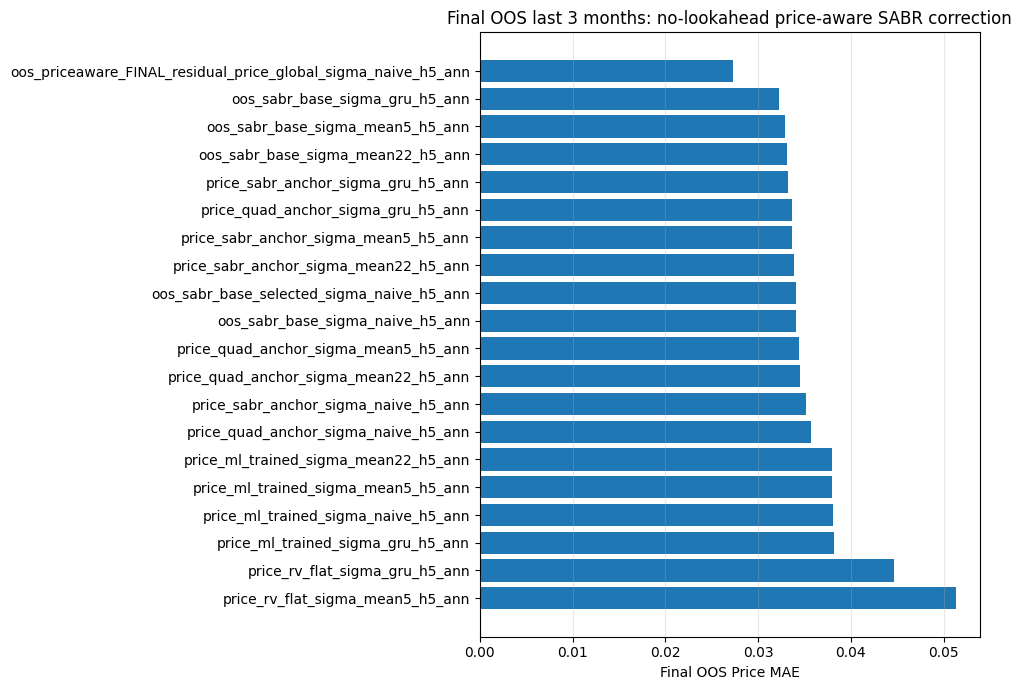

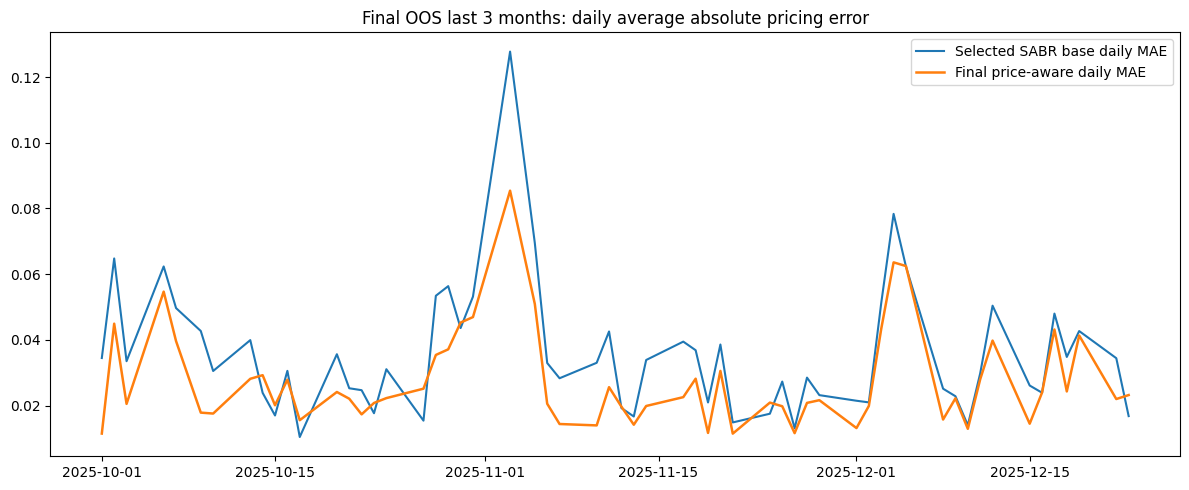

In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

try:
    from IPython.display import display
except Exception:
    display = print


DATE_COL = "trade_date"

RV_2025_COLS = [
    "sigma_gru_h5_ann",
    "sigma_naive_h5_ann",
    "sigma_mean5_h5_ann",
    "sigma_mean22_h5_ann",
]


OOS_LAST_N_CALENDAR_MONTHS = 3


TRAIN_SHARE_PRE_OOS_DATES = 0.70


USE_MANUAL_OOS_START = False
MANUAL_OOS_START = "2025-10-01"

TRADING_DAYS = 252
RV_HORIZON_DAYS = 5
RV_ANCHOR_LAMBDA = 0.70

SABR_BETA = 1.0

IV_MIN = 0.01
IV_MAX = 3.00
SIGMA_MIN = 0.001
SIGMA_MAX = 3.00
PRICE_EPS = 1e-4
EPS = 1e-12

RANDOM_STATE = 42


REBUILD_SAFE_LAG_SMILE = True
MIN_OBS_PER_DAILY_SMILE = 5


USE_CONSTANT_SAFE_SABR_RHO_NU = True
SAFE_SABR_RHO = 0.0
SAFE_SABR_NU = 0.50

MODEL_SELECTION_METRIC = "MAE"

RESULTS_PATH_IF_NO_OOS = resolve_input_path("trained_rv_to_iv_gk_european_cnyp_oos_2025_results.csv")


if "oos" not in globals():
    if os.path.exists(RESULTS_PATH_IF_NO_OOS):
        oos = pd.read_csv(RESULTS_PATH_IF_NO_OOS)
        print("Loaded oos from:", RESULTS_PATH_IF_NO_OOS)
    else:
        raise ValueError("No `oos` dataframe found. Run the main SABR/ML cell first.")

df = oos.copy()

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
if "expiration_date" in df.columns:
    df["expiration_date"] = pd.to_datetime(df["expiration_date"], errors="coerce")

num_cols = [
    "strike", "T_days", "T_model", "rd", "rf", "spot_for_pricing",
    "forward_for_pricing", "moneyness", "market_price", "iv",
    "lag_quad_a", "lag_quad_b", "lag_quad_c", "lag_sabr_rho", "lag_sabr_nu",
] + RV_2025_COLS

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "forward_for_pricing" not in df.columns or df["forward_for_pricing"].isna().all():
    df["forward_for_pricing"] = df["spot_for_pricing"] * np.exp((df["rd"] - df["rf"]) * df["T_model"])

if "moneyness" not in df.columns or df["moneyness"].isna().all():
    df["moneyness"] = np.log(df["strike"] / df["forward_for_pricing"])

df = df[
    df[DATE_COL].notna()
    & np.isfinite(df["market_price"])
    & (df["market_price"] > 0)
    & np.isfinite(df["spot_for_pricing"])
    & np.isfinite(df["strike"])
    & np.isfinite(df["T_model"])
    & (df["spot_for_pricing"] > 0)
    & (df["strike"] > 0)
    & (df["T_model"] > 0)
].copy()

rv_cols_existing = [c for c in RV_2025_COLS if c in df.columns]

if len(rv_cols_existing) == 0:
    raise ValueError(f"No sigma columns found. Expected: {RV_2025_COLS}")

print("Rows in 2025 OOS dataframe:", len(df))
print("Date range:", df[DATE_COL].min(), "->", df[DATE_COL].max())
print("Sigma columns:", rv_cols_existing)


def fit_daily_quadratic_smile(g):


    gg = g[["moneyness", "iv"]].replace([np.inf, -np.inf], np.nan).dropna()
    gg = gg[(gg["iv"] > IV_MIN) & (gg["iv"] < IV_MAX)]

    if len(gg) == 0:
        return pd.Series({
            "cur_quad_a": np.nan,
            "cur_quad_b": np.nan,
            "cur_quad_c": np.nan,
            "cur_smile_n": 0,
        })

    m = gg["moneyness"].astype(float).values
    y = gg["iv"].astype(float).values

    if len(gg) >= MIN_OBS_PER_DAILY_SMILE and np.nanstd(m) > 1e-8:
        try:
            c2, c1, c0 = np.polyfit(m, y, deg=2)
            a, b, c = c0, c1, c2
        except Exception:
            a, b, c = np.nanmedian(y), 0.0, 0.0
    else:
        a, b, c = np.nanmedian(y), 0.0, 0.0

    return pd.Series({
        "cur_quad_a": float(np.clip(a, IV_MIN, IV_MAX)),
        "cur_quad_b": float(b),
        "cur_quad_c": float(c),
        "cur_smile_n": int(len(gg)),
    })


def add_safe_lagged_smile(df_in):
    out = df_in.copy().sort_values([DATE_COL]).reset_index(drop=True)

    if not REBUILD_SAFE_LAG_SMILE:
        print("REBUILD_SAFE_LAG_SMILE=False: using existing lag_quad/lag_sabr columns. Be sure they are truly lagged.")
        return out

    if "iv" not in out.columns:
        raise ValueError("Column `iv` is required to rebuild safe lagged smile parameters.")

    daily = (
        out.groupby(DATE_COL, sort=True)
        .apply(fit_daily_quadratic_smile)
        .reset_index()
        .sort_values(DATE_COL)
        .reset_index(drop=True)
    )


    daily[["cur_quad_a", "cur_quad_b", "cur_quad_c"]] = daily[["cur_quad_a", "cur_quad_b", "cur_quad_c"]].ffill()

    daily["safe_lag_quad_a"] = daily["cur_quad_a"].shift(1)
    daily["safe_lag_quad_b"] = daily["cur_quad_b"].shift(1)
    daily["safe_lag_quad_c"] = daily["cur_quad_c"].shift(1)
    daily["safe_lag_smile_source_date"] = daily[DATE_COL].shift(1)
    daily["safe_lag_smile_n"] = daily["cur_smile_n"].shift(1)

    safe = daily[[
        DATE_COL,
        "safe_lag_quad_a", "safe_lag_quad_b", "safe_lag_quad_c",
        "safe_lag_smile_source_date", "safe_lag_smile_n",
    ]]

    out = out.merge(safe, on=DATE_COL, how="left")


    out["lag_quad_a"] = out["safe_lag_quad_a"]
    out["lag_quad_b"] = out["safe_lag_quad_b"]
    out["lag_quad_c"] = out["safe_lag_quad_c"]

    if USE_CONSTANT_SAFE_SABR_RHO_NU:
        out["lag_sabr_rho"] = SAFE_SABR_RHO
        out["lag_sabr_nu"] = SAFE_SABR_NU
    else:

        out["lag_sabr_rho"] = pd.to_numeric(out.get("lag_sabr_rho", SAFE_SABR_RHO), errors="coerce").fillna(SAFE_SABR_RHO)
        out["lag_sabr_nu"] = pd.to_numeric(out.get("lag_sabr_nu", SAFE_SABR_NU), errors="coerce").fillna(SAFE_SABR_NU)

    before = len(out)
    out = out[
        np.isfinite(out["lag_quad_a"])
        & np.isfinite(out["lag_quad_b"])
        & np.isfinite(out["lag_quad_c"])
        & (out["safe_lag_smile_source_date"] < out[DATE_COL])
    ].copy()

    print("\n================ SAFE LAGGED SMILE ================")
    print("Rebuilt lag_quad_a/b/c from previous trade date only.")
    print("Rows before safe-lag drop:", before)
    print("Rows after safe-lag drop:", len(out))
    print("First usable date:", out[DATE_COL].min())
    print("SABR rho/nu mode:", "constant safe values" if USE_CONSTANT_SAFE_SABR_RHO_NU else "provided lag_sabr columns")

    return out.reset_index(drop=True)


df = add_safe_lagged_smile(df)


def compute_last_n_calendar_months_start(max_date, n_months):
    max_date = pd.Timestamp(max_date)
    month_start = pd.Timestamp(year=max_date.year, month=max_date.month, day=1)
    return month_start - pd.DateOffset(months=n_months - 1)


unique_dates = sorted(pd.to_datetime(df[DATE_COL].dropna().unique()))

if USE_MANUAL_OOS_START:
    oos_start = pd.Timestamp(MANUAL_OOS_START)
else:
    oos_start = compute_last_n_calendar_months_start(max(unique_dates), OOS_LAST_N_CALENDAR_MONTHS)

pre_oos_dates = [d for d in unique_dates if d < oos_start]
oos_dates = [d for d in unique_dates if d >= oos_start]

if len(pre_oos_dates) < 20 or len(oos_dates) < 5:
    raise ValueError(
        f"Not enough dates after OOS split. pre_oos_dates={len(pre_oos_dates)}, oos_dates={len(oos_dates)}, oos_start={oos_start}"
    )

n_train_dates = int(len(pre_oos_dates) * TRAIN_SHARE_PRE_OOS_DATES)
n_train_dates = max(5, min(n_train_dates, len(pre_oos_dates) - 5))

train_dates = pre_oos_dates[:n_train_dates]
select_dates = pre_oos_dates[n_train_dates:]

train_base = df[df[DATE_COL].isin(train_dates)].copy()
select_base = df[df[DATE_COL].isin(select_dates)].copy()
pre_oos_base = df[df[DATE_COL].isin(pre_oos_dates)].copy()
oos_base = df[df[DATE_COL].isin(oos_dates)].copy()

print("\n================ STRICT CHRONOLOGICAL SPLIT ================")
print("Unique dates total:", len(unique_dates))
print("Train dates:", len(train_dates), "|", min(train_dates), "->", max(train_dates))
print("Selection dates:", len(select_dates), "|", min(select_dates), "->", max(select_dates))
print("Final OOS dates:", len(oos_dates), "|", min(oos_dates), "->", max(oos_dates))
print("OOS start:", oos_start)
print("Train rows:", len(train_base))
print("Selection rows:", len(select_base))
print("Pre-OOS rows:", len(pre_oos_base))
print("Final OOS rows:", len(oos_base))

if len(train_base) == 0 or len(select_base) == 0 or len(oos_base) == 0:
    raise ValueError("Empty train/selection/OOS split. Change split settings.")


def sabr_lognormal_vol(F, K, T, alpha, beta, rho, nu):
    F, K, T, alpha, rho, nu = np.broadcast_arrays(
        np.asarray(F, dtype=float),
        np.asarray(K, dtype=float),
        np.asarray(T, dtype=float),
        np.asarray(alpha, dtype=float),
        np.asarray(rho, dtype=float),
        np.asarray(nu, dtype=float),
    )

    beta = float(beta)

    F = np.maximum(F, EPS)
    K = np.maximum(K, EPS)
    T = np.maximum(T, EPS)
    alpha = np.maximum(alpha, EPS)
    nu = np.maximum(nu, EPS)
    rho = np.clip(rho, -0.999, 0.999)

    one_minus_beta = 1.0 - beta
    logFK = np.log(F / K)
    FK_beta = (F * K) ** (one_minus_beta / 2.0)

    denom = FK_beta * (
        1.0
        + (one_minus_beta ** 2 / 24.0) * logFK ** 2
        + (one_minus_beta ** 4 / 1920.0) * logFK ** 4
    )

    z = (nu / alpha) * FK_beta * logFK
    sqrt_term = np.sqrt(np.maximum(1.0 - 2.0 * rho * z + z ** 2, EPS))
    x_z = np.log(np.maximum((sqrt_term + z - rho) / np.maximum(1.0 - rho, EPS), EPS))
    x_z_safe = np.where(np.abs(x_z) < EPS, EPS, x_z)

    z_over_xz = np.where(np.abs(z) < 1e-8, 1.0, z / x_z_safe)

    correction = 1.0 + (
        (one_minus_beta ** 2 / 24.0) * (alpha ** 2 / np.maximum(FK_beta ** 2, EPS))
        + (rho * beta * nu * alpha) / np.maximum(4.0 * FK_beta, EPS)
        + ((2.0 - 3.0 * rho ** 2) * nu ** 2) / 24.0
    ) * T

    vol = (alpha / np.maximum(denom, EPS)) * z_over_xz * correction

    atm = np.abs(logFK) < 1e-8
    if np.any(atm):
        F_atm = F[atm]
        T_atm = T[atm]
        alpha_atm = alpha[atm]
        rho_atm = rho[atm]
        nu_atm = nu[atm]

        vol_atm = (
            alpha_atm / np.maximum(F_atm ** (1.0 - beta), EPS)
            * (
                1.0
                + (
                    ((1.0 - beta) ** 2 / 24.0)
                    * alpha_atm ** 2
                    / np.maximum(F_atm ** (2.0 - 2.0 * beta), EPS)
                    + rho_atm * beta * nu_atm * alpha_atm
                    / np.maximum(4.0 * F_atm ** (1.0 - beta), EPS)
                    + ((2.0 - 3.0 * rho_atm ** 2) * nu_atm ** 2 / 24.0)
                ) * T_atm
            )
        )

        vol[atm] = vol_atm

    vol = np.asarray(vol, dtype=float)
    vol[~np.isfinite(vol)] = np.nan

    return vol


def gk_price_vec(S, K, T, rd, rf, sigma, cp):
    S = pd.to_numeric(S, errors="coerce").astype(float).values
    K = pd.to_numeric(K, errors="coerce").astype(float).values
    T = pd.to_numeric(T, errors="coerce").astype(float).values
    rd = pd.to_numeric(rd, errors="coerce").astype(float).values
    rf = pd.to_numeric(rf, errors="coerce").astype(float).values
    sigma = pd.to_numeric(sigma, errors="coerce").astype(float).values
    cp = pd.Series(cp).astype(str).str.upper().values

    out = np.full(len(S), np.nan)

    ok = (
        np.isfinite(S) & np.isfinite(K) & np.isfinite(T)
        & np.isfinite(rd) & np.isfinite(rf) & np.isfinite(sigma)
        & (S > 0) & (K > 0) & (T > 0) & (sigma > 0)
    )

    if ok.sum() == 0:
        return pd.Series(out)

    S0, K0, T0 = S[ok], K[ok], T[ok]
    rd0, rf0, sig0 = rd[ok], rf[ok], sigma[ok]
    cp0 = cp[ok]

    vol_sqrt = sig0 * np.sqrt(T0)

    d1 = (np.log(S0 / K0) + (rd0 - rf0 + 0.5 * sig0 ** 2) * T0) / vol_sqrt
    d2 = d1 - vol_sqrt

    call = S0 * np.exp(-rf0 * T0) * norm.cdf(d1) - K0 * np.exp(-rd0 * T0) * norm.cdf(d2)
    put = K0 * np.exp(-rd0 * T0) * norm.cdf(-d2) - S0 * np.exp(-rf0 * T0) * norm.cdf(-d1)

    out[ok] = np.where(cp0 == "C", call, put)

    return pd.Series(out)


def gk_vega_vec(S, K, T, rd, rf, sigma):
    S = pd.to_numeric(S, errors="coerce").astype(float).values
    K = pd.to_numeric(K, errors="coerce").astype(float).values
    T = pd.to_numeric(T, errors="coerce").astype(float).values
    rd = pd.to_numeric(rd, errors="coerce").astype(float).values
    rf = pd.to_numeric(rf, errors="coerce").astype(float).values
    sigma = pd.to_numeric(sigma, errors="coerce").astype(float).values

    out = np.full(len(S), np.nan)

    ok = (
        np.isfinite(S) & np.isfinite(K) & np.isfinite(T)
        & np.isfinite(rd) & np.isfinite(rf) & np.isfinite(sigma)
        & (S > 0) & (K > 0) & (T > 0) & (sigma > 0)
    )

    if ok.sum() == 0:
        return pd.Series(out)

    S0, K0, T0 = S[ok], K[ok], T[ok]
    rd0, rf0, sig0 = rd[ok], rf[ok], sigma[ok]

    vol_sqrt = sig0 * np.sqrt(T0)
    d1 = (np.log(S0 / K0) + (rd0 - rf0 + 0.5 * sig0 ** 2) * T0) / vol_sqrt

    out[ok] = S0 * np.exp(-rf0 * T0) * norm.pdf(d1) * np.sqrt(T0)

    return pd.Series(out)


def gk_bounds_vec(df):
    S = pd.to_numeric(df["spot_for_pricing"], errors="coerce").astype(float)
    K = pd.to_numeric(df["strike"], errors="coerce").astype(float)
    T = pd.to_numeric(df["T_model"], errors="coerce").astype(float)
    rd = pd.to_numeric(df["rd"], errors="coerce").astype(float)
    rf = pd.to_numeric(df["rf"], errors="coerce").astype(float)
    cp = df["option_type"].astype(str).str.upper()

    disc_S = S * np.exp(-rf * T)
    disc_K = K * np.exp(-rd * T)

    lower_call = np.maximum(disc_S - disc_K, 0.0)
    lower_put = np.maximum(disc_K - disc_S, 0.0)

    upper_call = disc_S
    upper_put = disc_K

    lower = np.where(cp == "C", lower_call, lower_put)
    upper = np.where(cp == "C", upper_call, upper_put)

    return pd.Series(lower, index=df.index), pd.Series(upper, index=df.index)


def compute_sabr_base(df, sigma_col):
    out = df.copy()

    sig = pd.to_numeric(out[sigma_col], errors="coerce").astype(float).clip(SIGMA_MIN, SIGMA_MAX)
    ann_var_rv = sig ** 2

    lag_atm_iv = pd.to_numeric(out["lag_quad_a"], errors="coerce").astype(float).clip(IV_MIN, IV_MAX)
    lag_atm_var = lag_atm_iv ** 2

    T = pd.to_numeric(out["T_model"], errors="coerce").astype(float).clip(lower=EPS)
    H = RV_HORIZON_DAYS / TRADING_DAYS

    short_part = np.minimum(T, H)
    long_part = np.maximum(T - H, 0.0)

    rv_term_var = (short_part * ann_var_rv + long_part * lag_atm_var) / T

    anchored_atm_var = (
        RV_ANCHOR_LAMBDA * rv_term_var
        + (1.0 - RV_ANCHOR_LAMBDA) * lag_atm_var
    )

    anchored_atm_iv = np.sqrt(anchored_atm_var).clip(IV_MIN, IV_MAX)

    m = pd.to_numeric(out["moneyness"], errors="coerce").astype(float)
    lag_b = pd.to_numeric(out["lag_quad_b"], errors="coerce").fillna(0.0).astype(float)
    lag_c = pd.to_numeric(out["lag_quad_c"], errors="coerce").fillna(0.0).astype(float)

    iv_quad = (
        anchored_atm_iv
        + lag_b * m
        + lag_c * m ** 2
    ).clip(IV_MIN, IV_MAX)

    F = pd.to_numeric(out["forward_for_pricing"], errors="coerce").astype(float).clip(lower=EPS)
    K = pd.to_numeric(out["strike"], errors="coerce").astype(float).clip(lower=EPS)

    rho = pd.to_numeric(out.get("lag_sabr_rho", SAFE_SABR_RHO), errors="coerce").fillna(SAFE_SABR_RHO).astype(float)
    nu = pd.to_numeric(out.get("lag_sabr_nu", SAFE_SABR_NU), errors="coerce").fillna(SAFE_SABR_NU).astype(float)

    sabr_alpha_anchor = (
        anchored_atm_iv * (F ** (1.0 - SABR_BETA))
    ).clip(1e-4, 5.0)

    iv_sabr = sabr_lognormal_vol(
        F.values,
        K.values,
        T.values,
        sabr_alpha_anchor.values,
        SABR_BETA,
        rho.values,
        nu.values,
    )

    iv_sabr = pd.Series(iv_sabr, index=out.index).replace([np.inf, -np.inf], np.nan)

    bad = iv_sabr.isna() | (iv_sabr < IV_MIN) | (iv_sabr > IV_MAX)
    iv_sabr.loc[bad] = iv_quad.loc[bad]
    iv_sabr = iv_sabr.clip(IV_MIN, IV_MAX)

    out["base_iv_sabr"] = iv_sabr
    out["base_iv_quad"] = iv_quad
    out["base_atm_iv"] = anchored_atm_iv
    out["base_sigma_input"] = sig
    out["rv_signal_source"] = sigma_col

    out["base_price_sabr"] = gk_price_vec(
        out["spot_for_pricing"],
        out["strike"],
        out["T_model"],
        out["rd"],
        out["rf"],
        out["base_iv_sabr"],
        out["option_type"],
    ).values

    out["base_vega_sabr"] = gk_vega_vec(
        out["spot_for_pricing"],
        out["strike"],
        out["T_model"],
        out["rd"],
        out["rf"],
        out["base_iv_sabr"],
    ).values

    lower, upper = gk_bounds_vec(out)
    out["price_lower_bound"] = lower
    out["price_upper_bound"] = upper

    out["base_time_value"] = (
        pd.to_numeric(out["base_price_sabr"], errors="coerce")
        - pd.to_numeric(out["price_lower_bound"], errors="coerce")
    ).clip(lower=0.0)

    return out


PRICE_FEATURES = [
    "base_price_sabr",
    "base_iv_sabr",
    "base_atm_iv",
    "base_sigma_input",
    "base_vega_sabr",
    "base_time_value",
    "price_lower_bound",
    "price_upper_bound",

    "m",
    "m2",
    "abs_m",

    "T",
    "sqrt_T",
    "log_T",
    "T_days",

    "put",
    "put_m",
    "put_abs_m",

    "rd",
    "rf",
    "rd_rf_spread",


    "lag_atm_iv",
    "lag_skew",
    "lag_curvature",
    "lag_sabr_rho",
    "lag_sabr_nu",

    "log_base_price",
    "log_vega",
    "log_base_iv_var",
    "log_sigma_var",

    "signal_gru",
    "signal_naive",
    "signal_mean5",
    "signal_mean22",
]


def signal_flags(signal_name):
    s = str(signal_name).lower()
    return {
        "signal_gru": float("gru" in s),
        "signal_naive": float("naive" in s),
        "signal_mean5": float("mean5" in s),
        "signal_mean22": float("mean22" in s),
    }


def make_price_features(df):
    X = pd.DataFrame(index=df.index)

    m = pd.to_numeric(df["moneyness"], errors="coerce").astype(float)
    T = pd.to_numeric(df["T_model"], errors="coerce").astype(float).clip(lower=EPS)
    T_days = pd.to_numeric(df["T_days"], errors="coerce").astype(float)

    put = (df["option_type"].astype(str).str.upper() == "P").astype(float)

    base_price = pd.to_numeric(df["base_price_sabr"], errors="coerce").astype(float)
    base_iv = pd.to_numeric(df["base_iv_sabr"], errors="coerce").astype(float).clip(IV_MIN, IV_MAX)
    base_sigma = pd.to_numeric(df["base_sigma_input"], errors="coerce").astype(float).clip(SIGMA_MIN, SIGMA_MAX)
    vega = pd.to_numeric(df["base_vega_sabr"], errors="coerce").astype(float)

    X["base_price_sabr"] = base_price
    X["base_iv_sabr"] = base_iv
    X["base_atm_iv"] = pd.to_numeric(df["base_atm_iv"], errors="coerce")
    X["base_sigma_input"] = base_sigma
    X["base_vega_sabr"] = vega
    X["base_time_value"] = pd.to_numeric(df["base_time_value"], errors="coerce")
    X["price_lower_bound"] = pd.to_numeric(df["price_lower_bound"], errors="coerce")
    X["price_upper_bound"] = pd.to_numeric(df["price_upper_bound"], errors="coerce")

    X["m"] = m
    X["m2"] = m ** 2
    X["abs_m"] = np.abs(m)

    X["T"] = T
    X["sqrt_T"] = np.sqrt(T)
    X["log_T"] = np.log(T)
    X["T_days"] = T_days

    X["put"] = put
    X["put_m"] = put * m
    X["put_abs_m"] = put * np.abs(m)

    X["rd"] = pd.to_numeric(df["rd"], errors="coerce")
    X["rf"] = pd.to_numeric(df["rf"], errors="coerce")
    X["rd_rf_spread"] = X["rd"] - X["rf"]

    X["lag_atm_iv"] = pd.to_numeric(df["lag_quad_a"], errors="coerce")
    X["lag_skew"] = pd.to_numeric(df["lag_quad_b"], errors="coerce")
    X["lag_curvature"] = pd.to_numeric(df["lag_quad_c"], errors="coerce")
    X["lag_sabr_rho"] = pd.to_numeric(df.get("lag_sabr_rho", SAFE_SABR_RHO), errors="coerce")
    X["lag_sabr_nu"] = pd.to_numeric(df.get("lag_sabr_nu", SAFE_SABR_NU), errors="coerce")

    X["log_base_price"] = np.log(base_price.clip(lower=PRICE_EPS))
    X["log_vega"] = np.log(pd.Series(vega, index=df.index).clip(lower=PRICE_EPS))
    X["log_base_iv_var"] = np.log((base_iv ** 2).clip(lower=EPS))
    X["log_sigma_var"] = np.log((base_sigma ** 2).clip(lower=EPS))

    if "rv_signal_source" in df.columns:
        flags = df["rv_signal_source"].apply(signal_flags).apply(pd.Series)
        for c in ["signal_gru", "signal_naive", "signal_mean5", "signal_mean22"]:
            X[c] = flags[c].values
    else:
        X["signal_gru"] = 0.0
        X["signal_naive"] = 0.0
        X["signal_mean5"] = 0.0
        X["signal_mean22"] = 0.0


    return X[PRICE_FEATURES].replace([np.inf, -np.inf], np.nan)


def add_targets(df):
    out = df.copy()

    market = pd.to_numeric(out["market_price"], errors="coerce").astype(float)
    base = pd.to_numeric(out["base_price_sabr"], errors="coerce").astype(float)
    vega = pd.to_numeric(out["base_vega_sabr"], errors="coerce").astype(float)

    vega_floor = np.nanpercentile(vega[np.isfinite(vega)], 10) if np.isfinite(vega).sum() > 0 else 1e-4
    vega_eff = pd.Series(vega, index=out.index).clip(lower=max(vega_floor, 1e-4))

    out["target_residual_price"] = market - base
    out["target_log_price_ratio"] = np.log((market + PRICE_EPS) / (base + PRICE_EPS))
    out["target_vega_residual"] = (market - base) / vega_eff

    lo = out["target_vega_residual"].quantile(0.01)
    hi = out["target_vega_residual"].quantile(0.99)
    out["target_vega_residual"] = out["target_vega_residual"].clip(lo, hi)

    return out


def make_model():
    try:
        reg = HistGradientBoostingRegressor(
            loss="absolute_error",
            max_iter=300,
            learning_rate=0.035,
            max_leaf_nodes=15,
            min_samples_leaf=30,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        )
    except TypeError:
        reg = HistGradientBoostingRegressor(
            loss="squared_error",
            max_iter=300,
            learning_rate=0.035,
            max_leaf_nodes=15,
            min_samples_leaf=30,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        )

    return make_pipeline(
        SimpleImputer(strategy="median"),
        reg,
    )


def make_stacked(df_base, sigma_cols):
    parts = []

    for sig_col in sigma_cols:
        if sig_col not in df_base.columns:
            continue

        tmp = df_base.copy()
        tmp[sig_col] = pd.to_numeric(tmp[sig_col], errors="coerce")
        tmp = tmp[np.isfinite(tmp[sig_col]) & (tmp[sig_col] > 0)].copy()

        if len(tmp) == 0:
            continue

        tmp = compute_sabr_base(tmp, sig_col)
        parts.append(tmp)

    if len(parts) == 0:
        raise ValueError("No stacked data created.")

    out = pd.concat(parts, ignore_index=True)
    out = add_targets(out)

    out = out[
        np.isfinite(out["market_price"])
        & np.isfinite(out["base_price_sabr"])
        & np.isfinite(out["target_residual_price"])
    ].copy()

    return out


def fit_residual_model(train_df, target_col, by_option_type=False):
    fitted = {
        "target_col": target_col,
        "by_option_type": by_option_type,
        "models": {},
    }

    groups = ["C", "P"] if by_option_type else ["ALL"]

    for group in groups:
        if group == "ALL":
            g = train_df.copy()
        else:
            g = train_df[train_df["option_type"].astype(str).str.upper() == group].copy()

        g = g[np.isfinite(g[target_col])].copy()

        if len(g) < 100:
            continue

        X = make_price_features(g)
        y = g[target_col].astype(float)

        model = make_model()
        model.fit(X, y)

        fitted["models"][group] = model

    return fitted


def predict_residual(df, fitted):
    pred = pd.Series(np.nan, index=df.index)

    groups = ["C", "P"] if fitted["by_option_type"] else ["ALL"]

    for group in groups:
        if group == "ALL":
            idx = df.index
            model = fitted["models"].get("ALL")
        else:
            idx = df.index[df["option_type"].astype(str).str.upper() == group]
            model = fitted["models"].get(group)

        if model is None or len(idx) == 0:
            continue

        X = make_price_features(df.loc[idx])
        pred.loc[idx] = model.predict(X)

    return pred


def apply_residual_correction(df, fitted, pred_col):
    out = df.copy()

    pred = predict_residual(out, fitted)

    base = pd.to_numeric(out["base_price_sabr"], errors="coerce").astype(float)
    vega = pd.to_numeric(out["base_vega_sabr"], errors="coerce").astype(float)

    if fitted["target_col"] == "target_residual_price":
        corrected = base + pred

    elif fitted["target_col"] == "target_log_price_ratio":
        corrected = (base + PRICE_EPS) * np.exp(pred) - PRICE_EPS

    elif fitted["target_col"] == "target_vega_residual":
        vega_floor = np.nanpercentile(vega[np.isfinite(vega)], 10) if np.isfinite(vega).sum() > 0 else 1e-4
        vega_eff = pd.Series(vega, index=out.index).clip(lower=max(vega_floor, 1e-4))
        corrected = base + vega_eff * pred

    else:
        raise ValueError("Unknown target.")

    corrected = pd.Series(corrected, index=out.index)

    lower = pd.to_numeric(out["price_lower_bound"], errors="coerce").fillna(0.0)
    upper = pd.to_numeric(out["price_upper_bound"], errors="coerce")

    corrected = corrected.clip(lower=0.0)
    corrected = pd.Series(np.maximum(corrected.values, lower.values), index=out.index)

    upper_ok = np.isfinite(upper)
    corrected.loc[upper_ok] = np.minimum(corrected.loc[upper_ok], upper.loc[upper_ok])

    out[pred_col] = corrected

    return out


def calc_metrics(df, price_col, label=None):
    d = df[[price_col, "market_price"]].replace([np.inf, -np.inf], np.nan).dropna()
    d = d[d["market_price"] > 0]

    if len(d) == 0:
        return {
            "model": label or price_col,
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "MedianAE": np.nan,
            "WMAPE_pct": np.nan,
        }

    err = d[price_col] - d["market_price"]

    return {
        "model": label or price_col,
        "n": len(d),
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "Bias": float(np.mean(err)),
        "MedianAE": float(np.median(np.abs(err))),
        "WMAPE_pct": float(100 * np.sum(np.abs(err)) / np.sum(np.abs(d["market_price"]))),
    }


def fit_all_residual_specs(train_stack):
    fitted_models = {}

    for target_col in [
        "target_residual_price",
        "target_log_price_ratio",
        "target_vega_residual",
    ]:
        for by_cp in [False, True]:
            key = f"{target_col.replace('target_', '')}_{'byCP' if by_cp else 'global'}"
            fitted_models[key] = fit_residual_model(train_stack, target_col, by_option_type=by_cp)

    return fitted_models


def score_all_specs_on_base(eval_base, fitted_models, sigma_cols, prefix):
    result = eval_base.copy()
    all_price_cols = []
    model_map_rows = []


    for c in result.columns:
        if (
            c.startswith("price_sabr_anchor_")
            or c.startswith("price_quad_anchor_")
            or c.startswith("price_rv_flat_")
            or c.startswith("price_ml_trained_")
        ):
            all_price_cols.append(c)
            model_map_rows.append({
                "price_col": c,
                "kind": "existing_benchmark",
                "spec_key": None,
                "sigma_col": None,
            })

    for sig_col in sigma_cols:
        print(f"{prefix}: scoring signal {sig_col}")

        base_tmp = compute_sabr_base(eval_base.copy(), sig_col)

        base_col = f"{prefix}_sabr_base_{sig_col}"
        iv_col = f"{prefix}_sabr_iv_{sig_col}"

        result[base_col] = base_tmp["base_price_sabr"].values
        result[iv_col] = base_tmp["base_iv_sabr"].values

        all_price_cols.append(base_col)
        model_map_rows.append({
            "price_col": base_col,
            "kind": "sabr_base",
            "spec_key": None,
            "sigma_col": sig_col,
        })

        for key, fitted in fitted_models.items():
            pred_col = f"{prefix}_priceaware_{key}_{sig_col}"

            pred_tmp = apply_residual_correction(base_tmp.copy(), fitted, pred_col)
            result[pred_col] = pred_tmp[pred_col].values

            all_price_cols.append(pred_col)
            model_map_rows.append({
                "price_col": pred_col,
                "kind": "priceaware",
                "spec_key": key,
                "sigma_col": sig_col,
            })

    all_price_cols = list(dict.fromkeys(all_price_cols))

    metrics = pd.DataFrame([
        calc_metrics(result, c, label=c)
        for c in all_price_cols
    ])

    model_map = pd.DataFrame(model_map_rows).drop_duplicates("price_col")
    metrics = metrics.merge(model_map, left_on="model", right_on="price_col", how="left")
    metrics = metrics.sort_values([MODEL_SELECTION_METRIC, "RMSE", "MAE"]).reset_index(drop=True)

    return result, metrics, all_price_cols


train_stack = make_stacked(train_base, rv_cols_existing)

print("\n================ TRAIN STACK FOR SELECTION ================")
print("Train base rows:", len(train_base))
print("Train stacked rows:", len(train_stack))
print("Train stacked dates:", train_stack[DATE_COL].min(), "->", train_stack[DATE_COL].max())
print("Signals:")
print(train_stack["rv_signal_source"].value_counts())

fitted_selection_models = fit_all_residual_specs(train_stack)

print("\nFitted selection models:")
print(list(fitted_selection_models.keys()))

print("\n================ SELECTION PERIOD SCORING ================")
select_result, select_metrics, select_price_cols = score_all_specs_on_base(
    eval_base=select_base,
    fitted_models=fitted_selection_models,
    sigma_cols=rv_cols_existing,
    prefix="select",
)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)

print("\n================ SELECTION PRICE METRICS: PRE-OOS ONLY ================")
display(select_metrics.head(40))

priceaware_select = select_metrics[select_metrics["kind"] == "priceaware"].copy()
if len(priceaware_select) == 0:
    raise ValueError("No price-aware model was evaluated on selection period.")

best_select = priceaware_select.sort_values([MODEL_SELECTION_METRIC, "RMSE", "MAE"]).iloc[0].to_dict()
BEST_SPEC_KEY = best_select["spec_key"]
BEST_SIGMA_COL = best_select["sigma_col"]
BEST_SELECTION_MODEL_COL = best_select["model"]

print("\n================ SELECTED SPECIFICATION ================")
print("Selected by:", MODEL_SELECTION_METRIC)
print("BEST_SPEC_KEY:", BEST_SPEC_KEY)
print("BEST_SIGMA_COL:", BEST_SIGMA_COL)
print("Selection model column:", BEST_SELECTION_MODEL_COL)
print("Selection metrics:")
print(pd.Series({k: best_select[k] for k in ["n", "MAE", "RMSE", "Bias", "MedianAE", "WMAPE_pct"]}))


pre_oos_stack = make_stacked(pre_oos_base, rv_cols_existing)

print("\n================ FINAL REFIT STACK ================")
print("Pre-OOS base rows:", len(pre_oos_base))
print("Pre-OOS stacked rows:", len(pre_oos_stack))
print("Pre-OOS stacked dates:", pre_oos_stack[DATE_COL].min(), "->", pre_oos_stack[DATE_COL].max())


def parse_spec_key(key):
    by_cp = key.endswith("_byCP")
    core = key.replace("_byCP", "").replace("_global", "")

    if core == "residual_price":
        target_col = "target_residual_price"
    elif core == "log_price_ratio":
        target_col = "target_log_price_ratio"
    elif core == "vega_residual":
        target_col = "target_vega_residual"
    else:
        raise ValueError(f"Cannot parse spec key: {key}")

    return target_col, by_cp


best_target_col, best_by_cp = parse_spec_key(BEST_SPEC_KEY)

final_fitted_best = fit_residual_model(
    pre_oos_stack,
    target_col=best_target_col,
    by_option_type=best_by_cp,
)


oos_result = oos_base.copy()

base_best_tmp = compute_sabr_base(oos_base.copy(), BEST_SIGMA_COL)

oos_base_same_col = f"oos_sabr_base_selected_{BEST_SIGMA_COL}"
oos_final_col = f"oos_priceaware_FINAL_{BEST_SPEC_KEY}_{BEST_SIGMA_COL}"
oos_iv_selected_col = f"oos_sabr_iv_selected_{BEST_SIGMA_COL}"

oos_result[oos_base_same_col] = base_best_tmp["base_price_sabr"].values
oos_result[oos_iv_selected_col] = base_best_tmp["base_iv_sabr"].values

pred_best_tmp = apply_residual_correction(base_best_tmp.copy(), final_fitted_best, oos_final_col)
oos_result[oos_final_col] = pred_best_tmp[oos_final_col].values


oos_context_cols = [oos_base_same_col, oos_final_col]
for sig_col in rv_cols_existing:
    tmp = compute_sabr_base(oos_base.copy(), sig_col)
    c = f"oos_sabr_base_{sig_col}"
    oos_result[c] = tmp["base_price_sabr"].values
    oos_context_cols.append(c)


for c in oos_result.columns:
    if (
        c.startswith("price_sabr_anchor_")
        or c.startswith("price_quad_anchor_")
        or c.startswith("price_rv_flat_")
        or c.startswith("price_ml_trained_")
    ):
        oos_context_cols.append(c)

oos_context_cols = list(dict.fromkeys(oos_context_cols))

oos_metrics = pd.DataFrame([
    calc_metrics(oos_result, c, label=c)
    for c in oos_context_cols
]).sort_values(["MAE", "RMSE"]).reset_index(drop=True)

print("\n================ FINAL OOS PRICE METRICS: LAST 3 MONTHS ONLY ================")
print("OOS dates:", oos_result[DATE_COL].min(), "->", oos_result[DATE_COL].max())
print("OOS rows:", len(oos_result))
display(oos_metrics.head(60))


def metrics_dict_for_col(metrics_df, model_col):
    r = metrics_df[metrics_df["model"] == model_col]
    if len(r) == 0:
        return None
    return r.iloc[0].to_dict()


def improvement_row(base_label, base_col, final_col):
    b = metrics_dict_for_col(oos_metrics, base_col)
    f = metrics_dict_for_col(oos_metrics, final_col)
    if b is None or f is None:
        return None

    return {
        "comparison": base_label,
        "base_model": base_col,
        "final_model": final_col,
        "base_MAE": b["MAE"],
        "final_MAE": f["MAE"],
        "MAE_improvement_%": 100.0 * (b["MAE"] - f["MAE"]) / max(b["MAE"], EPS),
        "base_RMSE": b["RMSE"],
        "final_RMSE": f["RMSE"],
        "RMSE_improvement_%": 100.0 * (b["RMSE"] - f["RMSE"]) / max(b["RMSE"], EPS),
        "base_WMAPE_pct": b["WMAPE_pct"],
        "final_WMAPE_pct": f["WMAPE_pct"],
        "WMAPE_improvement_%": 100.0 * (b["WMAPE_pct"] - f["WMAPE_pct"]) / max(b["WMAPE_pct"], EPS),
        "base_Bias": b["Bias"],
        "final_Bias": f["Bias"],
    }


imp_rows = []


imp_rows.append(improvement_row(
    "Final price-aware vs selected-signal SABR base",
    oos_base_same_col,
    oos_final_col,
))


base_sabr_cols = [c for c in oos_metrics["model"].tolist() if c.startswith("oos_sabr_base_")]
if len(base_sabr_cols) > 0:
    best_oos_sabr_col = oos_metrics[oos_metrics["model"].isin(base_sabr_cols)].sort_values(["MAE", "RMSE"]).iloc[0]["model"]
    imp_rows.append(improvement_row(
        "Final price-aware vs best OOS SABR base, context only",
        best_oos_sabr_col,
        oos_final_col,
    ))

improvement_df = pd.DataFrame([r for r in imp_rows if r is not None])

print("\n================ FINAL OOS IMPROVEMENT REPORT ================")
if len(improvement_df) > 0:
    display(improvement_df.round({
        "base_MAE": 6,
        "final_MAE": 6,
        "MAE_improvement_%": 2,
        "base_RMSE": 6,
        "final_RMSE": 6,
        "RMSE_improvement_%": 2,
        "base_WMAPE_pct": 4,
        "final_WMAPE_pct": 4,
        "WMAPE_improvement_%": 2,
        "base_Bias": 6,
        "final_Bias": 6,
    }))
else:
    print("No improvement rows available.")


type_rows = []
for opt_type, g in oos_result.groupby("option_type", dropna=False):
    for c in oos_context_cols:
        m = calc_metrics(g, c, label=c)
        m["option_type"] = str(opt_type)
        type_rows.append(m)

oos_by_type = pd.DataFrame(type_rows).sort_values(["option_type", "MAE"])

print("\n================ FINAL OOS BY OPTION TYPE ================")
display(oos_by_type.groupby("option_type").head(15))


def expiration_bucket_short(t):
    if pd.isna(t):
        return np.nan
    if t <= 7:
        return "1 week (<=7d)"
    elif t <= 14:
        return "2 weeks (8-14d)"
    elif t <= 31:
        return "1 month (15-31d)"
    else:
        return "longer than 1 month"


oos_result["expiration_bucket_short"] = oos_result["T_days"].apply(expiration_bucket_short)

exp_rows = []
for bucket, g in oos_result.groupby("expiration_bucket_short", dropna=False):
    for c in oos_context_cols:
        m = calc_metrics(g, c, label=c)
        m["expiration_bucket"] = str(bucket)
        exp_rows.append(m)

oos_by_expiration = pd.DataFrame(exp_rows).sort_values(["expiration_bucket", "MAE"])

print("\n================ FINAL OOS BY EXPIRATION ================")
display(
    oos_by_expiration[
        oos_by_expiration["expiration_bucket"].isin([
            "1 week (<=7d)",
            "2 weeks (8-14d)",
            "1 month (15-31d)",
            "longer than 1 month",
        ])
    ].groupby("expiration_bucket").head(10)
)


out_dir = "/content"
out_select_results = f"{out_dir}/select2025_priceaware_no_lookahead_results.csv"
out_select_metrics = f"{out_dir}/select2025_priceaware_no_lookahead_metrics.csv"
out_oos_results = f"{out_dir}/oos_last3m_priceaware_no_lookahead_results.csv"
out_oos_metrics = f"{out_dir}/oos_last3m_priceaware_no_lookahead_metrics.csv"
out_oos_improvement = f"{out_dir}/oos_last3m_priceaware_no_lookahead_improvement.csv"
out_oos_type = f"{out_dir}/oos_last3m_priceaware_no_lookahead_metrics_by_type.csv"
out_oos_exp = f"{out_dir}/oos_last3m_priceaware_no_lookahead_metrics_by_expiration.csv"
out_selected_spec = f"{out_dir}/oos_last3m_priceaware_selected_spec.csv"

select_result.to_csv(out_select_results, index=False)
select_metrics.to_csv(out_select_metrics, index=False)
oos_result.to_csv(out_oos_results, index=False)
oos_metrics.to_csv(out_oos_metrics, index=False)

if len(improvement_df) > 0:
    improvement_df.to_csv(out_oos_improvement, index=False)

oos_by_type.to_csv(out_oos_type, index=False)
oos_by_expiration.to_csv(out_oos_exp, index=False)

selected_spec_df = pd.DataFrame([{
    "selected_by": MODEL_SELECTION_METRIC,
    "best_spec_key": BEST_SPEC_KEY,
    "best_sigma_col": BEST_SIGMA_COL,
    "best_selection_model_col": BEST_SELECTION_MODEL_COL,
    "oos_final_col": oos_final_col,
    "oos_base_same_col": oos_base_same_col,
    "oos_start": oos_start,
    "train_start": min(train_dates),
    "train_end": max(train_dates),
    "selection_start": min(select_dates),
    "selection_end": max(select_dates),
    "oos_start_actual": min(oos_dates),
    "oos_end_actual": max(oos_dates),
    "rebuild_safe_lag_smile": REBUILD_SAFE_LAG_SMILE,
    "use_constant_safe_sabr_rho_nu": USE_CONSTANT_SAFE_SABR_RHO_NU,
}])
selected_spec_df.to_csv(out_selected_spec, index=False)

print("\nSaved:")
print(out_select_results)
print(out_select_metrics)
print(out_oos_results)
print(out_oos_metrics)
if len(improvement_df) > 0:
    print(out_oos_improvement)
print(out_oos_type)
print(out_oos_exp)
print(out_selected_spec)


plot_df = oos_metrics[
    ~oos_metrics["model"].str.contains("current_market_iv_check", na=False)
].head(20).copy()

plt.figure(figsize=(10, 7))
plt.barh(plot_df["model"][::-1], plot_df["MAE"][::-1])
plt.xlabel("Final OOS Price MAE")
plt.title("Final OOS last 3 months: no-lookahead price-aware SABR correction")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


err_plot = oos_result[[DATE_COL, "market_price", oos_base_same_col, oos_final_col]].dropna().copy()
if len(err_plot) > 0:
    err_plot["base_abs_error"] = (err_plot[oos_base_same_col] - err_plot["market_price"]).abs()
    err_plot["final_abs_error"] = (err_plot[oos_final_col] - err_plot["market_price"]).abs()

    daily_err = err_plot.groupby(DATE_COL)[["base_abs_error", "final_abs_error"]].mean().reset_index()

    plt.figure(figsize=(12, 5))
    plt.plot(daily_err[DATE_COL], daily_err["base_abs_error"], label="Selected SABR base daily MAE", linewidth=1.5)
    plt.plot(daily_err[DATE_COL], daily_err["final_abs_error"], label="Final price-aware daily MAE", linewidth=1.8)
    plt.title("Final OOS last 3 months: daily average absolute pricing error")
    plt.legend()
    plt.tight_layout()
    plt.show()


Rows in dataframe before safe lag: 5834
Date range before safe lag: 2025-01-03 00:00:00 -> 2025-12-23 00:00:00
Sigma columns: ['sigma_gru_h5_ann', 'sigma_naive_h5_ann', 'sigma_mean5_h5_ann', 'sigma_mean22_h5_ann']

================ SAFE LAGGED SMILE ================
Rebuilt lag_quad_a/b/c from previous trade date only.
Rows before safe-lag drop: 5834
Rows after safe-lag drop: 5825
First usable date: 2025-01-06 00:00:00
SABR rho/nu mode: constant safe values

================ FINAL OOS SPLIT: FULL 2025 ================
Evaluation year: 2025
Evaluation dates: 245 | 2025-01-06 00:00:00 -> 2025-12-23 00:00:00
Evaluation rows: 5825
Scoring deterministic pricing variants for: sigma_gru_h5_ann
Scoring deterministic pricing variants for: sigma_naive_h5_ann
Scoring deterministic pricing variants for: sigma_mean5_h5_ann
Scoring deterministic pricing variants for: sigma_mean22_h5_ann

================ FINAL OOS PRICE METRICS: FULL 2025, NO ML ================
Evaluation dates: 2025-01-06 00:00:00

,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct
0,oos_sabr_anchor_sigma_gru_h5_ann,5825,0.048428,0.086801,-0.009868,0.029249,15.751228
1,oos_sabr_anchor_sigma_mean5_h5_ann,5825,0.048944,0.086877,-0.011961,0.030261,15.918965
2,oos_sabr_anchor_sigma_mean22_h5_ann,5825,0.048966,0.087057,-0.010251,0.029862,15.926034
3,oos_sabr_anchor_sigma_naive_h5_ann,5825,0.049754,0.087127,-0.011779,0.031065,16.182417
4,oos_quad_anchor_sigma_gru_h5_ann,5825,0.057678,0.113560,0.004803,0.032877,18.759492
5,oos_quad_anchor_sigma_mean5_h5_ann,5825,0.057942,0.113333,0.002645,0.032756,18.845482
6,oos_quad_anchor_sigma_mean22_h5_ann,5825,0.058081,0.113664,0.004402,0.033053,18.890738
7,oos_quad_anchor_sigma_naive_h5_ann,5825,0.058840,0.114182,0.002852,0.033742,19.137601
8,oos_flat_rv_sigma_gru_h5_ann,5825,0.060366,0.084021,-0.047307,0.043459,19.633943
9,oos_flat_rv_sigma_mean22_h5_ann,5825,0.062828,0.085695,-0.049069,0.046809,20.434534



================ FINAL OOS IMPROVEMENT REPORT: FULL 2025, NO ML ================


,comparison,base_model,final_model,base_MAE,final_MAE,MAE_improvement_%,base_RMSE,final_RMSE,RMSE_improvement_%,base_WMAPE_pct,final_WMAPE_pct,WMAPE_improvement_%,base_Bias,final_Bias
0,GRU SABR anchor vs sigma_naive_h5_ann SABR anchor,oos_sabr_anchor_sigma_naive_h5_ann,oos_sabr_anchor_sigma_gru_h5_ann,0.049754,0.048428,2.66,0.087127,0.086801,0.37,16.1824,15.7512,2.66,-0.011779,-0.009868
1,GRU SABR anchor vs sigma_mean5_h5_ann SABR anchor,oos_sabr_anchor_sigma_mean5_h5_ann,oos_sabr_anchor_sigma_gru_h5_ann,0.048944,0.048428,1.05,0.086877,0.086801,0.09,15.9190,15.7512,1.05,-0.011961,-0.009868
2,GRU SABR anchor vs sigma_mean22_h5_ann SABR anchor,oos_sabr_anchor_sigma_mean22_h5_ann,oos_sabr_anchor_sigma_gru_h5_ann,0.048966,0.048428,1.10,0.087057,0.086801,0.29,15.9260,15.7512,1.10,-0.010251,-0.009868
3,GRU SABR anchor vs GRU quadratic smile anchor,oos_quad_anchor_sigma_gru_h5_ann,oos_sabr_anchor_sigma_gru_h5_ann,0.057678,0.048428,16.04,0.113560,0.086801,23.56,18.7595,15.7512,16.04,0.004803,-0.009868
4,GRU SABR anchor vs GRU flat RV price,oos_flat_rv_sigma_gru_h5_ann,oos_sabr_anchor_sigma_gru_h5_ann,0.060366,0.048428,19.78,0.084021,0.086801,-3.31,19.6339,15.7512,19.78,-0.047307,-0.009868



================ FINAL OOS BY OPTION TYPE: FULL 2025, NO ML ================


,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,option_type
5,oos_sabr_anchor_sigma_naive_h5_ann,3759,0.041208,0.067705,0.002604,0.026788,12.957012,C
8,oos_sabr_anchor_sigma_mean5_h5_ann,3759,0.041249,0.067927,0.002263,0.027064,12.970071,C
2,oos_sabr_anchor_sigma_gru_h5_ann,3759,0.041494,0.068672,0.004151,0.026058,13.046983,C
11,oos_sabr_anchor_sigma_mean22_h5_ann,3759,0.042339,0.069295,0.003553,0.026691,13.312774,C
0,oos_flat_rv_sigma_gru_h5_ann,3759,0.052907,0.072834,-0.035620,0.038058,16.635657,C
9,oos_flat_rv_sigma_mean22_h5_ann,3759,0.056067,0.076288,-0.038388,0.040928,17.629001,C
7,oos_quad_anchor_sigma_mean5_h5_ann,3759,0.056128,0.123621,0.023378,0.028524,17.648268,C
4,oos_quad_anchor_sigma_naive_h5_ann,3759,0.056401,0.124223,0.023732,0.028874,17.734129,C
1,oos_quad_anchor_sigma_gru_h5_ann,3759,0.056775,0.124478,0.025343,0.028511,17.851781,C
6,oos_flat_rv_sigma_mean5_h5_ann,3759,0.056890,0.079591,-0.044304,0.039600,17.888014,C



================ FINAL OOS BY EXPIRATION: FULL 2025, NO ML ================


,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,expiration_bucket
2,oos_sabr_anchor_sigma_gru_h5_ann,1413,0.049134,0.110422,0.006378,0.028259,15.539800,1 month (15-31d)
11,oos_sabr_anchor_sigma_mean22_h5_ann,1413,0.049382,0.110347,0.005698,0.028619,15.618321,1 month (15-31d)
8,oos_sabr_anchor_sigma_mean5_h5_ann,1413,0.049699,0.110416,0.004221,0.029914,15.718646,1 month (15-31d)
5,oos_sabr_anchor_sigma_naive_h5_ann,1413,0.050062,0.110345,0.003716,0.030500,15.833375,1 month (15-31d)
10,oos_quad_anchor_sigma_mean22_h5_ann,1413,0.055258,0.088283,0.016571,0.033464,17.476864,1 month (15-31d)
7,oos_quad_anchor_sigma_mean5_h5_ann,1413,0.055393,0.088825,0.015132,0.033386,17.519353,1 month (15-31d)
1,oos_quad_anchor_sigma_gru_h5_ann,1413,0.055422,0.088971,0.017355,0.033596,17.528786,1 month (15-31d)
4,oos_quad_anchor_sigma_naive_h5_ann,1413,0.055585,0.088933,0.014599,0.033617,17.580180,1 month (15-31d)
0,oos_flat_rv_sigma_gru_h5_ann,1413,0.062092,0.084205,-0.046775,0.048645,19.638251,1 month (15-31d)
9,oos_flat_rv_sigma_mean22_h5_ann,1413,0.064621,0.085588,-0.049503,0.052602,20.437989,1 month (15-31d)



Saved:
outputs/oos_full2025_no_ml_sabr_results.csv
outputs/oos_full2025_no_ml_sabr_metrics.csv
outputs/oos_full2025_no_ml_sabr_improvement.csv
outputs/oos_full2025_no_ml_sabr_metrics_by_type.csv
outputs/oos_full2025_no_ml_sabr_metrics_by_expiration.csv


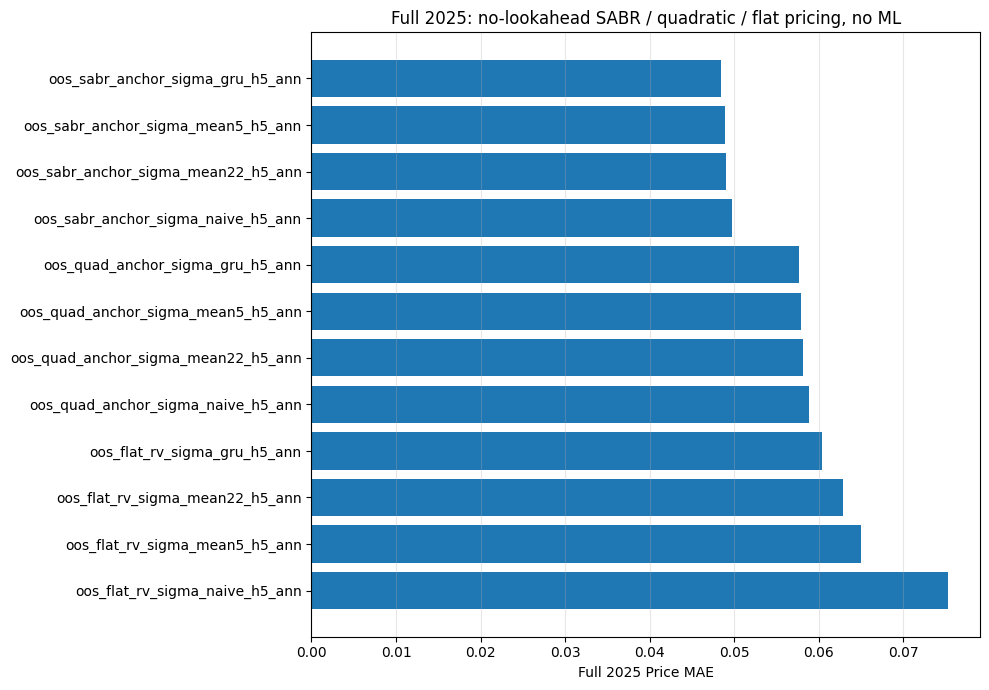

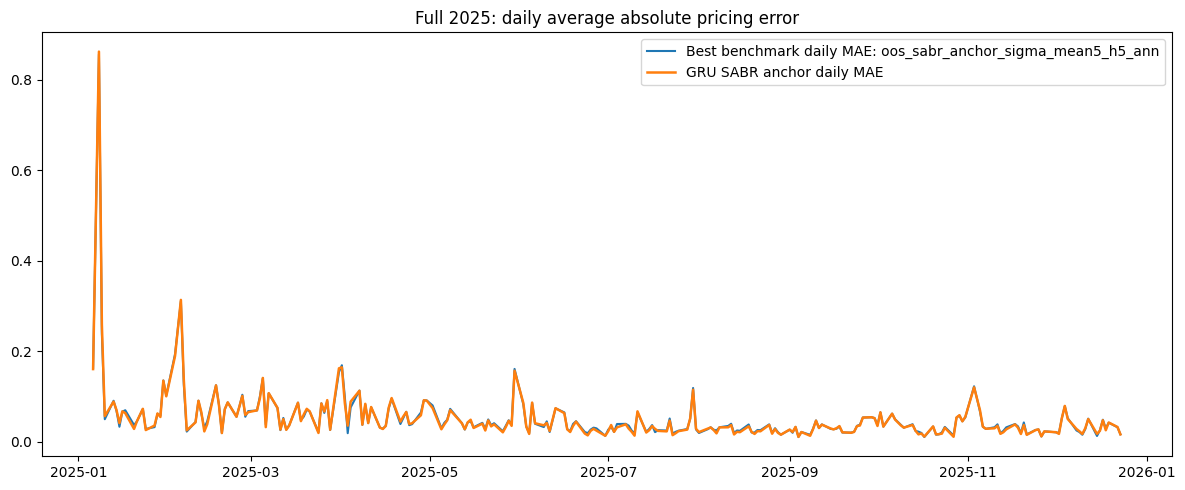

In [4]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

try:
    from IPython.display import display
except Exception:
    display = print


DATE_COL = "trade_date"
EVAL_YEAR = 2025

RV_2025_COLS = [
    "sigma_gru_h5_ann",
    "sigma_naive_h5_ann",
    "sigma_mean5_h5_ann",
    "sigma_mean22_h5_ann",
]

TRADING_DAYS = 252
RV_HORIZON_DAYS = 5
RV_ANCHOR_LAMBDA = 0.70

SABR_BETA = 1.0

IV_MIN = 0.01
IV_MAX = 3.00
SIGMA_MIN = 0.001
SIGMA_MAX = 3.00
PRICE_EPS = 1e-4
EPS = 1e-12

REBUILD_SAFE_LAG_SMILE = True
MIN_OBS_PER_DAILY_SMILE = 5

USE_CONSTANT_SAFE_SABR_RHO_NU = True
SAFE_SABR_RHO = 0.0
SAFE_SABR_NU = 0.50

RESULTS_PATH_IF_NO_OOS = resolve_input_path("trained_rv_to_iv_gk_european_cnyp_oos_2025_results.csv")
OUT_DIR = default_output_dir()


if "oos" not in globals():
    if os.path.exists(RESULTS_PATH_IF_NO_OOS):
        oos = pd.read_csv(RESULTS_PATH_IF_NO_OOS)
        print("Loaded oos from:", RESULTS_PATH_IF_NO_OOS)
    else:
        raise ValueError("No `oos` dataframe found. Run the main volatility/pricing cell first.")

df = oos.copy()

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

if "expiration_date" in df.columns:
    df["expiration_date"] = pd.to_datetime(df["expiration_date"], errors="coerce")

num_cols = [
    "strike", "T_days", "T_model", "rd", "rf", "spot_for_pricing",
    "forward_for_pricing", "moneyness", "market_price", "iv",
    "lag_quad_a", "lag_quad_b", "lag_quad_c", "lag_sabr_rho", "lag_sabr_nu",
] + RV_2025_COLS

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "forward_for_pricing" not in df.columns or df["forward_for_pricing"].isna().all():
    df["forward_for_pricing"] = df["spot_for_pricing"] * np.exp((df["rd"] - df["rf"]) * df["T_model"])

if "moneyness" not in df.columns or df["moneyness"].isna().all():
    df["moneyness"] = np.log(df["strike"] / df["forward_for_pricing"])

if "T_days" not in df.columns or df["T_days"].isna().all():
    df["T_days"] = df["T_model"] * 365.0

need_cols = [
    DATE_COL, "market_price", "spot_for_pricing", "strike",
    "T_model", "rd", "rf", "option_type"
]

missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[
    df[DATE_COL].notna()
    & np.isfinite(df["market_price"]) & (df["market_price"] > 0)
    & np.isfinite(df["spot_for_pricing"]) & (df["spot_for_pricing"] > 0)
    & np.isfinite(df["strike"]) & (df["strike"] > 0)
    & np.isfinite(df["T_model"]) & (df["T_model"] > 0)
    & np.isfinite(df["rd"])
    & np.isfinite(df["rf"])
].copy()

rv_cols_existing = [c for c in RV_2025_COLS if c in df.columns]

if len(rv_cols_existing) == 0:
    raise ValueError(f"No sigma columns found. Expected: {RV_2025_COLS}")

print("Rows in dataframe before safe lag:", len(df))
print("Date range before safe lag:", df[DATE_COL].min(), "->", df[DATE_COL].max())
print("Sigma columns:", rv_cols_existing)


def fit_daily_quadratic_smile(g):
\
\
\

    gg = g[["moneyness", "iv"]].replace([np.inf, -np.inf], np.nan).dropna()
    gg = gg[(gg["iv"] > IV_MIN) & (gg["iv"] < IV_MAX)]

    if len(gg) == 0:
        return pd.Series({
            "cur_quad_a": np.nan,
            "cur_quad_b": np.nan,
            "cur_quad_c": np.nan,
            "cur_smile_n": 0,
        })

    m = gg["moneyness"].astype(float).values
    y = gg["iv"].astype(float).values

    if len(gg) >= MIN_OBS_PER_DAILY_SMILE and np.nanstd(m) > 1e-8:
        try:
            c2, c1, c0 = np.polyfit(m, y, deg=2)
            a, b, c = c0, c1, c2
        except Exception:
            a, b, c = np.nanmedian(y), 0.0, 0.0
    else:
        a, b, c = np.nanmedian(y), 0.0, 0.0

    return pd.Series({
        "cur_quad_a": float(np.clip(a, IV_MIN, IV_MAX)),
        "cur_quad_b": float(b),
        "cur_quad_c": float(c),
        "cur_smile_n": int(len(gg)),
    })


def add_safe_lagged_smile(df_in):
    out = df_in.copy().sort_values(DATE_COL).reset_index(drop=True)

    if not REBUILD_SAFE_LAG_SMILE:
        print("WARNING: using existing lag_quad_* columns. Make sure they are truly lagged.")

        if USE_CONSTANT_SAFE_SABR_RHO_NU:
            out["lag_sabr_rho"] = SAFE_SABR_RHO
            out["lag_sabr_nu"] = SAFE_SABR_NU

        return out

    if "iv" not in out.columns:
        raise ValueError("Column `iv` is required to rebuild safe lagged smile parameters.")

    daily = (
        out.groupby(DATE_COL, sort=True)
        .apply(fit_daily_quadratic_smile)
        .reset_index()
        .sort_values(DATE_COL)
        .reset_index(drop=True)
    )

    daily[["cur_quad_a", "cur_quad_b", "cur_quad_c"]] = (
        daily[["cur_quad_a", "cur_quad_b", "cur_quad_c"]].ffill()
    )

    daily["safe_lag_quad_a"] = daily["cur_quad_a"].shift(1)
    daily["safe_lag_quad_b"] = daily["cur_quad_b"].shift(1)
    daily["safe_lag_quad_c"] = daily["cur_quad_c"].shift(1)
    daily["safe_lag_smile_source_date"] = daily[DATE_COL].shift(1)
    daily["safe_lag_smile_n"] = daily["cur_smile_n"].shift(1)

    safe = daily[[
        DATE_COL,
        "safe_lag_quad_a", "safe_lag_quad_b", "safe_lag_quad_c",
        "safe_lag_smile_source_date", "safe_lag_smile_n",
    ]]

    out = out.merge(safe, on=DATE_COL, how="left")

    out["lag_quad_a"] = out["safe_lag_quad_a"]
    out["lag_quad_b"] = out["safe_lag_quad_b"]
    out["lag_quad_c"] = out["safe_lag_quad_c"]

    if USE_CONSTANT_SAFE_SABR_RHO_NU:
        out["lag_sabr_rho"] = SAFE_SABR_RHO
        out["lag_sabr_nu"] = SAFE_SABR_NU
    else:
        out["lag_sabr_rho"] = pd.to_numeric(out["lag_sabr_rho"], errors="coerce").fillna(SAFE_SABR_RHO)
        out["lag_sabr_nu"] = pd.to_numeric(out["lag_sabr_nu"], errors="coerce").fillna(SAFE_SABR_NU)

    before = len(out)

    out = out[
        np.isfinite(out["lag_quad_a"])
        & np.isfinite(out["lag_quad_b"])
        & np.isfinite(out["lag_quad_c"])
        & (pd.to_datetime(out["safe_lag_smile_source_date"]) < pd.to_datetime(out[DATE_COL]))
    ].copy()

    print("\n================ SAFE LAGGED SMILE ================")
    print("Rebuilt lag_quad_a/b/c from previous trade date only.")
    print("Rows before safe-lag drop:", before)
    print("Rows after safe-lag drop:", len(out))
    print("First usable date:", out[DATE_COL].min())
    print("SABR rho/nu mode:", "constant safe values" if USE_CONSTANT_SAFE_SABR_RHO_NU else "provided lag_sabr columns")

    return out.reset_index(drop=True)


df = add_safe_lagged_smile(df)


eval_base = df[df[DATE_COL].dt.year == EVAL_YEAR].copy()

if len(eval_base) == 0:
    raise ValueError(f"No rows found for EVAL_YEAR={EVAL_YEAR}")

unique_eval_dates = sorted(pd.to_datetime(eval_base[DATE_COL].dropna().unique()))

if len(unique_eval_dates) < 5:
    raise ValueError(f"Not enough evaluation dates in {EVAL_YEAR}: {len(unique_eval_dates)}")

oos_base = eval_base.copy()

print("\n================ FINAL OOS SPLIT: FULL 2025 ================")
print("Evaluation year:", EVAL_YEAR)
print("Evaluation dates:", len(unique_eval_dates), "|", min(unique_eval_dates), "->", max(unique_eval_dates))
print("Evaluation rows:", len(oos_base))


def normalize_cp(cp):
    s = pd.Series(cp).astype(str).str.upper().str.strip()

    return np.where(
        s.str.startswith("C"),
        "C",
        np.where(s.str.startswith("P"), "P", s)
    )


def sabr_lognormal_vol(F, K, T, alpha, beta, rho, nu):
    F, K, T, alpha, rho, nu = np.broadcast_arrays(
        np.asarray(F, dtype=float),
        np.asarray(K, dtype=float),
        np.asarray(T, dtype=float),
        np.asarray(alpha, dtype=float),
        np.asarray(rho, dtype=float),
        np.asarray(nu, dtype=float),
    )

    beta = float(beta)

    F = np.maximum(F, EPS)
    K = np.maximum(K, EPS)
    T = np.maximum(T, EPS)
    alpha = np.maximum(alpha, EPS)
    nu = np.maximum(nu, EPS)
    rho = np.clip(rho, -0.999, 0.999)

    one_minus_beta = 1.0 - beta
    logFK = np.log(F / K)

    FK_beta = (F * K) ** (one_minus_beta / 2.0)

    denom = FK_beta * (
        1.0
        + (one_minus_beta ** 2 / 24.0) * logFK ** 2
        + (one_minus_beta ** 4 / 1920.0) * logFK ** 4
    )

    z = (nu / alpha) * FK_beta * logFK

    sqrt_term = np.sqrt(np.maximum(1.0 - 2.0 * rho * z + z ** 2, EPS))

    x_z = np.log(
        np.maximum(
            (sqrt_term + z - rho) / np.maximum(1.0 - rho, EPS),
            EPS,
        )
    )

    x_z_safe = np.where(np.abs(x_z) < EPS, EPS, x_z)
    z_over_xz = np.where(np.abs(z) < 1e-8, 1.0, z / x_z_safe)

    correction = 1.0 + (
        (one_minus_beta ** 2 / 24.0) * (alpha ** 2 / np.maximum(FK_beta ** 2, EPS))
        + (rho * beta * nu * alpha) / np.maximum(4.0 * FK_beta, EPS)
        + ((2.0 - 3.0 * rho ** 2) * nu ** 2) / 24.0
    ) * T

    vol = (alpha / np.maximum(denom, EPS)) * z_over_xz * correction

    atm = np.abs(logFK) < 1e-8

    if np.any(atm):
        F_atm = F[atm]
        T_atm = T[atm]
        alpha_atm = alpha[atm]
        rho_atm = rho[atm]
        nu_atm = nu[atm]

        vol_atm = alpha_atm / np.maximum(F_atm ** (1.0 - beta), EPS) * (
            1.0 + (
                ((1.0 - beta) ** 2 / 24.0)
                * alpha_atm ** 2
                / np.maximum(F_atm ** (2.0 - 2.0 * beta), EPS)
                + rho_atm * beta * nu_atm * alpha_atm / np.maximum(4.0 * F_atm ** (1.0 - beta), EPS)
                + ((2.0 - 3.0 * rho_atm ** 2) * nu_atm ** 2 / 24.0)
            ) * T_atm
        )

        vol[atm] = vol_atm

    vol = np.asarray(vol, dtype=float)
    vol[~np.isfinite(vol)] = np.nan

    return vol


def gk_price_vec(S, K, T, rd, rf, sigma, cp):
    S = pd.to_numeric(S, errors="coerce").astype(float).values
    K = pd.to_numeric(K, errors="coerce").astype(float).values
    T = pd.to_numeric(T, errors="coerce").astype(float).values
    rd = pd.to_numeric(rd, errors="coerce").astype(float).values
    rf = pd.to_numeric(rf, errors="coerce").astype(float).values
    sigma = pd.to_numeric(sigma, errors="coerce").astype(float).values
    cp = normalize_cp(cp)

    out = np.full(len(S), np.nan)

    ok = (
        np.isfinite(S)
        & np.isfinite(K)
        & np.isfinite(T)
        & np.isfinite(rd)
        & np.isfinite(rf)
        & np.isfinite(sigma)
        & (S > 0)
        & (K > 0)
        & (T > 0)
        & (sigma > 0)
    )

    if ok.sum() == 0:
        return pd.Series(out)

    S0, K0, T0 = S[ok], K[ok], T[ok]
    rd0, rf0, sig0 = rd[ok], rf[ok], sigma[ok]
    cp0 = cp[ok]

    vol_sqrt = sig0 * np.sqrt(T0)

    d1 = (np.log(S0 / K0) + (rd0 - rf0 + 0.5 * sig0 ** 2) * T0) / vol_sqrt
    d2 = d1 - vol_sqrt

    call = S0 * np.exp(-rf0 * T0) * norm.cdf(d1) - K0 * np.exp(-rd0 * T0) * norm.cdf(d2)
    put = K0 * np.exp(-rd0 * T0) * norm.cdf(-d2) - S0 * np.exp(-rf0 * T0) * norm.cdf(-d1)

    out[ok] = np.where(cp0 == "C", call, put)

    return pd.Series(out)


def gk_bounds_vec(df_in):
    S = pd.to_numeric(df_in["spot_for_pricing"], errors="coerce").astype(float)
    K = pd.to_numeric(df_in["strike"], errors="coerce").astype(float)
    T = pd.to_numeric(df_in["T_model"], errors="coerce").astype(float)
    rd = pd.to_numeric(df_in["rd"], errors="coerce").astype(float)
    rf = pd.to_numeric(df_in["rf"], errors="coerce").astype(float)
    cp = normalize_cp(df_in["option_type"])

    disc_S = S * np.exp(-rf * T)
    disc_K = K * np.exp(-rd * T)

    lower = np.where(
        cp == "C",
        np.maximum(disc_S - disc_K, 0.0),
        np.maximum(disc_K - disc_S, 0.0),
    )

    upper = np.where(cp == "C", disc_S, disc_K)

    return pd.Series(lower, index=df_in.index), pd.Series(upper, index=df_in.index)


def compute_pricing_variants(df_in, sigma_col):
    out = df_in.copy()

    sig = pd.to_numeric(out[sigma_col], errors="coerce").astype(float).clip(SIGMA_MIN, SIGMA_MAX)

    ann_var_rv = sig ** 2

    lag_atm_iv = pd.to_numeric(out["lag_quad_a"], errors="coerce").astype(float).clip(IV_MIN, IV_MAX)
    lag_atm_var = lag_atm_iv ** 2

    T = pd.to_numeric(out["T_model"], errors="coerce").astype(float).clip(lower=EPS)

    H = RV_HORIZON_DAYS / TRADING_DAYS

    short_part = np.minimum(T, H)
    long_part = np.maximum(T - H, 0.0)

    rv_term_var = (short_part * ann_var_rv + long_part * lag_atm_var) / T

    anchored_atm_var = RV_ANCHOR_LAMBDA * rv_term_var + (1.0 - RV_ANCHOR_LAMBDA) * lag_atm_var
    anchored_atm_iv = np.sqrt(anchored_atm_var).clip(IV_MIN, IV_MAX)

    m = pd.to_numeric(out["moneyness"], errors="coerce").astype(float)

    lag_b = pd.to_numeric(out["lag_quad_b"], errors="coerce").fillna(0.0).astype(float)
    lag_c = pd.to_numeric(out["lag_quad_c"], errors="coerce").fillna(0.0).astype(float)

    iv_quad = (anchored_atm_iv + lag_b * m + lag_c * m ** 2).clip(IV_MIN, IV_MAX)

    F = pd.to_numeric(out["forward_for_pricing"], errors="coerce").astype(float).clip(lower=EPS)
    K = pd.to_numeric(out["strike"], errors="coerce").astype(float).clip(lower=EPS)

    rho = pd.to_numeric(out["lag_sabr_rho"], errors="coerce").fillna(SAFE_SABR_RHO).astype(float)
    nu = pd.to_numeric(out["lag_sabr_nu"], errors="coerce").fillna(SAFE_SABR_NU).astype(float)

    sabr_alpha_anchor = (anchored_atm_iv * (F ** (1.0 - SABR_BETA))).clip(1e-4, 5.0)

    iv_sabr = sabr_lognormal_vol(
        F.values,
        K.values,
        T.values,
        sabr_alpha_anchor.values,
        SABR_BETA,
        rho.values,
        nu.values,
    )

    iv_sabr = pd.Series(iv_sabr, index=out.index).replace([np.inf, -np.inf], np.nan)

    bad = iv_sabr.isna() | (iv_sabr < IV_MIN) | (iv_sabr > IV_MAX)
    iv_sabr.loc[bad] = iv_quad.loc[bad]
    iv_sabr = iv_sabr.clip(IV_MIN, IV_MAX)

    out["model_sigma_input"] = sig
    out["model_atm_iv_anchor"] = anchored_atm_iv
    out["model_iv_quad_anchor"] = iv_quad
    out["model_iv_sabr_anchor"] = iv_sabr

    out["price_flat_rv"] = gk_price_vec(
        out["spot_for_pricing"],
        out["strike"],
        out["T_model"],
        out["rd"],
        out["rf"],
        sig,
        out["option_type"],
    ).values

    out["price_quad_anchor"] = gk_price_vec(
        out["spot_for_pricing"],
        out["strike"],
        out["T_model"],
        out["rd"],
        out["rf"],
        out["model_iv_quad_anchor"],
        out["option_type"],
    ).values

    out["price_sabr_anchor"] = gk_price_vec(
        out["spot_for_pricing"],
        out["strike"],
        out["T_model"],
        out["rd"],
        out["rf"],
        out["model_iv_sabr_anchor"],
        out["option_type"],
    ).values

    lower, upper = gk_bounds_vec(out)

    out["price_lower_bound"] = lower
    out["price_upper_bound"] = upper

    for c in ["price_flat_rv", "price_quad_anchor", "price_sabr_anchor"]:
        out[c] = pd.to_numeric(out[c], errors="coerce").clip(lower=0.0)
        out[c] = np.maximum(out[c], out["price_lower_bound"])

        upper_ok = np.isfinite(out["price_upper_bound"])
        out.loc[upper_ok, c] = np.minimum(
            out.loc[upper_ok, c],
            out.loc[upper_ok, "price_upper_bound"]
        )

    return out


def calc_metrics(df_in, price_col, label=None):
    d = df_in[[price_col, "market_price"]].replace([np.inf, -np.inf], np.nan).dropna()
    d = d[d["market_price"] > 0]

    if len(d) == 0:
        return {
            "model": label or price_col,
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "MedianAE": np.nan,
            "WMAPE_pct": np.nan,
        }

    err = d[price_col] - d["market_price"]

    return {
        "model": label or price_col,
        "n": len(d),
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "Bias": float(np.mean(err)),
        "MedianAE": float(np.median(np.abs(err))),
        "WMAPE_pct": float(100 * np.sum(np.abs(err)) / np.sum(np.abs(d["market_price"]))),
    }


oos_result = oos_base.copy()
oos_context_cols = []

for sig_col in rv_cols_existing:
    print(f"Scoring deterministic pricing variants for: {sig_col}")

    tmp = compute_pricing_variants(oos_base.copy(), sig_col)

    flat_col = f"oos_flat_rv_{sig_col}"
    quad_col = f"oos_quad_anchor_{sig_col}"
    sabr_col = f"oos_sabr_anchor_{sig_col}"

    iv_quad_col = f"oos_iv_quad_anchor_{sig_col}"
    iv_sabr_col = f"oos_iv_sabr_anchor_{sig_col}"
    atm_col = f"oos_atm_iv_anchor_{sig_col}"

    oos_result[flat_col] = tmp["price_flat_rv"].values
    oos_result[quad_col] = tmp["price_quad_anchor"].values
    oos_result[sabr_col] = tmp["price_sabr_anchor"].values

    oos_result[iv_quad_col] = tmp["model_iv_quad_anchor"].values
    oos_result[iv_sabr_col] = tmp["model_iv_sabr_anchor"].values
    oos_result[atm_col] = tmp["model_atm_iv_anchor"].values

    oos_context_cols.extend([flat_col, quad_col, sabr_col])


oos_context_cols = list(dict.fromkeys(oos_context_cols))

oos_metrics = pd.DataFrame([
    calc_metrics(oos_result, c, label=c)
    for c in oos_context_cols
])

oos_metrics = oos_metrics.sort_values(["MAE", "RMSE"]).reset_index(drop=True)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)

print("\n================ FINAL OOS PRICE METRICS: FULL 2025, NO ML ================")
print("Evaluation dates:", oos_result[DATE_COL].min(), "->", oos_result[DATE_COL].max())
print("Evaluation rows:", len(oos_result))
display(oos_metrics)


def metrics_dict_for_col(metrics_df, model_col):
    r = metrics_df[metrics_df["model"] == model_col]

    if len(r) == 0:
        return None

    return r.iloc[0].to_dict()


def improvement_row(base_label, base_col, final_col):
    b = metrics_dict_for_col(oos_metrics, base_col)
    f = metrics_dict_for_col(oos_metrics, final_col)

    if b is None or f is None:
        return None

    return {
        "comparison": base_label,
        "base_model": base_col,
        "final_model": final_col,
        "base_MAE": b["MAE"],
        "final_MAE": f["MAE"],
        "MAE_improvement_%": 100.0 * (b["MAE"] - f["MAE"]) / max(b["MAE"], EPS),
        "base_RMSE": b["RMSE"],
        "final_RMSE": f["RMSE"],
        "RMSE_improvement_%": 100.0 * (b["RMSE"] - f["RMSE"]) / max(b["RMSE"], EPS),
        "base_WMAPE_pct": b["WMAPE_pct"],
        "final_WMAPE_pct": f["WMAPE_pct"],
        "WMAPE_improvement_%": 100.0 * (b["WMAPE_pct"] - f["WMAPE_pct"]) / max(b["WMAPE_pct"], EPS),
        "base_Bias": b["Bias"],
        "final_Bias": f["Bias"],
    }


imp_rows = []

gru_sabr_col = "oos_sabr_anchor_sigma_gru_h5_ann"

if gru_sabr_col in oos_metrics["model"].values:
    for sig_col in rv_cols_existing:
        if sig_col == "sigma_gru_h5_ann":
            continue

        bench_col = f"oos_sabr_anchor_{sig_col}"

        if bench_col in oos_metrics["model"].values:
            imp_rows.append(
                improvement_row(
                    f"GRU SABR anchor vs {sig_col} SABR anchor",
                    bench_col,
                    gru_sabr_col,
                )
            )

    gru_quad_col = "oos_quad_anchor_sigma_gru_h5_ann"
    gru_flat_col = "oos_flat_rv_sigma_gru_h5_ann"

    if gru_quad_col in oos_metrics["model"].values:
        imp_rows.append(
            improvement_row(
                "GRU SABR anchor vs GRU quadratic smile anchor",
                gru_quad_col,
                gru_sabr_col,
            )
        )

    if gru_flat_col in oos_metrics["model"].values:
        imp_rows.append(
            improvement_row(
                "GRU SABR anchor vs GRU flat RV price",
                gru_flat_col,
                gru_sabr_col,
            )
        )

improvement_df = pd.DataFrame([r for r in imp_rows if r is not None])

print("\n================ FINAL OOS IMPROVEMENT REPORT: FULL 2025, NO ML ================")

if len(improvement_df) > 0:
    display(improvement_df.round({
        "base_MAE": 6,
        "final_MAE": 6,
        "MAE_improvement_%": 2,
        "base_RMSE": 6,
        "final_RMSE": 6,
        "RMSE_improvement_%": 2,
        "base_WMAPE_pct": 4,
        "final_WMAPE_pct": 4,
        "WMAPE_improvement_%": 2,
        "base_Bias": 6,
        "final_Bias": 6,
    }))
else:
    print("No improvement rows available. Check whether sigma_gru_h5_ann exists.")


type_rows = []

for opt_type, g in oos_result.groupby("option_type", dropna=False):
    for c in oos_context_cols:
        m = calc_metrics(g, c, label=c)
        m["option_type"] = str(opt_type)
        type_rows.append(m)

oos_by_type = pd.DataFrame(type_rows).sort_values(["option_type", "MAE"])

print("\n================ FINAL OOS BY OPTION TYPE: FULL 2025, NO ML ================")
display(oos_by_type.groupby("option_type").head(15))


def expiration_bucket_short(t):
    if pd.isna(t):
        return np.nan
    if t <= 7:
        return "1 week (<=7d)"
    if t <= 14:
        return "2 weeks (8-14d)"
    if t <= 31:
        return "1 month (15-31d)"
    return "longer than 1 month"


oos_result["expiration_bucket_short"] = oos_result["T_days"].apply(expiration_bucket_short)

exp_rows = []

for bucket, g in oos_result.groupby("expiration_bucket_short", dropna=False):
    for c in oos_context_cols:
        m = calc_metrics(g, c, label=c)
        m["expiration_bucket"] = str(bucket)
        exp_rows.append(m)

oos_by_expiration = pd.DataFrame(exp_rows).sort_values(["expiration_bucket", "MAE"])

print("\n================ FINAL OOS BY EXPIRATION: FULL 2025, NO ML ================")
display(oos_by_expiration.groupby("expiration_bucket").head(10))


out_oos_results = f"{OUT_DIR}/oos_full2025_no_ml_sabr_results.csv"
out_oos_metrics = f"{OUT_DIR}/oos_full2025_no_ml_sabr_metrics.csv"
out_oos_improvement = f"{OUT_DIR}/oos_full2025_no_ml_sabr_improvement.csv"
out_oos_type = f"{OUT_DIR}/oos_full2025_no_ml_sabr_metrics_by_type.csv"
out_oos_exp = f"{OUT_DIR}/oos_full2025_no_ml_sabr_metrics_by_expiration.csv"

oos_result.to_csv(out_oos_results, index=False)
oos_metrics.to_csv(out_oos_metrics, index=False)

if len(improvement_df) > 0:
    improvement_df.to_csv(out_oos_improvement, index=False)

oos_by_type.to_csv(out_oos_type, index=False)
oos_by_expiration.to_csv(out_oos_exp, index=False)

print("\nSaved:")
print(out_oos_results)
print(out_oos_metrics)

if len(improvement_df) > 0:
    print(out_oos_improvement)

print(out_oos_type)
print(out_oos_exp)


plot_df = oos_metrics.head(20).copy()

plt.figure(figsize=(10, 7))
plt.barh(plot_df["model"][::-1], plot_df["MAE"][::-1])
plt.xlabel("Full 2025 Price MAE")
plt.title("Full 2025: no-lookahead SABR / quadratic / flat pricing, no ML")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

if gru_sabr_col in oos_result.columns:
    best_benchmark_col = None

    benchmark_candidates = [
        c for c in oos_context_cols
        if c != gru_sabr_col and c in oos_metrics["model"].values
    ]

    if len(benchmark_candidates) > 0:
        best_benchmark_col = (
            oos_metrics[oos_metrics["model"].isin(benchmark_candidates)]
            .sort_values(["MAE", "RMSE"])
            .iloc[0]["model"]
        )

    if best_benchmark_col is not None:
        err_plot = oos_result[[DATE_COL, "market_price", best_benchmark_col, gru_sabr_col]].dropna().copy()

        if len(err_plot) > 0:
            err_plot["benchmark_abs_error"] = (
                err_plot[best_benchmark_col] - err_plot["market_price"]
            ).abs()

            err_plot["gru_sabr_abs_error"] = (
                err_plot[gru_sabr_col] - err_plot["market_price"]
            ).abs()

            daily_err = (
                err_plot
                .groupby(DATE_COL)[["benchmark_abs_error", "gru_sabr_abs_error"]]
                .mean()
                .reset_index()
            )

            plt.figure(figsize=(12, 5))
            plt.plot(
                daily_err[DATE_COL],
                daily_err["benchmark_abs_error"],
                label=f"Best benchmark daily MAE: {best_benchmark_col}",
                linewidth=1.5,
            )

            plt.plot(
                daily_err[DATE_COL],
                daily_err["gru_sabr_abs_error"],
                label="GRU SABR anchor daily MAE",
                linewidth=1.8,
            )

            plt.title("Full 2025: daily average absolute pricing error")
            plt.legend()
            plt.tight_layout()
            plt.show()


Rows before safe lag: 5834
Date range before safe lag: 2025-01-03 00:00:00 -> 2025-12-23 00:00:00
Sigma columns: ['sigma_gru_h5_ann', 'sigma_naive_h5_ann', 'sigma_mean5_h5_ann', 'sigma_mean22_h5_ann']

================ SAFE LAGGED SMILE ================
Rebuilt lag_quad_a/b/c from previous trade date only.
Rows before safe-lag drop: 5834
Rows after safe-lag drop: 5825
First usable date: 2025-01-06 00:00:00
SABR rho/nu mode: constant safe values

================ CALENDAR SPLIT ================
Train: 2025-01-06 00:00:00 -> 2025-05-30 00:00:00 | rows: 2617
Validation: 2025-06-02 00:00:00 -> 2025-07-31 00:00:00 | rows: 984
OOS: 2025-08-01 00:00:00 -> 2025-12-23 00:00:00 | rows: 2224
Final refit on train+validation: True

================ MODEL SELECTION FOR sigma_gru_h5_ann ================
Train rows: 2617 | 2025-01-06 00:00:00 -> 2025-05-30 00:00:00
Validation rows: 984 | 2025-06-02 00:00:00 -> 2025-07-31 00:00:00

Validation metrics:


,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,sigma_col,period,kind
0,valid_priceaware_residual_price_global_sigma_gru_h5_ann,984,0.033931,0.045685,0.015172,0.025459,10.855560,sigma_gru_h5_ann,validation,priceaware_ml
1,valid_priceaware_vega_residual_global_sigma_gru_h5_ann,984,0.034147,0.046981,0.013669,0.025351,10.924578,sigma_gru_h5_ann,validation,priceaware_ml
2,valid_priceaware_log_price_ratio_global_sigma_gru_h5_ann,984,0.034450,0.047486,0.009203,0.025559,11.021595,sigma_gru_h5_ann,validation,priceaware_ml
3,valid_sabr_anchor_sigma_gru_h5_ann,984,0.035775,0.052911,-0.012281,0.024529,11.445350,sigma_gru_h5_ann,validation,base
4,valid_priceaware_log_price_ratio_byCP_sigma_gru_h5_ann,984,0.041050,0.054900,0.020012,0.031544,13.132978,sigma_gru_h5_ann,validation,priceaware_ml
5,valid_priceaware_residual_price_byCP_sigma_gru_h5_ann,984,0.041821,0.051872,0.026961,0.036117,13.379633,sigma_gru_h5_ann,validation,priceaware_ml
6,valid_priceaware_vega_residual_byCP_sigma_gru_h5_ann,984,0.041887,0.054310,0.025619,0.035080,13.400625,sigma_gru_h5_ann,validation,priceaware_ml
7,valid_quad_anchor_sigma_gru_h5_ann,984,0.044573,0.088306,0.002716,0.024716,14.260209,sigma_gru_h5_ann,validation,base
8,valid_flat_rv_sigma_gru_h5_ann,984,0.053351,0.070268,-0.051383,0.041554,17.068274,sigma_gru_h5_ann,validation,base



Selected spec for sigma_gru_h5_ann : residual_price_global

================ MODEL SELECTION FOR sigma_naive_h5_ann ================
Train rows: 2617 | 2025-01-06 00:00:00 -> 2025-05-30 00:00:00
Validation rows: 984 | 2025-06-02 00:00:00 -> 2025-07-31 00:00:00

Validation metrics:


,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,sigma_col,period,kind
0,valid_priceaware_log_price_ratio_global_sigma_naive_h5_ann,984,0.035980,0.050026,0.012606,0.026682,11.511059,sigma_naive_h5_ann,validation,priceaware_ml
1,valid_sabr_anchor_sigma_naive_h5_ann,984,0.037086,0.053671,-0.013693,0.025942,11.864805,sigma_naive_h5_ann,validation,base
2,valid_priceaware_residual_price_global_sigma_naive_h5_ann,984,0.037139,0.048921,0.018691,0.028454,11.881706,sigma_naive_h5_ann,validation,priceaware_ml
3,valid_priceaware_vega_residual_global_sigma_naive_h5_ann,984,0.041370,0.054705,0.024383,0.032808,13.235280,sigma_naive_h5_ann,validation,priceaware_ml
4,valid_quad_anchor_sigma_naive_h5_ann,984,0.045509,0.088429,0.001132,0.026857,14.559424,sigma_naive_h5_ann,validation,base
5,valid_priceaware_residual_price_byCP_sigma_naive_h5_ann,984,0.045993,0.056257,0.030941,0.041336,14.714454,sigma_naive_h5_ann,validation,priceaware_ml
6,valid_priceaware_log_price_ratio_byCP_sigma_naive_h5_ann,984,0.047717,0.061923,0.027707,0.038552,15.265815,sigma_naive_h5_ann,validation,priceaware_ml
7,valid_priceaware_vega_residual_byCP_sigma_naive_h5_ann,984,0.054754,0.070090,0.038954,0.047534,17.517146,sigma_naive_h5_ann,validation,priceaware_ml
8,valid_flat_rv_sigma_naive_h5_ann,984,0.072335,0.096693,-0.061570,0.052973,23.141951,sigma_naive_h5_ann,validation,base



Selected spec for sigma_naive_h5_ann : log_price_ratio_global

================ MODEL SELECTION FOR sigma_mean5_h5_ann ================
Train rows: 2617 | 2025-01-06 00:00:00 -> 2025-05-30 00:00:00
Validation rows: 984 | 2025-06-02 00:00:00 -> 2025-07-31 00:00:00

Validation metrics:


...


================ OOS BY OPTION TYPE ================


,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,option_type
3,oos_priceaware_ml_residual_price_global_sigma_gru_h5_ann,1488,0.024067,0.032685,0.003958,0.017764,8.580906,C
2,oos_sabr_anchor_sigma_gru_h5_ann,1488,0.025299,0.034672,-0.005661,0.018380,9.020083,C
11,oos_priceaware_ml_log_price_ratio_global_sigma_mean5_h5_ann,1488,0.025614,0.035349,-0.001864,0.018617,9.132428,C
10,oos_sabr_anchor_sigma_mean5_h5_ann,1488,0.025711,0.035116,-0.007553,0.018553,9.167043,C
7,oos_priceaware_ml_log_price_ratio_global_sigma_naive_h5_ann,1488,0.025756,0.035896,-0.000796,0.018831,9.183177,C
14,oos_sabr_anchor_sigma_mean22_h5_ann,1488,0.026129,0.035470,-0.008358,0.019537,9.316016,C
6,oos_sabr_anchor_sigma_naive_h5_ann,1488,0.026205,0.035790,-0.006969,0.019692,9.343235,C
15,oos_priceaware_ml_vega_residual_global_sigma_mean22_h5_ann,1488,0.027804,0.037009,0.006488,0.021440,9.913140,C
0,oos_flat_rv_sigma_gru_h5_ann,1488,0.037784,0.050496,-0.032702,0.028310,13.471448,C
1,oos_quad_anchor_sigma_gru_h5_ann,1488,0.040453,0.098698,0.016580,0.020258,14.423024,C



================ OOS BY EXPIRATION ================


,model,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,expiration_bucket
3,oos_priceaware_ml_residual_price_global_sigma_gru_h5_ann,540,0.027625,0.036527,0.001194,0.022074,10.268263,1 month (15-31d)
7,oos_priceaware_ml_log_price_ratio_global_sigma_naive_h5_ann,540,0.028090,0.037780,-0.001321,0.020793,10.441070,1 month (15-31d)
11,oos_priceaware_ml_log_price_ratio_global_sigma_mean5_h5_ann,540,0.029244,0.038642,-0.003425,0.022102,10.870195,1 month (15-31d)
2,oos_sabr_anchor_sigma_gru_h5_ann,540,0.029452,0.038715,-0.006750,0.022039,10.947325,1 month (15-31d)
6,oos_sabr_anchor_sigma_naive_h5_ann,540,0.029755,0.039232,-0.008807,0.024124,11.060090,1 month (15-31d)
10,oos_sabr_anchor_sigma_mean5_h5_ann,540,0.029914,0.039266,-0.008789,0.022850,11.119360,1 month (15-31d)
14,oos_sabr_anchor_sigma_mean22_h5_ann,540,0.030153,0.039433,-0.009375,0.023476,11.208212,1 month (15-31d)
15,oos_priceaware_ml_vega_residual_global_sigma_mean22_h5_ann,540,0.032374,0.042027,0.008241,0.025436,12.033691,1 month (15-31d)
5,oos_quad_anchor_sigma_naive_h5_ann,540,0.038482,0.056995,0.007254,0.025295,14.303827,1 month (15-31d)
1,oos_quad_anchor_sigma_gru_h5_ann,540,0.038750,0.057527,0.009440,0.026217,14.403778,1 month (15-31d)



Saved:
outputs/priceaware_ml_validation_metrics_5m_train_2m_val.csv
outputs/priceaware_ml_selected_specs_5m_train_2m_val.csv
outputs/priceaware_ml_oos_results_5m_train_2m_val.csv
outputs/priceaware_ml_oos_metrics_5m_train_2m_val.csv
outputs/priceaware_ml_final_model_info_5m_train_2m_val.csv
outputs/priceaware_ml_oos_improvement_5m_train_2m_val.csv
outputs/priceaware_ml_oos_metrics_by_type_5m_train_2m_val.csv
outputs/priceaware_ml_oos_metrics_by_expiration_5m_train_2m_val.csv


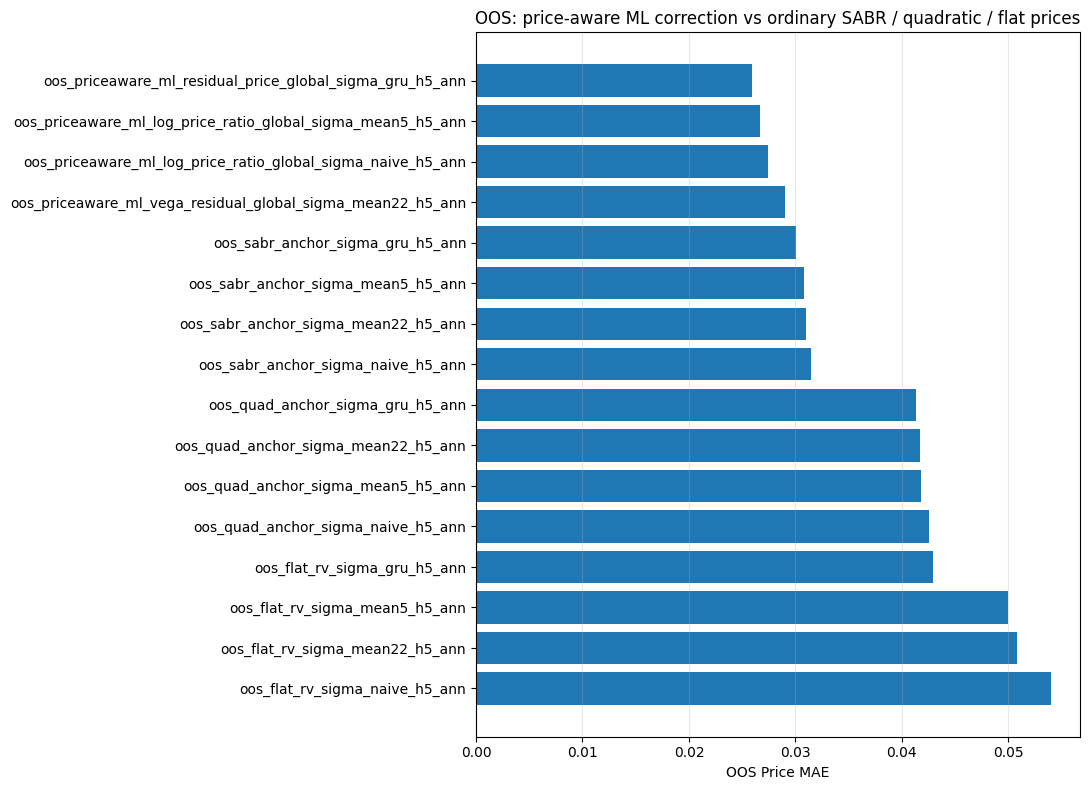

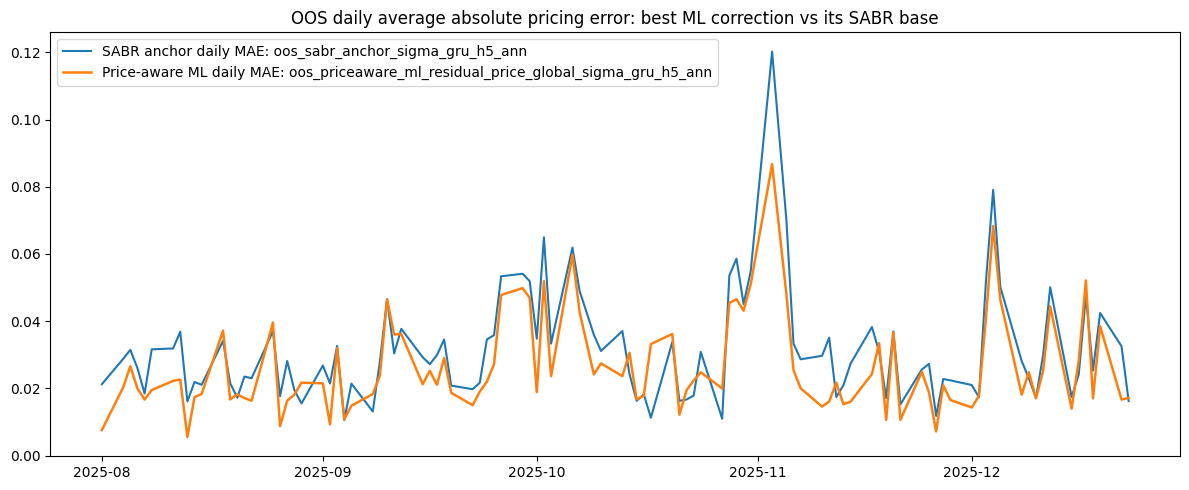

In [5]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

try:
    from IPython.display import display
except Exception:
    display = print


DATE_COL = "trade_date"
EVAL_YEAR = 2025

RV_2025_COLS = [
    "sigma_gru_h5_ann",
    "sigma_naive_h5_ann",
    "sigma_mean5_h5_ann",
    "sigma_mean22_h5_ann",
]


TRAIN_MONTHS = 5
VALIDATION_MONTHS = 2


FINAL_REFIT_ON_TRAIN_PLUS_VALIDATION = True

TRADING_DAYS = 252
RV_HORIZON_DAYS = 5
RV_ANCHOR_LAMBDA = 0.70

SABR_BETA = 1.0

IV_MIN = 0.01
IV_MAX = 3.00
SIGMA_MIN = 0.001
SIGMA_MAX = 3.00
PRICE_EPS = 1e-4
EPS = 1e-12

REBUILD_SAFE_LAG_SMILE = True
MIN_OBS_PER_DAILY_SMILE = 5

USE_CONSTANT_SAFE_SABR_RHO_NU = True
SAFE_SABR_RHO = 0.0
SAFE_SABR_NU = 0.50

RANDOM_STATE = 42
SELECTION_METRIC = "MAE"

RESULTS_PATH_IF_NO_OOS = resolve_input_path("trained_rv_to_iv_gk_european_cnyp_oos_2025_results.csv")
OUT_DIR = default_output_dir()


if "oos" not in globals():
    if os.path.exists(RESULTS_PATH_IF_NO_OOS):
        oos = pd.read_csv(RESULTS_PATH_IF_NO_OOS)
        print("Loaded oos from:", RESULTS_PATH_IF_NO_OOS)
    else:
        raise ValueError("No `oos` dataframe found. Run the main volatility/pricing cell first.")

df = oos.copy()

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

if "expiration_date" in df.columns:
    df["expiration_date"] = pd.to_datetime(df["expiration_date"], errors="coerce")

num_cols = [
    "strike", "T_days", "T_model", "rd", "rf", "spot_for_pricing",
    "forward_for_pricing", "moneyness", "market_price", "iv",
    "lag_quad_a", "lag_quad_b", "lag_quad_c", "lag_sabr_rho", "lag_sabr_nu",
] + RV_2025_COLS

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "forward_for_pricing" not in df.columns or df["forward_for_pricing"].isna().all():
    df["forward_for_pricing"] = df["spot_for_pricing"] * np.exp((df["rd"] - df["rf"]) * df["T_model"])

if "moneyness" not in df.columns or df["moneyness"].isna().all():
    df["moneyness"] = np.log(df["strike"] / df["forward_for_pricing"])

if "T_days" not in df.columns or df["T_days"].isna().all():
    df["T_days"] = df["T_model"] * 365.0

need_cols = [
    DATE_COL, "market_price", "spot_for_pricing", "strike",
    "T_model", "rd", "rf", "option_type", "iv"
]

missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[
    df[DATE_COL].notna()
    & np.isfinite(df["market_price"]) & (df["market_price"] > 0)
    & np.isfinite(df["spot_for_pricing"]) & (df["spot_for_pricing"] > 0)
    & np.isfinite(df["strike"]) & (df["strike"] > 0)
    & np.isfinite(df["T_model"]) & (df["T_model"] > 0)
    & np.isfinite(df["rd"])
    & np.isfinite(df["rf"])
].copy()

rv_cols_existing = [c for c in RV_2025_COLS if c in df.columns]

if len(rv_cols_existing) == 0:
    raise ValueError(f"No sigma columns found. Expected: {RV_2025_COLS}")

print("Rows before safe lag:", len(df))
print("Date range before safe lag:", df[DATE_COL].min(), "->", df[DATE_COL].max())
print("Sigma columns:", rv_cols_existing)


def fit_daily_quadratic_smile(g):
\
\
\

    gg = g[["moneyness", "iv"]].replace([np.inf, -np.inf], np.nan).dropna()
    gg = gg[(gg["iv"] > IV_MIN) & (gg["iv"] < IV_MAX)]

    if len(gg) == 0:
        return pd.Series({
            "cur_quad_a": np.nan,
            "cur_quad_b": np.nan,
            "cur_quad_c": np.nan,
            "cur_smile_n": 0,
        })

    m = gg["moneyness"].astype(float).values
    y = gg["iv"].astype(float).values

    if len(gg) >= MIN_OBS_PER_DAILY_SMILE and np.nanstd(m) > 1e-8:
        try:
            c2, c1, c0 = np.polyfit(m, y, deg=2)
            a, b, c = c0, c1, c2
        except Exception:
            a, b, c = np.nanmedian(y), 0.0, 0.0
    else:
        a, b, c = np.nanmedian(y), 0.0, 0.0

    return pd.Series({
        "cur_quad_a": float(np.clip(a, IV_MIN, IV_MAX)),
        "cur_quad_b": float(b),
        "cur_quad_c": float(c),
        "cur_smile_n": int(len(gg)),
    })


def add_safe_lagged_smile(df_in):
    out = df_in.copy().sort_values(DATE_COL).reset_index(drop=True)

    if not REBUILD_SAFE_LAG_SMILE:
        print("WARNING: using existing lag_quad_* columns. Make sure they are truly lagged.")

        if USE_CONSTANT_SAFE_SABR_RHO_NU:
            out["lag_sabr_rho"] = SAFE_SABR_RHO
            out["lag_sabr_nu"] = SAFE_SABR_NU

        return out

    daily = (
        out.groupby(DATE_COL, sort=True)
        .apply(fit_daily_quadratic_smile)
        .reset_index()
        .sort_values(DATE_COL)
        .reset_index(drop=True)
    )

    daily[["cur_quad_a", "cur_quad_b", "cur_quad_c"]] = (
        daily[["cur_quad_a", "cur_quad_b", "cur_quad_c"]].ffill()
    )

    daily["safe_lag_quad_a"] = daily["cur_quad_a"].shift(1)
    daily["safe_lag_quad_b"] = daily["cur_quad_b"].shift(1)
    daily["safe_lag_quad_c"] = daily["cur_quad_c"].shift(1)
    daily["safe_lag_smile_source_date"] = daily[DATE_COL].shift(1)
    daily["safe_lag_smile_n"] = daily["cur_smile_n"].shift(1)

    safe = daily[[
        DATE_COL,
        "safe_lag_quad_a", "safe_lag_quad_b", "safe_lag_quad_c",
        "safe_lag_smile_source_date", "safe_lag_smile_n",
    ]]

    out = out.merge(safe, on=DATE_COL, how="left")

    out["lag_quad_a"] = out["safe_lag_quad_a"]
    out["lag_quad_b"] = out["safe_lag_quad_b"]
    out["lag_quad_c"] = out["safe_lag_quad_c"]

    if USE_CONSTANT_SAFE_SABR_RHO_NU:
        out["lag_sabr_rho"] = SAFE_SABR_RHO
        out["lag_sabr_nu"] = SAFE_SABR_NU
    else:
        out["lag_sabr_rho"] = pd.to_numeric(out["lag_sabr_rho"], errors="coerce").fillna(SAFE_SABR_RHO)
        out["lag_sabr_nu"] = pd.to_numeric(out["lag_sabr_nu"], errors="coerce").fillna(SAFE_SABR_NU)

    before = len(out)

    out = out[
        np.isfinite(out["lag_quad_a"])
        & np.isfinite(out["lag_quad_b"])
        & np.isfinite(out["lag_quad_c"])
        & (pd.to_datetime(out["safe_lag_smile_source_date"]) < pd.to_datetime(out[DATE_COL]))
    ].copy()

    print("\n================ SAFE LAGGED SMILE ================")
    print("Rebuilt lag_quad_a/b/c from previous trade date only.")
    print("Rows before safe-lag drop:", before)
    print("Rows after safe-lag drop:", len(out))
    print("First usable date:", out[DATE_COL].min())
    print("SABR rho/nu mode:", "constant safe values" if USE_CONSTANT_SAFE_SABR_RHO_NU else "provided lag_sabr columns")

    return out.reset_index(drop=True)


df = add_safe_lagged_smile(df)


year_start = pd.Timestamp(f"{EVAL_YEAR}-01-01")
year_end = pd.Timestamp(f"{EVAL_YEAR + 1}-01-01")

train_start = year_start
valid_start = year_start + pd.DateOffset(months=TRAIN_MONTHS)
oos_start = valid_start + pd.DateOffset(months=VALIDATION_MONTHS)

eval_2025 = df[
    (df[DATE_COL] >= year_start)
    & (df[DATE_COL] < year_end)
].copy()

train_base = eval_2025[
    (eval_2025[DATE_COL] >= train_start)
    & (eval_2025[DATE_COL] < valid_start)
].copy()

valid_base = eval_2025[
    (eval_2025[DATE_COL] >= valid_start)
    & (eval_2025[DATE_COL] < oos_start)
].copy()

oos_base = eval_2025[
    (eval_2025[DATE_COL] >= oos_start)
    & (eval_2025[DATE_COL] < year_end)
].copy()

if len(train_base) == 0:
    raise ValueError("Train period is empty.")
if len(valid_base) == 0:
    raise ValueError("Validation period is empty.")
if len(oos_base) == 0:
    raise ValueError("OOS period is empty.")

print("\n================ CALENDAR SPLIT ================")
print("Train:", train_base[DATE_COL].min(), "->", train_base[DATE_COL].max(), "| rows:", len(train_base))
print("Validation:", valid_base[DATE_COL].min(), "->", valid_base[DATE_COL].max(), "| rows:", len(valid_base))
print("OOS:", oos_base[DATE_COL].min(), "->", oos_base[DATE_COL].max(), "| rows:", len(oos_base))
print("Final refit on train+validation:", FINAL_REFIT_ON_TRAIN_PLUS_VALIDATION)


def normalize_cp(cp):
    s = pd.Series(cp).astype(str).str.upper().str.strip()

    return np.where(
        s.str.startswith("C"),
        "C",
        np.where(s.str.startswith("P"), "P", s)
    )


def sabr_lognormal_vol(F, K, T, alpha, beta, rho, nu):
    F, K, T, alpha, rho, nu = np.broadcast_arrays(
        np.asarray(F, dtype=float),
        np.asarray(K, dtype=float),
        np.asarray(T, dtype=float),
        np.asarray(alpha, dtype=float),
        np.asarray(rho, dtype=float),
        np.asarray(nu, dtype=float),
    )

    beta = float(beta)

    F = np.maximum(F, EPS)
    K = np.maximum(K, EPS)
    T = np.maximum(T, EPS)
    alpha = np.maximum(alpha, EPS)
    nu = np.maximum(nu, EPS)
    rho = np.clip(rho, -0.999, 0.999)

    one_minus_beta = 1.0 - beta
    logFK = np.log(F / K)

    FK_beta = (F * K) ** (one_minus_beta / 2.0)

    denom = FK_beta * (
        1.0
        + (one_minus_beta ** 2 / 24.0) * logFK ** 2
        + (one_minus_beta ** 4 / 1920.0) * logFK ** 4
    )

    z = (nu / alpha) * FK_beta * logFK

    sqrt_term = np.sqrt(np.maximum(1.0 - 2.0 * rho * z + z ** 2, EPS))

    x_z = np.log(
        np.maximum(
            (sqrt_term + z - rho) / np.maximum(1.0 - rho, EPS),
            EPS,
        )
    )

    x_z_safe = np.where(np.abs(x_z) < EPS, EPS, x_z)
    z_over_xz = np.where(np.abs(z) < 1e-8, 1.0, z / x_z_safe)

    correction = 1.0 + (
        (one_minus_beta ** 2 / 24.0) * (alpha ** 2 / np.maximum(FK_beta ** 2, EPS))
        + (rho * beta * nu * alpha) / np.maximum(4.0 * FK_beta, EPS)
        + ((2.0 - 3.0 * rho ** 2) * nu ** 2) / 24.0
    ) * T

    vol = (alpha / np.maximum(denom, EPS)) * z_over_xz * correction

    atm = np.abs(logFK) < 1e-8

    if np.any(atm):
        F_atm = F[atm]
        T_atm = T[atm]
        alpha_atm = alpha[atm]
        rho_atm = rho[atm]
        nu_atm = nu[atm]

        vol_atm = alpha_atm / np.maximum(F_atm ** (1.0 - beta), EPS) * (
            1.0 + (
                ((1.0 - beta) ** 2 / 24.0)
                * alpha_atm ** 2
                / np.maximum(F_atm ** (2.0 - 2.0 * beta), EPS)
                + rho_atm * beta * nu_atm * alpha_atm / np.maximum(4.0 * F_atm ** (1.0 - beta), EPS)
                + ((2.0 - 3.0 * rho_atm ** 2) * nu_atm ** 2 / 24.0)
            ) * T_atm
        )

        vol[atm] = vol_atm

    vol = np.asarray(vol, dtype=float)
    vol[~np.isfinite(vol)] = np.nan

    return vol


def gk_price_vec(S, K, T, rd, rf, sigma, cp):
    S = pd.to_numeric(S, errors="coerce").astype(float).values
    K = pd.to_numeric(K, errors="coerce").astype(float).values
    T = pd.to_numeric(T, errors="coerce").astype(float).values
    rd = pd.to_numeric(rd, errors="coerce").astype(float).values
    rf = pd.to_numeric(rf, errors="coerce").astype(float).values
    sigma = pd.to_numeric(sigma, errors="coerce").astype(float).values
    cp = normalize_cp(cp)

    out = np.full(len(S), np.nan)

    ok = (
        np.isfinite(S)
        & np.isfinite(K)
        & np.isfinite(T)
        & np.isfinite(rd)
        & np.isfinite(rf)
        & np.isfinite(sigma)
        & (S > 0)
        & (K > 0)
        & (T > 0)
        & (sigma > 0)
    )

    if ok.sum() == 0:
        return pd.Series(out)

    S0, K0, T0 = S[ok], K[ok], T[ok]
    rd0, rf0, sig0 = rd[ok], rf[ok], sigma[ok]
    cp0 = cp[ok]

    vol_sqrt = sig0 * np.sqrt(T0)

    d1 = (np.log(S0 / K0) + (rd0 - rf0 + 0.5 * sig0 ** 2) * T0) / vol_sqrt
    d2 = d1 - vol_sqrt

    call = S0 * np.exp(-rf0 * T0) * norm.cdf(d1) - K0 * np.exp(-rd0 * T0) * norm.cdf(d2)
    put = K0 * np.exp(-rd0 * T0) * norm.cdf(-d2) - S0 * np.exp(-rf0 * T0) * norm.cdf(-d1)

    out[ok] = np.where(cp0 == "C", call, put)

    return pd.Series(out)


def gk_vega_vec(S, K, T, rd, rf, sigma):
    S = pd.to_numeric(S, errors="coerce").astype(float).values
    K = pd.to_numeric(K, errors="coerce").astype(float).values
    T = pd.to_numeric(T, errors="coerce").astype(float).values
    rd = pd.to_numeric(rd, errors="coerce").astype(float).values
    rf = pd.to_numeric(rf, errors="coerce").astype(float).values
    sigma = pd.to_numeric(sigma, errors="coerce").astype(float).values

    out = np.full(len(S), np.nan)

    ok = (
        np.isfinite(S)
        & np.isfinite(K)
        & np.isfinite(T)
        & np.isfinite(rd)
        & np.isfinite(rf)
        & np.isfinite(sigma)
        & (S > 0)
        & (K > 0)
        & (T > 0)
        & (sigma > 0)
    )

    if ok.sum() == 0:
        return pd.Series(out)

    S0, K0, T0 = S[ok], K[ok], T[ok]
    rd0, rf0, sig0 = rd[ok], rf[ok], sigma[ok]

    vol_sqrt = sig0 * np.sqrt(T0)

    d1 = (np.log(S0 / K0) + (rd0 - rf0 + 0.5 * sig0 ** 2) * T0) / vol_sqrt

    out[ok] = S0 * np.exp(-rf0 * T0) * norm.pdf(d1) * np.sqrt(T0)

    return pd.Series(out)


def gk_bounds_vec(df_in):
    S = pd.to_numeric(df_in["spot_for_pricing"], errors="coerce").astype(float)
    K = pd.to_numeric(df_in["strike"], errors="coerce").astype(float)
    T = pd.to_numeric(df_in["T_model"], errors="coerce").astype(float)
    rd = pd.to_numeric(df_in["rd"], errors="coerce").astype(float)
    rf = pd.to_numeric(df_in["rf"], errors="coerce").astype(float)
    cp = normalize_cp(df_in["option_type"])

    disc_S = S * np.exp(-rf * T)
    disc_K = K * np.exp(-rd * T)

    lower = np.where(
        cp == "C",
        np.maximum(disc_S - disc_K, 0.0),
        np.maximum(disc_K - disc_S, 0.0),
    )

    upper = np.where(cp == "C", disc_S, disc_K)

    return pd.Series(lower, index=df_in.index), pd.Series(upper, index=df_in.index)


def compute_base_variants(df_in, sigma_col):
    out = df_in.copy()

    sig = pd.to_numeric(out[sigma_col], errors="coerce").astype(float).clip(SIGMA_MIN, SIGMA_MAX)

    ann_var_rv = sig ** 2

    lag_atm_iv = pd.to_numeric(out["lag_quad_a"], errors="coerce").astype(float).clip(IV_MIN, IV_MAX)
    lag_atm_var = lag_atm_iv ** 2

    T = pd.to_numeric(out["T_model"], errors="coerce").astype(float).clip(lower=EPS)

    H = RV_HORIZON_DAYS / TRADING_DAYS

    short_part = np.minimum(T, H)
    long_part = np.maximum(T - H, 0.0)

    rv_term_var = (short_part * ann_var_rv + long_part * lag_atm_var) / T

    anchored_atm_var = RV_ANCHOR_LAMBDA * rv_term_var + (1.0 - RV_ANCHOR_LAMBDA) * lag_atm_var
    anchored_atm_iv = np.sqrt(anchored_atm_var).clip(IV_MIN, IV_MAX)

    m = pd.to_numeric(out["moneyness"], errors="coerce").astype(float)

    lag_b = pd.to_numeric(out["lag_quad_b"], errors="coerce").fillna(0.0).astype(float)
    lag_c = pd.to_numeric(out["lag_quad_c"], errors="coerce").fillna(0.0).astype(float)

    iv_quad = (anchored_atm_iv + lag_b * m + lag_c * m ** 2).clip(IV_MIN, IV_MAX)

    F = pd.to_numeric(out["forward_for_pricing"], errors="coerce").astype(float).clip(lower=EPS)
    K = pd.to_numeric(out["strike"], errors="coerce").astype(float).clip(lower=EPS)

    rho = pd.to_numeric(out["lag_sabr_rho"], errors="coerce").fillna(SAFE_SABR_RHO).astype(float)
    nu = pd.to_numeric(out["lag_sabr_nu"], errors="coerce").fillna(SAFE_SABR_NU).astype(float)

    sabr_alpha_anchor = (anchored_atm_iv * (F ** (1.0 - SABR_BETA))).clip(1e-4, 5.0)

    iv_sabr = sabr_lognormal_vol(
        F.values,
        K.values,
        T.values,
        sabr_alpha_anchor.values,
        SABR_BETA,
        rho.values,
        nu.values,
    )

    iv_sabr = pd.Series(iv_sabr, index=out.index).replace([np.inf, -np.inf], np.nan)

    bad = iv_sabr.isna() | (iv_sabr < IV_MIN) | (iv_sabr > IV_MAX)
    iv_sabr.loc[bad] = iv_quad.loc[bad]
    iv_sabr = iv_sabr.clip(IV_MIN, IV_MAX)

    out["base_sigma_input"] = sig
    out["base_atm_iv"] = anchored_atm_iv
    out["base_iv_quad"] = iv_quad
    out["base_iv_sabr"] = iv_sabr

    out["base_price_flat_rv"] = gk_price_vec(
        out["spot_for_pricing"],
        out["strike"],
        out["T_model"],
        out["rd"],
        out["rf"],
        sig,
        out["option_type"],
    ).values

    out["base_price_quad"] = gk_price_vec(
        out["spot_for_pricing"],
        out["strike"],
        out["T_model"],
        out["rd"],
        out["rf"],
        out["base_iv_quad"],
        out["option_type"],
    ).values

    out["base_price_sabr"] = gk_price_vec(
        out["spot_for_pricing"],
        out["strike"],
        out["T_model"],
        out["rd"],
        out["rf"],
        out["base_iv_sabr"],
        out["option_type"],
    ).values

    out["base_vega_sabr"] = gk_vega_vec(
        out["spot_for_pricing"],
        out["strike"],
        out["T_model"],
        out["rd"],
        out["rf"],
        out["base_iv_sabr"],
    ).values

    lower, upper = gk_bounds_vec(out)

    out["price_lower_bound"] = lower
    out["price_upper_bound"] = upper

    for c in ["base_price_flat_rv", "base_price_quad", "base_price_sabr"]:
        out[c] = pd.to_numeric(out[c], errors="coerce").clip(lower=0.0)
        out[c] = np.maximum(out[c], out["price_lower_bound"])

        upper_ok = np.isfinite(out["price_upper_bound"])
        out.loc[upper_ok, c] = np.minimum(
            out.loc[upper_ok, c],
            out.loc[upper_ok, "price_upper_bound"]
        )

    out["base_time_value"] = (
        pd.to_numeric(out["base_price_sabr"], errors="coerce") - out["price_lower_bound"]
    ).clip(lower=0.0)

    out["rv_signal_source"] = sigma_col

    return out


PRICE_FEATURES = [
    "base_price_sabr",
    "base_iv_sabr",
    "base_iv_quad",
    "base_atm_iv",
    "base_sigma_input",
    "base_vega_sabr",
    "base_time_value",
    "price_lower_bound",
    "price_upper_bound",
    "m",
    "m2",
    "abs_m",
    "T",
    "sqrt_T",
    "log_T",
    "T_days",
    "put",
    "put_m",
    "put_abs_m",
    "rd",
    "rf",
    "rd_rf_spread",
    "lag_atm_iv",
    "lag_skew",
    "lag_curvature",
    "lag_sabr_rho",
    "lag_sabr_nu",
    "log_base_price",
    "log_vega",
    "log_base_iv_var",
    "log_sigma_var",
]


def make_price_features(df_in):
    X = pd.DataFrame(index=df_in.index)

    m = pd.to_numeric(df_in["moneyness"], errors="coerce").astype(float)
    T = pd.to_numeric(df_in["T_model"], errors="coerce").astype(float).clip(lower=EPS)
    T_days = pd.to_numeric(df_in["T_days"], errors="coerce").astype(float)

    put = (pd.Series(normalize_cp(df_in["option_type"]), index=df_in.index) == "P").astype(float)

    base_price = pd.to_numeric(df_in["base_price_sabr"], errors="coerce").astype(float)
    base_iv = pd.to_numeric(df_in["base_iv_sabr"], errors="coerce").astype(float).clip(IV_MIN, IV_MAX)
    base_iv_quad = pd.to_numeric(df_in["base_iv_quad"], errors="coerce").astype(float).clip(IV_MIN, IV_MAX)
    base_sigma = pd.to_numeric(df_in["base_sigma_input"], errors="coerce").astype(float).clip(SIGMA_MIN, SIGMA_MAX)
    vega = pd.to_numeric(df_in["base_vega_sabr"], errors="coerce").astype(float)

    X["base_price_sabr"] = base_price
    X["base_iv_sabr"] = base_iv
    X["base_iv_quad"] = base_iv_quad
    X["base_atm_iv"] = pd.to_numeric(df_in["base_atm_iv"], errors="coerce")
    X["base_sigma_input"] = base_sigma
    X["base_vega_sabr"] = vega
    X["base_time_value"] = pd.to_numeric(df_in["base_time_value"], errors="coerce")
    X["price_lower_bound"] = pd.to_numeric(df_in["price_lower_bound"], errors="coerce")
    X["price_upper_bound"] = pd.to_numeric(df_in["price_upper_bound"], errors="coerce")

    X["m"] = m
    X["m2"] = m ** 2
    X["abs_m"] = np.abs(m)

    X["T"] = T
    X["sqrt_T"] = np.sqrt(T)
    X["log_T"] = np.log(T)
    X["T_days"] = T_days

    X["put"] = put
    X["put_m"] = put * m
    X["put_abs_m"] = put * np.abs(m)

    X["rd"] = pd.to_numeric(df_in["rd"], errors="coerce")
    X["rf"] = pd.to_numeric(df_in["rf"], errors="coerce")
    X["rd_rf_spread"] = X["rd"] - X["rf"]

    X["lag_atm_iv"] = pd.to_numeric(df_in["lag_quad_a"], errors="coerce")
    X["lag_skew"] = pd.to_numeric(df_in["lag_quad_b"], errors="coerce")
    X["lag_curvature"] = pd.to_numeric(df_in["lag_quad_c"], errors="coerce")
    X["lag_sabr_rho"] = pd.to_numeric(df_in["lag_sabr_rho"], errors="coerce")
    X["lag_sabr_nu"] = pd.to_numeric(df_in["lag_sabr_nu"], errors="coerce")

    X["log_base_price"] = np.log(base_price.clip(lower=PRICE_EPS))
    X["log_vega"] = np.log(pd.Series(vega, index=df_in.index).clip(lower=PRICE_EPS))
    X["log_base_iv_var"] = np.log((base_iv ** 2).clip(lower=EPS))
    X["log_sigma_var"] = np.log((base_sigma ** 2).clip(lower=EPS))

    return X[PRICE_FEATURES].replace([np.inf, -np.inf], np.nan)


def add_targets(df_in):
    out = df_in.copy()

    market = pd.to_numeric(out["market_price"], errors="coerce").astype(float)
    base = pd.to_numeric(out["base_price_sabr"], errors="coerce").astype(float)
    vega = pd.to_numeric(out["base_vega_sabr"], errors="coerce").astype(float)

    finite_vega = vega[np.isfinite(vega)]

    if len(finite_vega) > 0:
        vega_floor = np.nanpercentile(finite_vega, 10)
    else:
        vega_floor = 1e-4

    vega_eff = pd.Series(vega, index=out.index).clip(lower=max(vega_floor, 1e-4))

    out["target_residual_price"] = market - base
    out["target_log_price_ratio"] = np.log((market + PRICE_EPS) / (base + PRICE_EPS))
    out["target_vega_residual"] = (market - base) / vega_eff

    lo = out["target_vega_residual"].quantile(0.01)
    hi = out["target_vega_residual"].quantile(0.99)

    out["target_vega_residual"] = out["target_vega_residual"].clip(lo, hi)

    return out


def make_model():
    try:
        reg = HistGradientBoostingRegressor(
            loss="absolute_error",
            max_iter=300,
            learning_rate=0.035,
            max_leaf_nodes=15,
            min_samples_leaf=30,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        )
    except TypeError:
        reg = HistGradientBoostingRegressor(
            loss="squared_error",
            max_iter=300,
            learning_rate=0.035,
            max_leaf_nodes=15,
            min_samples_leaf=30,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        )

    return make_pipeline(SimpleImputer(strategy="median"), reg)


def fit_residual_model(train_df, target_col, by_option_type=False):
    fitted = {
        "target_col": target_col,
        "by_option_type": by_option_type,
        "models": {},
    }

    groups = ["C", "P"] if by_option_type else ["ALL"]

    for group in groups:
        if group == "ALL":
            g = train_df.copy()
        else:
            g = train_df[pd.Series(normalize_cp(train_df["option_type"]), index=train_df.index) == group].copy()

        g = g[np.isfinite(g[target_col])].copy()

        if len(g) < 80:
            continue

        X = make_price_features(g)
        y = g[target_col].astype(float)

        model = make_model()
        model.fit(X, y)

        fitted["models"][group] = model

    return fitted


def predict_residual(df_in, fitted):
    pred = pd.Series(np.nan, index=df_in.index)

    groups = ["C", "P"] if fitted["by_option_type"] else ["ALL"]

    for group in groups:
        if group == "ALL":
            idx = df_in.index
            model = fitted["models"].get("ALL")
        else:
            cp_norm = pd.Series(normalize_cp(df_in["option_type"]), index=df_in.index)
            idx = df_in.index[cp_norm == group]
            model = fitted["models"].get(group)

        if model is None or len(idx) == 0:
            continue

        X = make_price_features(df_in.loc[idx])
        pred.loc[idx] = model.predict(X)

    return pred


def apply_residual_correction(df_in, fitted, pred_col):
    out = df_in.copy()

    pred = predict_residual(out, fitted)

    base = pd.to_numeric(out["base_price_sabr"], errors="coerce").astype(float)
    vega = pd.to_numeric(out["base_vega_sabr"], errors="coerce").astype(float)

    if fitted["target_col"] == "target_residual_price":
        corrected = base + pred

    elif fitted["target_col"] == "target_log_price_ratio":
        corrected = (base + PRICE_EPS) * np.exp(pred) - PRICE_EPS

    elif fitted["target_col"] == "target_vega_residual":
        finite_vega = vega[np.isfinite(vega)]

        if len(finite_vega) > 0:
            vega_floor = np.nanpercentile(finite_vega, 10)
        else:
            vega_floor = 1e-4

        vega_eff = pd.Series(vega, index=out.index).clip(lower=max(vega_floor, 1e-4))
        corrected = base + vega_eff * pred

    else:
        raise ValueError("Unknown target.")

    corrected = pd.Series(corrected, index=out.index).clip(lower=0.0)

    lower = pd.to_numeric(out["price_lower_bound"], errors="coerce").fillna(0.0)
    upper = pd.to_numeric(out["price_upper_bound"], errors="coerce")

    corrected = pd.Series(np.maximum(corrected.values, lower.values), index=out.index)

    upper_ok = np.isfinite(upper)
    corrected.loc[upper_ok] = np.minimum(corrected.loc[upper_ok], upper.loc[upper_ok])

    out[pred_col] = corrected

    return out


def calc_metrics(df_in, price_col, label=None):
    d = df_in[[price_col, "market_price"]].replace([np.inf, -np.inf], np.nan).dropna()
    d = d[d["market_price"] > 0]

    if len(d) == 0:
        return {
            "model": label or price_col,
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "MedianAE": np.nan,
            "WMAPE_pct": np.nan,
        }

    err = d[price_col] - d["market_price"]

    return {
        "model": label or price_col,
        "n": len(d),
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "Bias": float(np.mean(err)),
        "MedianAE": float(np.median(np.abs(err))),
        "WMAPE_pct": float(100 * np.sum(np.abs(err)) / np.sum(np.abs(d["market_price"]))),
    }


def metrics_dict_for_col(metrics_df, model_col):
    r = metrics_df[metrics_df["model"] == model_col]

    if len(r) == 0:
        return None

    return r.iloc[0].to_dict()


def improvement_row(metrics_df, comparison, base_col, final_col):
    b = metrics_dict_for_col(metrics_df, base_col)
    f = metrics_dict_for_col(metrics_df, final_col)

    if b is None or f is None:
        return None

    return {
        "comparison": comparison,
        "base_model": base_col,
        "final_model": final_col,
        "base_MAE": b["MAE"],
        "final_MAE": f["MAE"],
        "MAE_improvement_%": 100.0 * (b["MAE"] - f["MAE"]) / max(b["MAE"], EPS),
        "base_RMSE": b["RMSE"],
        "final_RMSE": f["RMSE"],
        "RMSE_improvement_%": 100.0 * (b["RMSE"] - f["RMSE"]) / max(b["RMSE"], EPS),
        "base_WMAPE_pct": b["WMAPE_pct"],
        "final_WMAPE_pct": f["WMAPE_pct"],
        "WMAPE_improvement_%": 100.0 * (b["WMAPE_pct"] - f["WMAPE_pct"]) / max(b["WMAPE_pct"], EPS),
        "base_Bias": b["Bias"],
        "final_Bias": f["Bias"],
    }


TARGET_SPECS = [
    ("residual_price_global", "target_residual_price", False),
    ("residual_price_byCP", "target_residual_price", True),
    ("log_price_ratio_global", "target_log_price_ratio", False),
    ("log_price_ratio_byCP", "target_log_price_ratio", True),
    ("vega_residual_global", "target_vega_residual", False),
    ("vega_residual_byCP", "target_vega_residual", True),
]

selected_rows = []
validation_metrics_all = []

fitted_selected_models = {}

for sig_col in rv_cols_existing:
    print(f"\n================ MODEL SELECTION FOR {sig_col} ================")

    train_sig = compute_base_variants(train_base.copy(), sig_col)
    valid_sig = compute_base_variants(valid_base.copy(), sig_col)

    train_sig = train_sig[
        np.isfinite(train_sig[sig_col])
        & (train_sig[sig_col] > 0)
        & np.isfinite(train_sig["base_price_sabr"])
        & np.isfinite(train_sig["market_price"])
    ].copy()

    valid_sig = valid_sig[
        np.isfinite(valid_sig[sig_col])
        & (valid_sig[sig_col] > 0)
        & np.isfinite(valid_sig["base_price_sabr"])
        & np.isfinite(valid_sig["market_price"])
    ].copy()

    train_sig = add_targets(train_sig)

    print("Train rows:", len(train_sig), "|", train_sig[DATE_COL].min(), "->", train_sig[DATE_COL].max())
    print("Validation rows:", len(valid_sig), "|", valid_sig[DATE_COL].min(), "->", valid_sig[DATE_COL].max())

    valid_eval = valid_sig.copy()

    base_flat_col = f"valid_flat_rv_{sig_col}"
    base_quad_col = f"valid_quad_anchor_{sig_col}"
    base_sabr_col = f"valid_sabr_anchor_{sig_col}"

    valid_eval[base_flat_col] = valid_sig["base_price_flat_rv"].values
    valid_eval[base_quad_col] = valid_sig["base_price_quad"].values
    valid_eval[base_sabr_col] = valid_sig["base_price_sabr"].values

    valid_cols = [base_flat_col, base_quad_col, base_sabr_col]

    fitted_candidates = {}

    for spec_key, target_col, by_cp in TARGET_SPECS:
        fitted = fit_residual_model(train_sig, target_col=target_col, by_option_type=by_cp)

        if len(fitted["models"]) == 0:
            print(f"Skipped {spec_key}: no fitted models.")
            continue

        pred_col = f"valid_priceaware_{spec_key}_{sig_col}"

        pred_tmp = apply_residual_correction(valid_sig.copy(), fitted, pred_col)

        valid_eval[pred_col] = pred_tmp[pred_col].values
        valid_cols.append(pred_col)

        fitted_candidates[spec_key] = fitted

    valid_metrics = pd.DataFrame([
        calc_metrics(valid_eval, c, label=c)
        for c in valid_cols
    ])

    valid_metrics["sigma_col"] = sig_col
    valid_metrics["period"] = "validation"
    valid_metrics["kind"] = np.where(
        valid_metrics["model"].str.contains("priceaware", na=False),
        "priceaware_ml",
        "base"
    )

    valid_metrics = valid_metrics.sort_values([SELECTION_METRIC, "RMSE", "MAE"]).reset_index(drop=True)

    validation_metrics_all.append(valid_metrics)

    print("\nValidation metrics:")
    display(valid_metrics)

    valid_priceaware = valid_metrics[valid_metrics["kind"] == "priceaware_ml"].copy()

    if len(valid_priceaware) == 0:
        raise ValueError(f"No price-aware ML candidates were fitted for {sig_col}.")

    best = valid_priceaware.sort_values([SELECTION_METRIC, "RMSE", "MAE"]).iloc[0].to_dict()

    best_model_name = best["model"]


    prefix = "valid_priceaware_"
    suffix = f"_{sig_col}"

    best_spec_key = best_model_name.replace(prefix, "").replace(suffix, "")

    selected_rows.append({
        "sigma_col": sig_col,
        "selected_spec_key": best_spec_key,
        "selected_by": SELECTION_METRIC,
        "validation_model": best_model_name,
        "validation_n": best["n"],
        "validation_MAE": best["MAE"],
        "validation_RMSE": best["RMSE"],
        "validation_Bias": best["Bias"],
        "validation_MedianAE": best["MedianAE"],
        "validation_WMAPE_pct": best["WMAPE_pct"],
    })

    fitted_selected_models[sig_col] = {
        "best_spec_key": best_spec_key,
        "fitted_on_train": fitted_candidates[best_spec_key],
    }

    print("\nSelected spec for", sig_col, ":", best_spec_key)

validation_metrics_df = pd.concat(validation_metrics_all, ignore_index=True)
selected_specs_df = pd.DataFrame(selected_rows)

print("\n================ SELECTED SPECS BY VALIDATION ================")
display(selected_specs_df)


oos_result = oos_base.copy()
oos_price_cols = []
final_model_info = []

for sig_col in rv_cols_existing:
    print(f"\n================ FINAL OOS FOR {sig_col} ================")

    best_spec_key = fitted_selected_models[sig_col]["best_spec_key"]

    spec_match = [x for x in TARGET_SPECS if x[0] == best_spec_key]

    if len(spec_match) != 1:
        raise ValueError(f"Could not parse selected spec: {best_spec_key}")

    _, best_target_col, best_by_cp = spec_match[0]

    if FINAL_REFIT_ON_TRAIN_PLUS_VALIDATION:
        final_train_base = pd.concat([train_base, valid_base], ignore_index=True)
    else:
        final_train_base = train_base.copy()

    final_train_sig = compute_base_variants(final_train_base.copy(), sig_col)
    final_train_sig = final_train_sig[
        np.isfinite(final_train_sig[sig_col])
        & (final_train_sig[sig_col] > 0)
        & np.isfinite(final_train_sig["base_price_sabr"])
        & np.isfinite(final_train_sig["market_price"])
    ].copy()

    final_train_sig = add_targets(final_train_sig)

    final_fitted = fit_residual_model(
        final_train_sig,
        target_col=best_target_col,
        by_option_type=best_by_cp,
    )

    if len(final_fitted["models"]) == 0:
        raise ValueError(f"Final model fitting failed for {sig_col}, spec={best_spec_key}")

    oos_sig = compute_base_variants(oos_base.copy(), sig_col)

    oos_sig = oos_sig[
        np.isfinite(oos_sig[sig_col])
        & (oos_sig[sig_col] > 0)
        & np.isfinite(oos_sig["base_price_sabr"])
        & np.isfinite(oos_sig["market_price"])
    ].copy()

    flat_col = f"oos_flat_rv_{sig_col}"
    quad_col = f"oos_quad_anchor_{sig_col}"
    sabr_col = f"oos_sabr_anchor_{sig_col}"
    ml_col = f"oos_priceaware_ml_{best_spec_key}_{sig_col}"

    oos_tmp = apply_residual_correction(oos_sig.copy(), final_fitted, ml_col)


    oos_result.loc[oos_sig.index, flat_col] = oos_sig["base_price_flat_rv"]
    oos_result.loc[oos_sig.index, quad_col] = oos_sig["base_price_quad"]
    oos_result.loc[oos_sig.index, sabr_col] = oos_sig["base_price_sabr"]
    oos_result.loc[oos_tmp.index, ml_col] = oos_tmp[ml_col]

    iv_sabr_col = f"oos_iv_sabr_anchor_{sig_col}"
    iv_quad_col = f"oos_iv_quad_anchor_{sig_col}"
    atm_col = f"oos_atm_iv_anchor_{sig_col}"

    oos_result.loc[oos_sig.index, iv_sabr_col] = oos_sig["base_iv_sabr"]
    oos_result.loc[oos_sig.index, iv_quad_col] = oos_sig["base_iv_quad"]
    oos_result.loc[oos_sig.index, atm_col] = oos_sig["base_atm_iv"]

    oos_price_cols.extend([flat_col, quad_col, sabr_col, ml_col])

    final_model_info.append({
        "sigma_col": sig_col,
        "selected_spec_key": best_spec_key,
        "target_col": best_target_col,
        "by_option_type": best_by_cp,
        "final_train_rows": len(final_train_sig),
        "final_train_start": final_train_sig[DATE_COL].min(),
        "final_train_end": final_train_sig[DATE_COL].max(),
        "oos_rows_for_sigma": len(oos_sig),
        "oos_start": oos_sig[DATE_COL].min(),
        "oos_end": oos_sig[DATE_COL].max(),
        "flat_col": flat_col,
        "quad_col": quad_col,
        "sabr_col": sabr_col,
        "ml_col": ml_col,
    })

final_model_info_df = pd.DataFrame(final_model_info)

oos_price_cols = list(dict.fromkeys(oos_price_cols))

oos_metrics = pd.DataFrame([
    calc_metrics(oos_result, c, label=c)
    for c in oos_price_cols
])

oos_metrics = oos_metrics.sort_values(["MAE", "RMSE"]).reset_index(drop=True)

print("\n================ FINAL OOS PRICE METRICS ================")
print("OOS period:", oos_result[DATE_COL].min(), "->", oos_result[DATE_COL].max())
print("OOS rows:", len(oos_result))
display(oos_metrics)

print("\n================ FINAL MODEL INFO ================")
display(final_model_info_df)


imp_rows = []

for _, row in final_model_info_df.iterrows():
    sig_col = row["sigma_col"]
    ml_col = row["ml_col"]

    imp_rows.append(
        improvement_row(
            oos_metrics,
            f"{sig_col}: ML correction vs SABR anchor",
            row["sabr_col"],
            ml_col,
        )
    )

    imp_rows.append(
        improvement_row(
            oos_metrics,
            f"{sig_col}: ML correction vs quadratic anchor",
            row["quad_col"],
            ml_col,
        )
    )

    imp_rows.append(
        improvement_row(
            oos_metrics,
            f"{sig_col}: ML correction vs flat RV",
            row["flat_col"],
            ml_col,
        )
    )

improvement_df = pd.DataFrame([r for r in imp_rows if r is not None])

print("\n================ OOS IMPROVEMENT REPORT ================")

if len(improvement_df) > 0:
    display(improvement_df.round({
        "base_MAE": 6,
        "final_MAE": 6,
        "MAE_improvement_%": 2,
        "base_RMSE": 6,
        "final_RMSE": 6,
        "RMSE_improvement_%": 2,
        "base_WMAPE_pct": 4,
        "final_WMAPE_pct": 4,
        "WMAPE_improvement_%": 2,
        "base_Bias": 6,
        "final_Bias": 6,
    }))
else:
    print("No improvement rows available.")


type_rows = []

for opt_type, g in oos_result.groupby("option_type", dropna=False):
    for c in oos_price_cols:
        m = calc_metrics(g, c, label=c)
        m["option_type"] = str(opt_type)
        type_rows.append(m)

oos_by_type = pd.DataFrame(type_rows).sort_values(["option_type", "MAE"])

print("\n================ OOS BY OPTION TYPE ================")
display(oos_by_type.groupby("option_type").head(15))


def expiration_bucket_short(t):
    if pd.isna(t):
        return np.nan
    if t <= 7:
        return "1 week (<=7d)"
    if t <= 14:
        return "2 weeks (8-14d)"
    if t <= 31:
        return "1 month (15-31d)"
    return "longer than 1 month"


oos_result["expiration_bucket_short"] = oos_result["T_days"].apply(expiration_bucket_short)

exp_rows = []

for bucket, g in oos_result.groupby("expiration_bucket_short", dropna=False):
    for c in oos_price_cols:
        m = calc_metrics(g, c, label=c)
        m["expiration_bucket"] = str(bucket)
        exp_rows.append(m)

oos_by_expiration = pd.DataFrame(exp_rows).sort_values(["expiration_bucket", "MAE"])

print("\n================ OOS BY EXPIRATION ================")
display(oos_by_expiration.groupby("expiration_bucket").head(12))


out_validation_metrics = f"{OUT_DIR}/priceaware_ml_validation_metrics_5m_train_2m_val.csv"
out_selected_specs = f"{OUT_DIR}/priceaware_ml_selected_specs_5m_train_2m_val.csv"
out_oos_results = f"{OUT_DIR}/priceaware_ml_oos_results_5m_train_2m_val.csv"
out_oos_metrics = f"{OUT_DIR}/priceaware_ml_oos_metrics_5m_train_2m_val.csv"
out_improvement = f"{OUT_DIR}/priceaware_ml_oos_improvement_5m_train_2m_val.csv"
out_by_type = f"{OUT_DIR}/priceaware_ml_oos_metrics_by_type_5m_train_2m_val.csv"
out_by_exp = f"{OUT_DIR}/priceaware_ml_oos_metrics_by_expiration_5m_train_2m_val.csv"
out_final_info = f"{OUT_DIR}/priceaware_ml_final_model_info_5m_train_2m_val.csv"

validation_metrics_df.to_csv(out_validation_metrics, index=False)
selected_specs_df.to_csv(out_selected_specs, index=False)
oos_result.to_csv(out_oos_results, index=False)
oos_metrics.to_csv(out_oos_metrics, index=False)
final_model_info_df.to_csv(out_final_info, index=False)

if len(improvement_df) > 0:
    improvement_df.to_csv(out_improvement, index=False)

oos_by_type.to_csv(out_by_type, index=False)
oos_by_expiration.to_csv(out_by_exp, index=False)

print("\nSaved:")
print(out_validation_metrics)
print(out_selected_specs)
print(out_oos_results)
print(out_oos_metrics)
print(out_final_info)

if len(improvement_df) > 0:
    print(out_improvement)

print(out_by_type)
print(out_by_exp)


plot_df = oos_metrics.head(25).copy()

plt.figure(figsize=(11, 8))
plt.barh(plot_df["model"][::-1], plot_df["MAE"][::-1])
plt.xlabel("OOS Price MAE")
plt.title("OOS: price-aware ML correction vs ordinary SABR / quadratic / flat prices")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


ml_cols = [r["ml_col"] for _, r in final_model_info_df.iterrows()]

best_ml_col = (
    oos_metrics[oos_metrics["model"].isin(ml_cols)]
    .sort_values(["MAE", "RMSE"])
    .iloc[0]["model"]
)

best_info = final_model_info_df[final_model_info_df["ml_col"] == best_ml_col].iloc[0]
best_sabr_col = best_info["sabr_col"]

err_plot = oos_result[[DATE_COL, "market_price", best_sabr_col, best_ml_col]].dropna().copy()

if len(err_plot) > 0:
    err_plot["sabr_abs_error"] = (err_plot[best_sabr_col] - err_plot["market_price"]).abs()
    err_plot["ml_abs_error"] = (err_plot[best_ml_col] - err_plot["market_price"]).abs()

    daily_err = (
        err_plot
        .groupby(DATE_COL)[["sabr_abs_error", "ml_abs_error"]]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(
        daily_err[DATE_COL],
        daily_err["sabr_abs_error"],
        label=f"SABR anchor daily MAE: {best_sabr_col}",
        linewidth=1.5,
    )

    plt.plot(
        daily_err[DATE_COL],
        daily_err["ml_abs_error"],
        label=f"Price-aware ML daily MAE: {best_ml_col}",
        linewidth=1.8,
    )

    plt.title("OOS daily average absolute pricing error: best ML correction vs its SABR base")
    plt.legend()
    plt.tight_layout()
    plt.show()


Initial rows: 5834
Date range: 2025-01-03 00:00:00 -> 2025-12-23 00:00:00
Sigma columns: ['sigma_gru_h5_ann', 'sigma_naive_h5_ann', 'sigma_mean5_h5_ann', 'sigma_mean22_h5_ann']
Contract keys used: ['expiration_date', 'strike', 'option_type']

================ SAFE LAGGED SMILE ================
Rows before safe-lag drop: 5834
Rows after safe-lag drop: 5825
First usable signal date: 2025-01-06 00:00:00

================ 5D TARGET ALIGNMENT ================
Rows before target drop: 5825
Rows after target drop: 1993
Signal date range: 2025-01-06 00:00:00 -> 2025-12-16 00:00:00
Target date range: 2025-01-14 00:00:00 -> 2025-12-23 00:00:00

================ TARGET-DATE SPLIT ================
Train target dates: 2025-01-14 00:00:00 -> 2025-05-30 00:00:00 | rows: 813
Validation target dates: 2025-06-02 00:00:00 -> 2025-07-31 00:00:00 | rows: 373
OOS target dates: 2025-08-01 00:00:00 -> 2025-12-23 00:00:00 | rows: 807
PRICE_STATE_MODE: future_realized_state
Computing forecasts for: sigma_gru_h5

,model,target,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct
0,bench_iv_fixed_tminus1,target_iv_h5,807,0.063151,0.111601,-0.013301,0.035534,29.978644
1,pred_iv_sabr_sigma_gru_h5_ann,target_iv_h5,807,0.064475,0.105959,-0.039605,0.039306,30.607213
2,pred_iv_quad_sigma_gru_h5_ann,target_iv_h5,807,0.065793,0.116130,-0.022491,0.036439,31.232841
3,pred_iv_sabr_sigma_mean5_h5_ann,target_iv_h5,807,0.067913,0.108749,-0.044226,0.041889,32.239056
4,pred_iv_sabr_sigma_mean22_h5_ann,target_iv_h5,807,0.068288,0.110362,-0.046908,0.041685,32.417091
5,pred_iv_quad_sigma_mean5_h5_ann,target_iv_h5,807,0.068775,0.118100,-0.027114,0.040008,32.648136
6,pred_iv_sabr_sigma_naive_h5_ann,target_iv_h5,807,0.068789,0.110886,-0.042701,0.041319,32.655012
7,pred_iv_quad_sigma_mean22_h5_ann,target_iv_h5,807,0.068939,0.119481,-0.029799,0.038915,32.725979
8,pred_iv_quad_sigma_naive_h5_ann,target_iv_h5,807,0.069687,0.120005,-0.025591,0.041236,33.081510
9,pred_iv_flat_sigma_gru_h5_ann,target_iv_h5,807,0.079690,0.117768,-0.070764,0.057305,37.829936



================ FINAL OOS PRICE METRICS ================


,model,target,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct
0,pred_price_sabr_sigma_gru_h5_ann,target_market_price_h5,807,0.031299,0.042853,-0.011288,0.022438,14.380591
1,pred_price_sabr_sigma_mean22_h5_ann,target_market_price_h5,807,0.032107,0.043470,-0.014484,0.023600,14.751807
2,pred_price_sabr_sigma_mean5_h5_ann,target_market_price_h5,807,0.032651,0.044119,-0.013430,0.023973,15.001678
3,pred_price_sabr_sigma_naive_h5_ann,target_market_price_h5,807,0.033156,0.044557,-0.012257,0.025623,15.233751
4,bench_price_fixed_tminus1,target_market_price_h5,807,0.036261,0.090208,0.006495,0.022712,16.660184
5,pred_price_quad_sigma_gru_h5_ann,target_market_price_h5,807,0.037688,0.092855,0.001999,0.022112,17.316180
6,pred_price_quad_sigma_mean22_h5_ann,target_market_price_h5,807,0.038239,0.092905,-0.001304,0.022551,17.569080
7,pred_price_quad_sigma_mean5_h5_ann,target_market_price_h5,807,0.038880,0.093004,-0.000259,0.023876,17.863659
8,pred_price_quad_sigma_naive_h5_ann,target_market_price_h5,807,0.039392,0.093523,0.000926,0.025713,18.098894
9,pred_price_flat_sigma_gru_h5_ann,target_market_price_h5,807,0.041442,0.053910,-0.035818,0.032428,19.040645



================ IV IMPROVEMENT VS FIXED IV t-1 ================


...


================ OOS PRICE BY EXPIRATION ================


,model,target,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,expiration_bucket
12,pred_price_sabr_sigma_mean22_h5_ann,target_market_price_h5,186,0.032640,0.044317,-0.004324,0.025915,14.087036,1 month (15-31d)
3,pred_price_sabr_sigma_gru_h5_ann,target_market_price_h5,186,0.033792,0.045206,-0.000754,0.027582,14.583943,1 month (15-31d)
9,pred_price_sabr_sigma_mean5_h5_ann,target_market_price_h5,186,0.034593,0.046466,-0.003481,0.026866,14.929882,1 month (15-31d)
6,pred_price_sabr_sigma_naive_h5_ann,target_market_price_h5,186,0.035153,0.046149,-0.001661,0.028592,15.171331,1 month (15-31d)
0,bench_price_fixed_tminus1,target_market_price_h5,186,0.036875,0.052415,0.012109,0.027195,15.914740,1 month (15-31d)
11,pred_price_quad_sigma_mean22_h5_ann,target_market_price_h5,186,0.037744,0.056302,0.008842,0.027256,16.289611,1 month (15-31d)
2,pred_price_quad_sigma_gru_h5_ann,target_market_price_h5,186,0.039027,0.057363,0.012443,0.028975,16.843583,1 month (15-31d)
8,pred_price_quad_sigma_mean5_h5_ann,target_market_price_h5,186,0.039414,0.057779,0.009554,0.028948,17.010429,1 month (15-31d)
5,pred_price_quad_sigma_naive_h5_ann,target_market_price_h5,186,0.039782,0.057805,0.011409,0.030381,17.169128,1 month (15-31d)
1,pred_price_flat_sigma_gru_h5_ann,target_market_price_h5,186,0.044260,0.055320,-0.031892,0.040364,19.101860,1 month (15-31d)



================ LATEST SIGNAL-DATE FORECASTS ================
Latest signal date: 2025-12-23 00:00:00
Rows: 22


,expiration_date,strike,option_type,trade_date,spot_for_pricing,T_model,T_days,market_price,iv,bench_iv_fixed_tminus1,bench_price_fixed_tminus1,pred_iv_flat_sigma_gru_h5_ann,pred_iv_quad_sigma_gru_h5_ann,pred_iv_sabr_sigma_gru_h5_ann,pred_iv_flat_sigma_naive_h5_ann,pred_iv_quad_sigma_naive_h5_ann,pred_iv_sabr_sigma_naive_h5_ann,pred_iv_flat_sigma_mean5_h5_ann,pred_iv_quad_sigma_mean5_h5_ann,pred_iv_sabr_sigma_mean5_h5_ann,pred_iv_flat_sigma_mean22_h5_ann,pred_iv_quad_sigma_mean22_h5_ann,pred_iv_sabr_sigma_mean22_h5_ann,pred_price_flat_sigma_gru_h5_ann,pred_price_quad_sigma_gru_h5_ann,pred_price_sabr_sigma_gru_h5_ann,pred_price_flat_sigma_naive_h5_ann,pred_price_quad_sigma_naive_h5_ann,pred_price_sabr_sigma_naive_h5_ann,pred_price_flat_sigma_mean5_h5_ann,pred_price_quad_sigma_mean5_h5_ann,pred_price_sabr_sigma_mean5_h5_ann,pred_price_flat_sigma_mean22_h5_ann,pred_price_quad_sigma_mean22_h5_ann,pred_price_sabr_sigma_mean22_h5_ann
5803,2026-02-19,12.2,C,2025-12-23,11.08933,0.158904,58,0.110,0.215152,0.366354,0.334173,0.193949,0.363801,0.224303,0.168201,0.361963,0.222467,0.184268,0.363081,0.223584,0.166263,0.361835,0.222339,0.083877,0.330066,0.121884,0.055419,0.327113,0.119472,0.072708,0.328909,0.120938,0.053450,0.326907,0.119304
5804,2026-01-15,11.6,C,2025-12-23,11.08933,0.063014,23,0.093,0.215985,0.286296,0.160284,0.193949,0.279802,0.219190,0.168201,0.275050,0.214437,0.184268,0.277948,0.217336,0.166263,0.274716,0.214103,0.073513,0.153833,0.095914,0.052267,0.149138,0.091599,0.065306,0.151999,0.094226,0.050750,0.148808,0.091297
5805,2025-12-30,11.0,C,2025-12-23,11.08933,0.019178,7,0.205,0.227233,0.072509,0.125638,0.193949,0.189230,0.203916,0.168201,0.172533,0.187215,0.184268,0.182842,0.197527,0.166263,0.171317,0.185998,0.186039,0.183387,0.191674,0.171712,0.174096,0.182258,0.180610,0.179814,0.188057,0.170650,0.173425,0.181577
5806,2025-12-30,10.6,C,2025-12-23,11.08933,0.019178,7,0.557,0.337963,0.172446,0.518510,0.193949,0.151107,0.204356,0.168201,0.134410,0.187694,0.184268,0.144719,0.197981,0.166263,0.133194,0.186480,0.520710,0.517179,0.522105,0.518181,0.516630,0.519976,0.519607,0.516925,0.521225,0.518042,0.516603,0.519842
5807,2025-12-30,11.2,P,2025-12-23,11.08933,0.019178,7,0.138,0.148337,0.236190,0.189867,0.193949,0.214851,0.203904,0.168201,0.198154,0.187202,0.184268,0.208463,0.197514,0.166263,0.196938,0.185985,0.164692,0.177112,0.170597,0.149537,0.167184,0.160704,0.158973,0.173307,0.166804,0.148405,0.166463,0.159985
5808,2025-12-30,11.2,C,2025-12-23,11.08933,0.019178,7,0.090,0.206279,0.149243,0.056514,0.193949,0.214851,0.203904,0.168201,0.198154,0.187202,0.184268,0.208463,0.197514,0.166263,0.196938,0.185985,0.082684,0.095104,0.088589,0.067529,0.085176,0.078696,0.076965,0.091299,0.084796,0.066397,0.084455,0.077977
5809,2026-02-19,10.6,C,2025-12-23,11.08933,0.158904,58,0.829,0.203727,0.159608,0.781319,0.193949,0.157056,0.224211,0.168201,0.155217,0.222374,0.184268,0.156336,0.223491,0.166263,0.155089,0.222246,0.817571,0.778913,0.854180,0.789740,0.777209,0.851860,0.806693,0.778242,0.853270,0.787799,0.777091,0.851699
5810,2026-01-15,11.2,C,2025-12-23,11.08933,0.063014,23,0.224,0.206019,0.157698,0.170391,0.193949,0.219879,0.218944,0.168201,0.215128,0.214186,0.184268,0.218026,0.217088,0.166263,0.214793,0.213852,0.210609,0.239375,0.238338,0.182043,0.234104,0.233060,0.199869,0.237319,0.236279,0.179893,0.233734,0.232689
5811,2026-02-19,10.4,C,2025-12-23,11.08933,0.158904,58,0.994,0.209034,0.153284,0.949420,0.193949,0.150731,0.224760,0.168201,0.148893,0.222927,0.184268,0.150011,0.224042,0.166263,0.148764,0.222799,0.979998,0.947907,1.009833,0.959280,0.946851,1.007928,0.971704,0.947491,1.009085,0.957903,0.946779,1.007795
5812,2026-01-15,10.6,C,2025-12-23,11.08933,0.063014,23,0.659,0.252421,0.167757,0.605875,0.193949,0.161262,0.219502,0.168201,0.156511,0.214757,0.184268,0.159409,0.217651,0.166263,0.156177,0.214423,0.619705,0.602914,0.635665,0.606085,0.600878,0.632542,0.614263,0.602106,0.634438,0.605176,0.600739,0.632325



Saved:
outputs/oos_5d_iv_price_forecasts_vs_fixed_iv_tminus1.csv
outputs/oos_5d_iv_metrics_vs_fixed_iv_tminus1.csv
outputs/oos_5d_price_metrics_vs_fixed_iv_tminus1.csv
outputs/oos_5d_iv_improvement_vs_fixed_iv_tminus1.csv
outputs/oos_5d_price_improvement_vs_fixed_iv_tminus1.csv
outputs/oos_5d_iv_metrics_by_type.csv
outputs/oos_5d_price_metrics_by_type.csv
outputs/oos_5d_iv_metrics_by_expiration.csv
outputs/oos_5d_price_metrics_by_expiration.csv
outputs/latest_signal_date_5d_iv_price_forecasts.csv


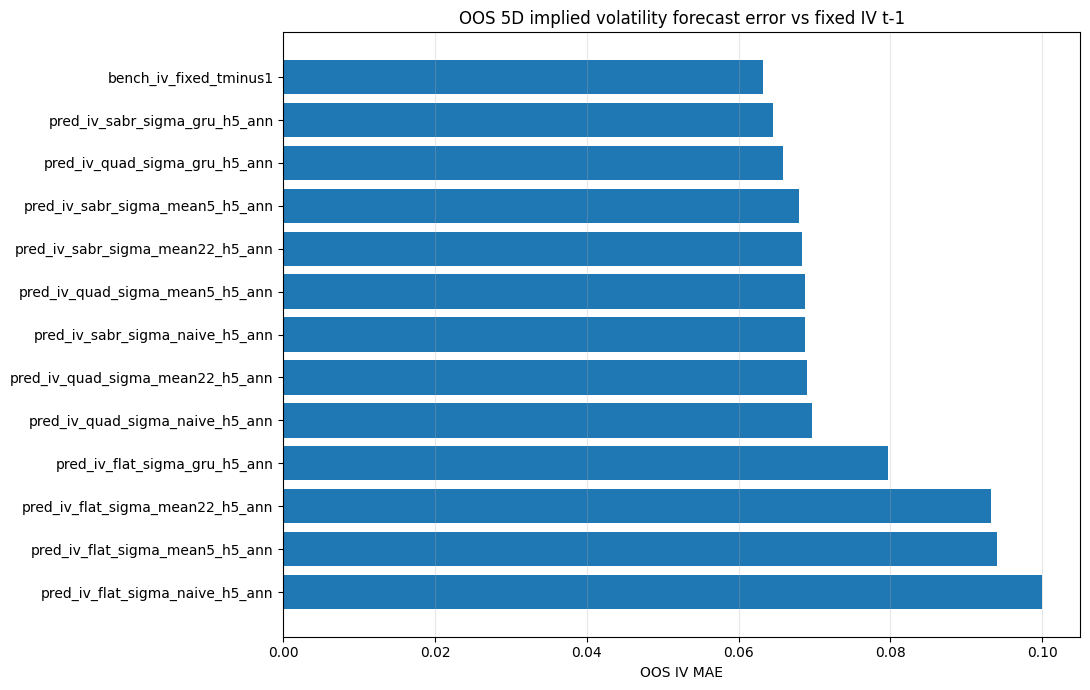

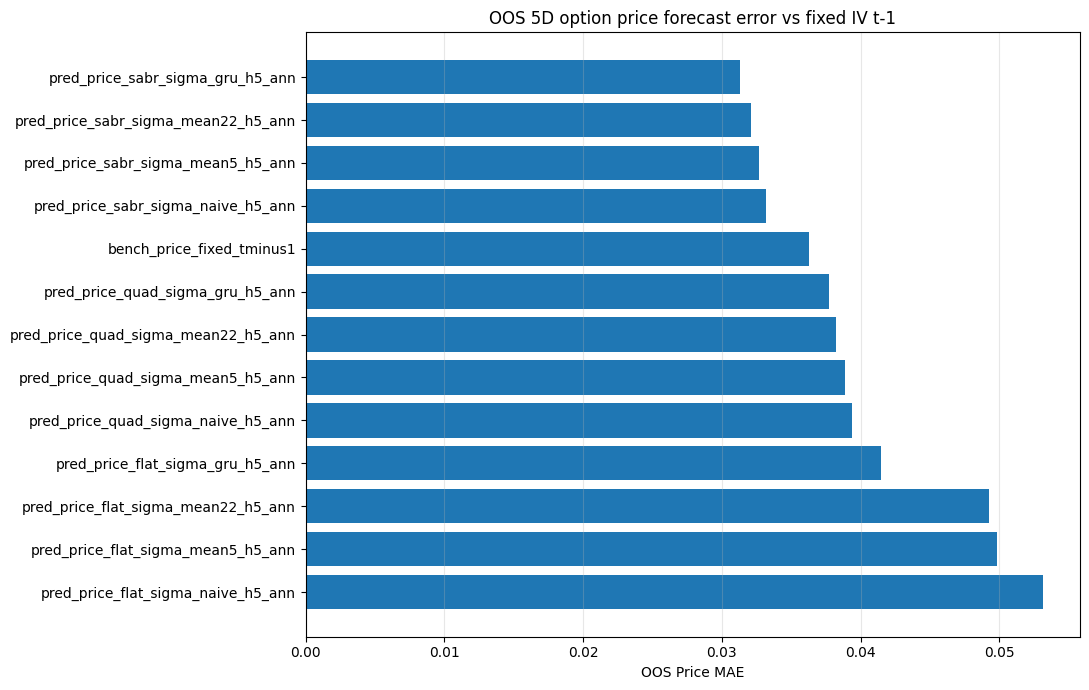

ValueError: cannot reindex on an axis with duplicate labels

In [6]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import brentq

try:
    from IPython.display import display
except Exception:
    display = print


DATE_COL = "trade_date"
EVAL_YEAR = 2025

RV_2025_COLS = [
    "sigma_gru_h5_ann",
    "sigma_naive_h5_ann",
    "sigma_mean5_h5_ann",
    "sigma_mean22_h5_ann",
]

HORIZON_TRADING_DAYS = 5

TRAIN_MONTHS = 5
VALIDATION_MONTHS = 2

TRADING_DAYS = 252
RV_HORIZON_DAYS = 5
RV_ANCHOR_LAMBDA = 0.70


PRICE_STATE_MODE = "future_realized_state"

SABR_BETA = 1.0

IV_MIN = 0.01
IV_MAX = 3.00
SIGMA_MIN = 0.001
SIGMA_MAX = 3.00
PRICE_EPS = 1e-8
EPS = 1e-12

REBUILD_SAFE_LAG_SMILE = True
MIN_OBS_PER_DAILY_SMILE = 5

USE_CONSTANT_SAFE_SABR_RHO_NU = True
SAFE_SABR_RHO = 0.0
SAFE_SABR_NU = 0.50

RESULTS_PATH_IF_NO_OOS = resolve_input_path("trained_rv_to_iv_gk_european_cnyp_oos_2025_results.csv")
OUT_DIR = default_output_dir()


if "oos" not in globals():
    if os.path.exists(RESULTS_PATH_IF_NO_OOS):
        oos = pd.read_csv(RESULTS_PATH_IF_NO_OOS)
        print("Loaded oos from:", RESULTS_PATH_IF_NO_OOS)
    else:
        raise ValueError("No `oos` dataframe found. Run the main volatility/pricing cell first.")

df = oos.copy()

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

if "expiration_date" in df.columns:
    df["expiration_date"] = pd.to_datetime(df["expiration_date"], errors="coerce")

num_cols = [
    "strike", "T_days", "T_model", "rd", "rf",
    "spot_for_pricing", "forward_for_pricing",
    "moneyness", "market_price", "iv",
    "lag_quad_a", "lag_quad_b", "lag_quad_c",
    "lag_sabr_rho", "lag_sabr_nu",
] + RV_2025_COLS

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "forward_for_pricing" not in df.columns or df["forward_for_pricing"].isna().all():
    df["forward_for_pricing"] = (
        df["spot_for_pricing"] * np.exp((df["rd"] - df["rf"]) * df["T_model"])
    )

if "moneyness" not in df.columns or df["moneyness"].isna().all():
    df["moneyness"] = np.log(df["strike"] / df["forward_for_pricing"])

if "T_days" not in df.columns or df["T_days"].isna().all():
    df["T_days"] = df["T_model"] * 365.0

need_cols = [
    DATE_COL,
    "market_price",
    "iv",
    "spot_for_pricing",
    "strike",
    "T_model",
    "rd",
    "rf",
    "option_type",
]

missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[
    df[DATE_COL].notna()
    & np.isfinite(df["market_price"]) & (df["market_price"] > 0)
    & np.isfinite(df["iv"]) & (df["iv"] > IV_MIN) & (df["iv"] < IV_MAX)
    & np.isfinite(df["spot_for_pricing"]) & (df["spot_for_pricing"] > 0)
    & np.isfinite(df["strike"]) & (df["strike"] > 0)
    & np.isfinite(df["T_model"]) & (df["T_model"] > 0)
    & np.isfinite(df["rd"])
    & np.isfinite(df["rf"])
].copy()

rv_cols_existing = [c for c in RV_2025_COLS if c in df.columns]

if len(rv_cols_existing) == 0:
    raise ValueError(f"No sigma columns found. Expected: {RV_2025_COLS}")

print("Initial rows:", len(df))
print("Date range:", df[DATE_COL].min(), "->", df[DATE_COL].max())
print("Sigma columns:", rv_cols_existing)


def normalize_cp(cp):
    s = pd.Series(cp).astype(str).str.upper().str.strip()
    return np.where(
        s.str.startswith("C"),
        "C",
        np.where(s.str.startswith("P"), "P", s),
    )


def choose_contract_keys(df_in):
    candidate_sets = [
        ["option_id"],
        ["instrument_id"],
        ["security_id"],
        ["secid"],
        ["ticker"],
        ["option_code"],
        ["expiration_date", "strike", "option_type"],
    ]

    for keys in candidate_sets:
        if all(k in df_in.columns for k in keys):
            return keys

    raise ValueError(
        "Could not infer contract keys. Need one of: option_id / instrument_id / "
        "security_id / secid / ticker / option_code, or expiration_date+strike+option_type."
    )


CONTRACT_KEYS = choose_contract_keys(df)
print("Contract keys used:", CONTRACT_KEYS)


def add_trade_date_ranks(df_in):
    out = df_in.copy()

    unique_dates = (
        pd.Series(out[DATE_COL].dropna().unique())
        .sort_values()
        .reset_index(drop=True)
    )

    date_rank = pd.DataFrame({
        DATE_COL: unique_dates,
        "trade_date_rank": np.arange(len(unique_dates)),
    })

    out = out.merge(date_rank, on=DATE_COL, how="left")

    rank_to_date = dict(zip(date_rank["trade_date_rank"], date_rank[DATE_COL]))

    out["prev_trade_date"] = out["trade_date_rank"].map(lambda x: rank_to_date.get(x - 1, pd.NaT))
    out["target_trade_date_h5"] = out["trade_date_rank"].map(
        lambda x: rank_to_date.get(x + HORIZON_TRADING_DAYS, pd.NaT)
    )

    return out


df = add_trade_date_ranks(df)


def fit_daily_quadratic_smile(g):
    gg = g[["moneyness", "iv"]].replace([np.inf, -np.inf], np.nan).dropna()
    gg = gg[(gg["iv"] > IV_MIN) & (gg["iv"] < IV_MAX)]

    if len(gg) == 0:
        return pd.Series({
            "cur_quad_a": np.nan,
            "cur_quad_b": np.nan,
            "cur_quad_c": np.nan,
            "cur_smile_n": 0,
        })

    m = gg["moneyness"].astype(float).values
    y = gg["iv"].astype(float).values

    if len(gg) >= MIN_OBS_PER_DAILY_SMILE and np.nanstd(m) > 1e-8:
        try:
            c2, c1, c0 = np.polyfit(m, y, deg=2)
            a, b, c = c0, c1, c2
        except Exception:
            a, b, c = np.nanmedian(y), 0.0, 0.0
    else:
        a, b, c = np.nanmedian(y), 0.0, 0.0

    return pd.Series({
        "cur_quad_a": float(np.clip(a, IV_MIN, IV_MAX)),
        "cur_quad_b": float(b),
        "cur_quad_c": float(c),
        "cur_smile_n": int(len(gg)),
    })


def add_safe_lagged_smile(df_in):
    out = df_in.copy().sort_values(DATE_COL).reset_index(drop=True)

    if not REBUILD_SAFE_LAG_SMILE:
        print("WARNING: using existing lag_quad_* columns. Make sure they are truly lagged.")

        if USE_CONSTANT_SAFE_SABR_RHO_NU:
            out["lag_sabr_rho"] = SAFE_SABR_RHO
            out["lag_sabr_nu"] = SAFE_SABR_NU

        return out

    daily = (
        out.groupby(DATE_COL, sort=True)
        .apply(fit_daily_quadratic_smile)
        .reset_index()
        .sort_values(DATE_COL)
        .reset_index(drop=True)
    )

    daily[["cur_quad_a", "cur_quad_b", "cur_quad_c"]] = (
        daily[["cur_quad_a", "cur_quad_b", "cur_quad_c"]].ffill()
    )

    daily["safe_lag_quad_a"] = daily["cur_quad_a"].shift(1)
    daily["safe_lag_quad_b"] = daily["cur_quad_b"].shift(1)
    daily["safe_lag_quad_c"] = daily["cur_quad_c"].shift(1)
    daily["safe_lag_smile_source_date"] = daily[DATE_COL].shift(1)
    daily["safe_lag_smile_n"] = daily["cur_smile_n"].shift(1)

    safe = daily[[
        DATE_COL,
        "safe_lag_quad_a",
        "safe_lag_quad_b",
        "safe_lag_quad_c",
        "safe_lag_smile_source_date",
        "safe_lag_smile_n",
    ]]

    out = out.merge(safe, on=DATE_COL, how="left")

    out["lag_quad_a"] = out["safe_lag_quad_a"]
    out["lag_quad_b"] = out["safe_lag_quad_b"]
    out["lag_quad_c"] = out["safe_lag_quad_c"]

    if USE_CONSTANT_SAFE_SABR_RHO_NU:
        out["lag_sabr_rho"] = SAFE_SABR_RHO
        out["lag_sabr_nu"] = SAFE_SABR_NU
    else:
        out["lag_sabr_rho"] = pd.to_numeric(out["lag_sabr_rho"], errors="coerce").fillna(SAFE_SABR_RHO)
        out["lag_sabr_nu"] = pd.to_numeric(out["lag_sabr_nu"], errors="coerce").fillna(SAFE_SABR_NU)

    before = len(out)

    out = out[
        np.isfinite(out["lag_quad_a"])
        & np.isfinite(out["lag_quad_b"])
        & np.isfinite(out["lag_quad_c"])
        & (pd.to_datetime(out["safe_lag_smile_source_date"]) < pd.to_datetime(out[DATE_COL]))
    ].copy()

    print("\n================ SAFE LAGGED SMILE ================")
    print("Rows before safe-lag drop:", before)
    print("Rows after safe-lag drop:", len(out))
    print("First usable signal date:", out[DATE_COL].min())

    return out.reset_index(drop=True)


df_signal = add_safe_lagged_smile(df)


def add_contract_lag_iv(df_in):
    out = df_in.copy()

    lag_src = (
        out[CONTRACT_KEYS + [DATE_COL, "iv"]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[DATE_COL, "iv"])
        .groupby(CONTRACT_KEYS + [DATE_COL], as_index=False)["iv"]
        .median()
        .rename(columns={
            DATE_COL: "prev_trade_date",
            "iv": "iv_fixed_tminus1_contract",
        })
    )

    out = out.merge(
        lag_src,
        on=CONTRACT_KEYS + ["prev_trade_date"],
        how="left",
    )

    return out


df_signal = add_contract_lag_iv(df_signal)


def add_horizon_targets(df_in):
    out = df_in.copy()

    target_cols = [
        "market_price",
        "iv",
        "spot_for_pricing",
        "forward_for_pricing",
        "T_model",
        "T_days",
        "rd",
        "rf",
        "moneyness",
    ]

    target_cols = [c for c in target_cols if c in out.columns]

    future = (
        out[CONTRACT_KEYS + [DATE_COL] + target_cols]
        .copy()
        .rename(columns={DATE_COL: "target_trade_date_h5"})
    )

    rename_map = {c: f"target_{c}_h5" for c in target_cols}
    future = future.rename(columns=rename_map)


    group_cols = CONTRACT_KEYS + ["target_trade_date_h5"]

    num_future_cols = [c for c in future.columns if c not in group_cols]
    future = (
        future
        .groupby(group_cols, as_index=False)[num_future_cols]
        .median()
    )

    out = out.merge(
        future,
        on=CONTRACT_KEYS + ["target_trade_date_h5"],
        how="left",
    )

    return out


df_eval = add_horizon_targets(df_signal)

before_target_drop = len(df_eval)

df_eval = df_eval[
    df_eval["target_trade_date_h5"].notna()
    & np.isfinite(df_eval["target_market_price_h5"]) & (df_eval["target_market_price_h5"] > 0)
    & np.isfinite(df_eval["target_iv_h5"]) & (df_eval["target_iv_h5"] > IV_MIN) & (df_eval["target_iv_h5"] < IV_MAX)
].copy()

print("\n================ 5D TARGET ALIGNMENT ================")
print("Rows before target drop:", before_target_drop)
print("Rows after target drop:", len(df_eval))
print("Signal date range:", df_eval[DATE_COL].min(), "->", df_eval[DATE_COL].max())
print("Target date range:", df_eval["target_trade_date_h5"].min(), "->", df_eval["target_trade_date_h5"].max())


def sabr_lognormal_vol(F, K, T, alpha, beta, rho, nu):
    F, K, T, alpha, rho, nu = np.broadcast_arrays(
        np.asarray(F, dtype=float),
        np.asarray(K, dtype=float),
        np.asarray(T, dtype=float),
        np.asarray(alpha, dtype=float),
        np.asarray(rho, dtype=float),
        np.asarray(nu, dtype=float),
    )

    beta = float(beta)

    F = np.maximum(F, EPS)
    K = np.maximum(K, EPS)
    T = np.maximum(T, EPS)
    alpha = np.maximum(alpha, EPS)
    nu = np.maximum(nu, EPS)
    rho = np.clip(rho, -0.999, 0.999)

    one_minus_beta = 1.0 - beta
    logFK = np.log(F / K)

    FK_beta = (F * K) ** (one_minus_beta / 2.0)

    denom = FK_beta * (
        1.0
        + (one_minus_beta ** 2 / 24.0) * logFK ** 2
        + (one_minus_beta ** 4 / 1920.0) * logFK ** 4
    )

    z = (nu / alpha) * FK_beta * logFK

    sqrt_term = np.sqrt(np.maximum(1.0 - 2.0 * rho * z + z ** 2, EPS))

    x_z = np.log(
        np.maximum(
            (sqrt_term + z - rho) / np.maximum(1.0 - rho, EPS),
            EPS,
        )
    )

    x_z_safe = np.where(np.abs(x_z) < EPS, EPS, x_z)
    z_over_xz = np.where(np.abs(z) < 1e-8, 1.0, z / x_z_safe)

    correction = 1.0 + (
        (one_minus_beta ** 2 / 24.0) * (alpha ** 2 / np.maximum(FK_beta ** 2, EPS))
        + (rho * beta * nu * alpha) / np.maximum(4.0 * FK_beta, EPS)
        + ((2.0 - 3.0 * rho ** 2) * nu ** 2) / 24.0
    ) * T

    vol = (alpha / np.maximum(denom, EPS)) * z_over_xz * correction

    atm = np.abs(logFK) < 1e-8

    if np.any(atm):
        F_atm = F[atm]
        T_atm = T[atm]
        alpha_atm = alpha[atm]
        rho_atm = rho[atm]
        nu_atm = nu[atm]

        vol_atm = alpha_atm / np.maximum(F_atm ** (1.0 - beta), EPS) * (
            1.0 + (
                ((1.0 - beta) ** 2 / 24.0)
                * alpha_atm ** 2
                / np.maximum(F_atm ** (2.0 - 2.0 * beta), EPS)
                + rho_atm * beta * nu_atm * alpha_atm / np.maximum(4.0 * F_atm ** (1.0 - beta), EPS)
                + ((2.0 - 3.0 * rho_atm ** 2) * nu_atm ** 2 / 24.0)
            ) * T_atm
        )

        vol[atm] = vol_atm

    vol = np.asarray(vol, dtype=float)
    vol[~np.isfinite(vol)] = np.nan

    return vol


def gk_price_scalar(S, K, T, rd, rf, sigma, cp):
    if not np.all(np.isfinite([S, K, T, rd, rf, sigma])):
        return np.nan

    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan

    cp = str(cp).upper().strip()
    cp = "C" if cp.startswith("C") else "P"

    vol_sqrt = sigma * np.sqrt(T)

    if vol_sqrt <= 0:
        return np.nan

    d1 = (np.log(S / K) + (rd - rf + 0.5 * sigma ** 2) * T) / vol_sqrt
    d2 = d1 - vol_sqrt

    if cp == "C":
        return S * np.exp(-rf * T) * norm.cdf(d1) - K * np.exp(-rd * T) * norm.cdf(d2)

    return K * np.exp(-rd * T) * norm.cdf(-d2) - S * np.exp(-rf * T) * norm.cdf(-d1)


def gk_price_vec(S, K, T, rd, rf, sigma, cp):
    S = pd.to_numeric(S, errors="coerce").astype(float).values
    K = pd.to_numeric(K, errors="coerce").astype(float).values
    T = pd.to_numeric(T, errors="coerce").astype(float).values
    rd = pd.to_numeric(rd, errors="coerce").astype(float).values
    rf = pd.to_numeric(rf, errors="coerce").astype(float).values
    sigma = pd.to_numeric(sigma, errors="coerce").astype(float).values
    cp = normalize_cp(cp)

    out = np.full(len(S), np.nan)

    ok = (
        np.isfinite(S)
        & np.isfinite(K)
        & np.isfinite(T)
        & np.isfinite(rd)
        & np.isfinite(rf)
        & np.isfinite(sigma)
        & (S > 0)
        & (K > 0)
        & (T > 0)
        & (sigma > 0)
    )

    if ok.sum() == 0:
        return pd.Series(out)

    S0, K0, T0 = S[ok], K[ok], T[ok]
    rd0, rf0, sig0 = rd[ok], rf[ok], sigma[ok]
    cp0 = cp[ok]

    vol_sqrt = sig0 * np.sqrt(T0)

    d1 = (np.log(S0 / K0) + (rd0 - rf0 + 0.5 * sig0 ** 2) * T0) / vol_sqrt
    d2 = d1 - vol_sqrt

    call = S0 * np.exp(-rf0 * T0) * norm.cdf(d1) - K0 * np.exp(-rd0 * T0) * norm.cdf(d2)
    put = K0 * np.exp(-rd0 * T0) * norm.cdf(-d2) - S0 * np.exp(-rf0 * T0) * norm.cdf(-d1)

    out[ok] = np.where(cp0 == "C", call, put)

    return pd.Series(out)


def gk_iv_single(price, S, K, T, rd, rf, cp, lo=IV_MIN, hi=IV_MAX):
    if not np.all(np.isfinite([price, S, K, T, rd, rf])):
        return np.nan

    if price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return np.nan

    p_lo = gk_price_scalar(S, K, T, rd, rf, lo, cp)
    p_hi = gk_price_scalar(S, K, T, rd, rf, hi, cp)

    if not np.isfinite(p_lo) or not np.isfinite(p_hi):
        return np.nan


    if price <= p_lo:
        return lo
    if price >= p_hi:
        return hi

    try:
        return brentq(
            lambda sig: gk_price_scalar(S, K, T, rd, rf, sig, cp) - price,
            lo,
            hi,
            maxiter=100,
        )
    except Exception:
        return np.nan


def gk_iv_vec(price, S, K, T, rd, rf, cp):
    price = pd.to_numeric(price, errors="coerce").astype(float).values
    S = pd.to_numeric(S, errors="coerce").astype(float).values
    K = pd.to_numeric(K, errors="coerce").astype(float).values
    T = pd.to_numeric(T, errors="coerce").astype(float).values
    rd = pd.to_numeric(rd, errors="coerce").astype(float).values
    rf = pd.to_numeric(rf, errors="coerce").astype(float).values
    cp = normalize_cp(cp)

    out = np.full(len(price), np.nan)

    for i in range(len(price)):
        out[i] = gk_iv_single(price[i], S[i], K[i], T[i], rd[i], rf[i], cp[i])

    return pd.Series(out)


def gk_bounds_state(df_in):
    S = pd.to_numeric(df_in["pricing_spot"], errors="coerce").astype(float)
    K = pd.to_numeric(df_in["strike"], errors="coerce").astype(float)
    T = pd.to_numeric(df_in["pricing_T"], errors="coerce").astype(float)
    rd = pd.to_numeric(df_in["pricing_rd"], errors="coerce").astype(float)
    rf = pd.to_numeric(df_in["pricing_rf"], errors="coerce").astype(float)
    cp = normalize_cp(df_in["option_type"])

    disc_S = S * np.exp(-rf * T)
    disc_K = K * np.exp(-rd * T)

    lower = np.where(
        cp == "C",
        np.maximum(disc_S - disc_K, 0.0),
        np.maximum(disc_K - disc_S, 0.0),
    )

    upper = np.where(cp == "C", disc_S, disc_K)

    return pd.Series(lower, index=df_in.index), pd.Series(upper, index=df_in.index)


def add_pricing_state(df_in, mode=PRICE_STATE_MODE):
    out = df_in.copy()

    if mode == "future_realized_state":
        out["pricing_spot"] = pd.to_numeric(out["target_spot_for_pricing_h5"], errors="coerce")
        out["pricing_T"] = pd.to_numeric(out["target_T_model_h5"], errors="coerce")
        out["pricing_rd"] = pd.to_numeric(out["target_rd_h5"], errors="coerce")
        out["pricing_rf"] = pd.to_numeric(out["target_rf_h5"], errors="coerce")

        if "target_forward_for_pricing_h5" in out.columns:
            out["pricing_forward"] = pd.to_numeric(out["target_forward_for_pricing_h5"], errors="coerce")
        else:
            out["pricing_forward"] = np.nan

    elif mode == "current_state":
        out["pricing_spot"] = pd.to_numeric(out["spot_for_pricing"], errors="coerce")
        out["pricing_T"] = pd.to_numeric(out["T_model"], errors="coerce")
        out["pricing_rd"] = pd.to_numeric(out["rd"], errors="coerce")
        out["pricing_rf"] = pd.to_numeric(out["rf"], errors="coerce")
        out["pricing_forward"] = pd.to_numeric(out["forward_for_pricing"], errors="coerce")

    else:
        raise ValueError("PRICE_STATE_MODE must be 'future_realized_state' or 'current_state'.")

    bad_forward = (
        ~np.isfinite(out["pricing_forward"])
        | (out["pricing_forward"] <= 0)
    )

    out.loc[bad_forward, "pricing_forward"] = (
        out.loc[bad_forward, "pricing_spot"]
        * np.exp(
            (out.loc[bad_forward, "pricing_rd"] - out.loc[bad_forward, "pricing_rf"])
            * out.loc[bad_forward, "pricing_T"]
        )
    )

    out["pricing_moneyness"] = np.log(out["strike"] / out["pricing_forward"])

    out = out[
        np.isfinite(out["pricing_spot"]) & (out["pricing_spot"] > 0)
        & np.isfinite(out["pricing_forward"]) & (out["pricing_forward"] > 0)
        & np.isfinite(out["pricing_T"]) & (out["pricing_T"] > 0)
        & np.isfinite(out["pricing_rd"])
        & np.isfinite(out["pricing_rf"])
        & np.isfinite(out["pricing_moneyness"])
    ].copy()

    lower, upper = gk_bounds_state(out)

    out["price_lower_bound"] = lower
    out["price_upper_bound"] = upper

    return out


def clip_price_to_bounds(df_in, price_col):
    out = df_in.copy()

    out[price_col] = pd.to_numeric(out[price_col], errors="coerce").clip(lower=0.0)

    out[price_col] = np.maximum(
        out[price_col],
        pd.to_numeric(out["price_lower_bound"], errors="coerce").fillna(0.0),
    )

    upper = pd.to_numeric(out["price_upper_bound"], errors="coerce")
    upper_ok = np.isfinite(upper)

    out.loc[upper_ok, price_col] = np.minimum(
        out.loc[upper_ok, price_col],
        upper.loc[upper_ok],
    )

    return out


def add_fixed_iv_tminus1_benchmark(df_in):
    out = df_in.copy()

    m = pd.to_numeric(out["pricing_moneyness"], errors="coerce").astype(float)

    lag_a = pd.to_numeric(out["lag_quad_a"], errors="coerce").astype(float)
    lag_b = pd.to_numeric(out["lag_quad_b"], errors="coerce").fillna(0.0).astype(float)
    lag_c = pd.to_numeric(out["lag_quad_c"], errors="coerce").fillna(0.0).astype(float)

    out["bench_iv_fixed_tminus1_smile"] = (
        lag_a + lag_b * m + lag_c * m ** 2
    ).clip(IV_MIN, IV_MAX)

    out["bench_iv_fixed_tminus1_contract"] = pd.to_numeric(
        out.get("iv_fixed_tminus1_contract", np.nan),
        errors="coerce",
    )


    out["bench_iv_fixed_tminus1"] = (
        out["bench_iv_fixed_tminus1_contract"]
        .where(
            np.isfinite(out["bench_iv_fixed_tminus1_contract"])
            & (out["bench_iv_fixed_tminus1_contract"] > IV_MIN)
            & (out["bench_iv_fixed_tminus1_contract"] < IV_MAX),
            out["bench_iv_fixed_tminus1_smile"],
        )
        .clip(IV_MIN, IV_MAX)
    )

    out["bench_price_fixed_tminus1"] = gk_price_vec(
        out["pricing_spot"],
        out["strike"],
        out["pricing_T"],
        out["pricing_rd"],
        out["pricing_rf"],
        out["bench_iv_fixed_tminus1"],
        out["option_type"],
    ).values

    out = clip_price_to_bounds(out, "bench_price_fixed_tminus1")

    return out


def compute_forecasts_for_sigma(df_in, sigma_col):
    out = df_in.copy()

    sig = pd.to_numeric(out[sigma_col], errors="coerce").astype(float).clip(SIGMA_MIN, SIGMA_MAX)

    T = pd.to_numeric(out["pricing_T"], errors="coerce").astype(float).clip(lower=EPS)

    lag_atm_iv = pd.to_numeric(out["lag_quad_a"], errors="coerce").astype(float).clip(IV_MIN, IV_MAX)
    lag_atm_var = lag_atm_iv ** 2

    ann_var_rv = sig ** 2

    H = RV_HORIZON_DAYS / TRADING_DAYS

    short_part = np.minimum(T, H)
    long_part = np.maximum(T - H, 0.0)

    rv_term_var = (short_part * ann_var_rv + long_part * lag_atm_var) / T

    anchored_atm_var = (
        RV_ANCHOR_LAMBDA * rv_term_var
        + (1.0 - RV_ANCHOR_LAMBDA) * lag_atm_var
    )

    anchored_atm_iv = np.sqrt(anchored_atm_var).clip(IV_MIN, IV_MAX)

    m = pd.to_numeric(out["pricing_moneyness"], errors="coerce").astype(float)

    lag_b = pd.to_numeric(out["lag_quad_b"], errors="coerce").fillna(0.0).astype(float)
    lag_c = pd.to_numeric(out["lag_quad_c"], errors="coerce").fillna(0.0).astype(float)

    iv_flat = sig.clip(IV_MIN, IV_MAX)

    iv_quad = (
        anchored_atm_iv
        + lag_b * m
        + lag_c * m ** 2
    ).clip(IV_MIN, IV_MAX)

    F = pd.to_numeric(out["pricing_forward"], errors="coerce").astype(float).clip(lower=EPS)
    K = pd.to_numeric(out["strike"], errors="coerce").astype(float).clip(lower=EPS)

    rho = pd.to_numeric(out["lag_sabr_rho"], errors="coerce").fillna(SAFE_SABR_RHO).astype(float)
    nu = pd.to_numeric(out["lag_sabr_nu"], errors="coerce").fillna(SAFE_SABR_NU).astype(float)

    sabr_alpha_anchor = (
        anchored_atm_iv * (F ** (1.0 - SABR_BETA))
    ).clip(1e-4, 5.0)

    iv_sabr = sabr_lognormal_vol(
        F.values,
        K.values,
        T.values,
        sabr_alpha_anchor.values,
        SABR_BETA,
        rho.values,
        nu.values,
    )

    iv_sabr = pd.Series(iv_sabr, index=out.index).replace([np.inf, -np.inf], np.nan)

    bad_sabr = iv_sabr.isna() | (iv_sabr < IV_MIN) | (iv_sabr > IV_MAX)
    iv_sabr.loc[bad_sabr] = iv_quad.loc[bad_sabr]
    iv_sabr = iv_sabr.clip(IV_MIN, IV_MAX)

    prefix = sigma_col

    out[f"pred_iv_flat_{prefix}"] = iv_flat.values
    out[f"pred_iv_quad_{prefix}"] = iv_quad.values
    out[f"pred_iv_sabr_{prefix}"] = iv_sabr.values
    out[f"pred_atm_iv_anchor_{prefix}"] = anchored_atm_iv.values

    for kind in ["flat", "quad", "sabr"]:
        iv_col = f"pred_iv_{kind}_{prefix}"
        price_col = f"pred_price_{kind}_{prefix}"

        out[price_col] = gk_price_vec(
            out["pricing_spot"],
            out["strike"],
            out["pricing_T"],
            out["pricing_rd"],
            out["pricing_rf"],
            out[iv_col],
            out["option_type"],
        ).values

        out = clip_price_to_bounds(out, price_col)

    return out


def calc_metrics(df_in, pred_col, target_col, label=None):
    d = (
        df_in[[pred_col, target_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    d = d[np.isfinite(d[pred_col]) & np.isfinite(d[target_col])]

    if len(d) == 0:
        return {
            "model": label or pred_col,
            "target": target_col,
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "MedianAE": np.nan,
            "WMAPE_pct": np.nan,
        }

    err = d[pred_col] - d[target_col]

    return {
        "model": label or pred_col,
        "target": target_col,
        "n": int(len(d)),
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "Bias": float(np.mean(err)),
        "MedianAE": float(np.median(np.abs(err))),
        "WMAPE_pct": float(100.0 * np.sum(np.abs(err)) / max(np.sum(np.abs(d[target_col])), EPS)),
    }


def make_improvement_table(metrics_df, benchmark_model):
    rows = []

    base = metrics_df[metrics_df["model"] == benchmark_model]

    if len(base) == 0:
        return pd.DataFrame()

    base = base.iloc[0].to_dict()

    for _, r in metrics_df.iterrows():
        if r["model"] == benchmark_model:
            continue

        rows.append({
            "benchmark": benchmark_model,
            "model": r["model"],
            "target": r["target"],
            "benchmark_MAE": base["MAE"],
            "model_MAE": r["MAE"],
            "MAE_improvement_vs_benchmark_%": 100.0 * (base["MAE"] - r["MAE"]) / max(base["MAE"], EPS),
            "benchmark_RMSE": base["RMSE"],
            "model_RMSE": r["RMSE"],
            "RMSE_improvement_vs_benchmark_%": 100.0 * (base["RMSE"] - r["RMSE"]) / max(base["RMSE"], EPS),
            "benchmark_WMAPE_pct": base["WMAPE_pct"],
            "model_WMAPE_pct": r["WMAPE_pct"],
            "WMAPE_improvement_vs_benchmark_%": 100.0 * (base["WMAPE_pct"] - r["WMAPE_pct"]) / max(base["WMAPE_pct"], EPS),
            "benchmark_Bias": base["Bias"],
            "model_Bias": r["Bias"],
        })

    return pd.DataFrame(rows)


year_start = pd.Timestamp(f"{EVAL_YEAR}-01-01")
year_end = pd.Timestamp(f"{EVAL_YEAR + 1}-01-01")

train_start = year_start
valid_start = year_start + pd.DateOffset(months=TRAIN_MONTHS)
oos_start = valid_start + pd.DateOffset(months=VALIDATION_MONTHS)

df_eval = df_eval[
    (df_eval["target_trade_date_h5"] >= year_start)
    & (df_eval["target_trade_date_h5"] < year_end)
].copy()

train_base = df_eval[
    (df_eval["target_trade_date_h5"] >= train_start)
    & (df_eval["target_trade_date_h5"] < valid_start)
].copy()

valid_base = df_eval[
    (df_eval["target_trade_date_h5"] >= valid_start)
    & (df_eval["target_trade_date_h5"] < oos_start)
].copy()

oos_base = df_eval[
    (df_eval["target_trade_date_h5"] >= oos_start)
    & (df_eval["target_trade_date_h5"] < year_end)
].copy()

print("\n================ TARGET-DATE SPLIT ================")
print("Train target dates:", train_base["target_trade_date_h5"].min(), "->", train_base["target_trade_date_h5"].max(), "| rows:", len(train_base))
print("Validation target dates:", valid_base["target_trade_date_h5"].min(), "->", valid_base["target_trade_date_h5"].max(), "| rows:", len(valid_base))
print("OOS target dates:", oos_base["target_trade_date_h5"].min(), "->", oos_base["target_trade_date_h5"].max(), "| rows:", len(oos_base))
print("PRICE_STATE_MODE:", PRICE_STATE_MODE)

if len(oos_base) == 0:
    raise ValueError("OOS period is empty after 5D target alignment.")


oos_result = add_pricing_state(oos_base.copy(), mode=PRICE_STATE_MODE)
oos_result = add_fixed_iv_tminus1_benchmark(oos_result)

iv_forecast_cols = ["bench_iv_fixed_tminus1"]
price_forecast_cols = ["bench_price_fixed_tminus1"]

for sig_col in rv_cols_existing:
    print(f"Computing forecasts for: {sig_col}")

    before = len(oos_result)

    oos_result = compute_forecasts_for_sigma(oos_result, sig_col)

    after = len(oos_result)

    if after != before:
        print(f"Rows changed during forecast computation for {sig_col}: {before} -> {after}")

    iv_forecast_cols.extend([
        f"pred_iv_flat_{sig_col}",
        f"pred_iv_quad_{sig_col}",
        f"pred_iv_sabr_{sig_col}",
    ])

    price_forecast_cols.extend([
        f"pred_price_flat_{sig_col}",
        f"pred_price_quad_{sig_col}",
        f"pred_price_sabr_{sig_col}",
    ])

iv_forecast_cols = list(dict.fromkeys(iv_forecast_cols))
price_forecast_cols = list(dict.fromkeys(price_forecast_cols))


iv_metrics = pd.DataFrame([
    calc_metrics(
        oos_result,
        pred_col=c,
        target_col="target_iv_h5",
        label=c,
    )
    for c in iv_forecast_cols
]).sort_values(["MAE", "RMSE"]).reset_index(drop=True)

price_metrics = pd.DataFrame([
    calc_metrics(
        oos_result,
        pred_col=c,
        target_col="target_market_price_h5",
        label=c,
    )
    for c in price_forecast_cols
]).sort_values(["MAE", "RMSE"]).reset_index(drop=True)

print("\n================ FINAL OOS IV METRICS ================")
display(iv_metrics)

print("\n================ FINAL OOS PRICE METRICS ================")
display(price_metrics)

iv_improvement = make_improvement_table(iv_metrics, "bench_iv_fixed_tminus1")
price_improvement = make_improvement_table(price_metrics, "bench_price_fixed_tminus1")

print("\n================ IV IMPROVEMENT VS FIXED IV t-1 ================")
display(iv_improvement.sort_values("MAE_improvement_vs_benchmark_%", ascending=False).round(6))

print("\n================ PRICE IMPROVEMENT VS FIXED IV t-1 ================")
display(price_improvement.sort_values("MAE_improvement_vs_benchmark_%", ascending=False).round(6))


type_iv_rows = []
type_price_rows = []

for opt_type, g in oos_result.groupby("option_type", dropna=False):
    for c in iv_forecast_cols:
        m = calc_metrics(g, c, "target_iv_h5", label=c)
        m["option_type"] = str(opt_type)
        type_iv_rows.append(m)

    for c in price_forecast_cols:
        m = calc_metrics(g, c, "target_market_price_h5", label=c)
        m["option_type"] = str(opt_type)
        type_price_rows.append(m)

oos_iv_by_type = pd.DataFrame(type_iv_rows).sort_values(["option_type", "MAE"])
oos_price_by_type = pd.DataFrame(type_price_rows).sort_values(["option_type", "MAE"])

print("\n================ OOS IV BY OPTION TYPE ================")
display(oos_iv_by_type.groupby("option_type").head(12))

print("\n================ OOS PRICE BY OPTION TYPE ================")
display(oos_price_by_type.groupby("option_type").head(12))


def expiration_bucket_short(t):
    if pd.isna(t):
        return np.nan
    if t <= 7:
        return "1 week (<=7d)"
    if t <= 14:
        return "2 weeks (8-14d)"
    if t <= 31:
        return "1 month (15-31d)"
    return "longer than 1 month"


if "target_T_days_h5" in oos_result.columns:
    oos_result["expiration_bucket_short"] = oos_result["target_T_days_h5"].apply(expiration_bucket_short)
else:
    oos_result["expiration_bucket_short"] = (oos_result["pricing_T"] * 365.0).apply(expiration_bucket_short)

exp_iv_rows = []
exp_price_rows = []

for bucket, g in oos_result.groupby("expiration_bucket_short", dropna=False):
    for c in iv_forecast_cols:
        m = calc_metrics(g, c, "target_iv_h5", label=c)
        m["expiration_bucket"] = str(bucket)
        exp_iv_rows.append(m)

    for c in price_forecast_cols:
        m = calc_metrics(g, c, "target_market_price_h5", label=c)
        m["expiration_bucket"] = str(bucket)
        exp_price_rows.append(m)

oos_iv_by_expiration = pd.DataFrame(exp_iv_rows).sort_values(["expiration_bucket", "MAE"])
oos_price_by_expiration = pd.DataFrame(exp_price_rows).sort_values(["expiration_bucket", "MAE"])

print("\n================ OOS IV BY EXPIRATION ================")
display(oos_iv_by_expiration.groupby("expiration_bucket").head(12))

print("\n================ OOS PRICE BY EXPIRATION ================")
display(oos_price_by_expiration.groupby("expiration_bucket").head(12))


latest_signal_date = df_signal[DATE_COL].max()

latest_forecasts = df_signal[df_signal[DATE_COL] == latest_signal_date].copy()

latest_forecasts = add_pricing_state(latest_forecasts, mode="current_state")
latest_forecasts = add_fixed_iv_tminus1_benchmark(latest_forecasts)

latest_iv_cols = ["bench_iv_fixed_tminus1"]
latest_price_cols = ["bench_price_fixed_tminus1"]

for sig_col in rv_cols_existing:
    latest_forecasts = compute_forecasts_for_sigma(latest_forecasts, sig_col)

    latest_iv_cols.extend([
        f"pred_iv_flat_{sig_col}",
        f"pred_iv_quad_{sig_col}",
        f"pred_iv_sabr_{sig_col}",
    ])

    latest_price_cols.extend([
        f"pred_price_flat_{sig_col}",
        f"pred_price_quad_{sig_col}",
        f"pred_price_sabr_{sig_col}",
    ])

latest_keep_cols = (
    CONTRACT_KEYS
    + [
        DATE_COL,
        "expiration_date" if "expiration_date" in latest_forecasts.columns else None,
        "strike",
        "option_type",
        "spot_for_pricing",
        "T_model",
        "T_days",
        "market_price",
        "iv",
        "bench_iv_fixed_tminus1",
        "bench_price_fixed_tminus1",
    ]
    + latest_iv_cols
    + latest_price_cols
)

latest_keep_cols = [c for c in latest_keep_cols if c is not None and c in latest_forecasts.columns]
latest_keep_cols = list(dict.fromkeys(latest_keep_cols))

latest_forecast_table = latest_forecasts[latest_keep_cols].copy()

print("\n================ LATEST SIGNAL-DATE FORECASTS ================")
print("Latest signal date:", latest_signal_date)
print("Rows:", len(latest_forecast_table))
display(latest_forecast_table.head(20))


out_oos_results = f"{OUT_DIR}/oos_5d_iv_price_forecasts_vs_fixed_iv_tminus1.csv"
out_iv_metrics = f"{OUT_DIR}/oos_5d_iv_metrics_vs_fixed_iv_tminus1.csv"
out_price_metrics = f"{OUT_DIR}/oos_5d_price_metrics_vs_fixed_iv_tminus1.csv"
out_iv_improvement = f"{OUT_DIR}/oos_5d_iv_improvement_vs_fixed_iv_tminus1.csv"
out_price_improvement = f"{OUT_DIR}/oos_5d_price_improvement_vs_fixed_iv_tminus1.csv"
out_iv_by_type = f"{OUT_DIR}/oos_5d_iv_metrics_by_type.csv"
out_price_by_type = f"{OUT_DIR}/oos_5d_price_metrics_by_type.csv"
out_iv_by_exp = f"{OUT_DIR}/oos_5d_iv_metrics_by_expiration.csv"
out_price_by_exp = f"{OUT_DIR}/oos_5d_price_metrics_by_expiration.csv"
out_latest_forecasts = f"{OUT_DIR}/latest_signal_date_5d_iv_price_forecasts.csv"

oos_result.to_csv(out_oos_results, index=False)
iv_metrics.to_csv(out_iv_metrics, index=False)
price_metrics.to_csv(out_price_metrics, index=False)
iv_improvement.to_csv(out_iv_improvement, index=False)
price_improvement.to_csv(out_price_improvement, index=False)
oos_iv_by_type.to_csv(out_iv_by_type, index=False)
oos_price_by_type.to_csv(out_price_by_type, index=False)
oos_iv_by_expiration.to_csv(out_iv_by_exp, index=False)
oos_price_by_expiration.to_csv(out_price_by_exp, index=False)
latest_forecast_table.to_csv(out_latest_forecasts, index=False)

print("\nSaved:")
print(out_oos_results)
print(out_iv_metrics)
print(out_price_metrics)
print(out_iv_improvement)
print(out_price_improvement)
print(out_iv_by_type)
print(out_price_by_type)
print(out_iv_by_exp)
print(out_price_by_exp)
print(out_latest_forecasts)


plot_iv = iv_metrics.copy().sort_values("MAE").head(20)

plt.figure(figsize=(11, 7))
plt.barh(plot_iv["model"][::-1], plot_iv["MAE"][::-1])
plt.xlabel("OOS IV MAE")
plt.title("OOS 5D implied volatility forecast error vs fixed IV t-1")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plot_price = price_metrics.copy().sort_values("MAE").head(20)

plt.figure(figsize=(11, 7))
plt.barh(plot_price["model"][::-1], plot_price["MAE"][::-1])
plt.xlabel("OOS Price MAE")
plt.title("OOS 5D option price forecast error vs fixed IV t-1")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


best_iv_model = iv_metrics.iloc[0]["model"]

daily_iv = (
    oos_result[[DATE_COL, "target_trade_date_h5", "target_iv_h5", "bench_iv_fixed_tminus1", best_iv_model]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

if len(daily_iv) > 0:
    daily_iv["fixed_abs_error"] = (daily_iv["bench_iv_fixed_tminus1"] - daily_iv["target_iv_h5"]).abs()
    daily_iv["best_abs_error"] = (daily_iv[best_iv_model] - daily_iv["target_iv_h5"]).abs()

    daily_iv_plot = (
        daily_iv
        .groupby("target_trade_date_h5")[["fixed_abs_error", "best_abs_error"]]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(
        daily_iv_plot["target_trade_date_h5"],
        daily_iv_plot["fixed_abs_error"],
        label="Fixed IV t-1 daily IV MAE",
        linewidth=1.5,
    )
    plt.plot(
        daily_iv_plot["target_trade_date_h5"],
        daily_iv_plot["best_abs_error"],
        label=f"Best model daily IV MAE: {best_iv_model}",
        linewidth=1.8,
    )
    plt.title("OOS daily average absolute IV error")
    plt.legend()
    plt.tight_layout()
    plt.show()


best_price_model = price_metrics.iloc[0]["model"]

daily_price = (
    oos_result[[DATE_COL, "target_trade_date_h5", "target_market_price_h5", "bench_price_fixed_tminus1", best_price_model]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

if len(daily_price) > 0:
    daily_price["fixed_abs_error"] = (
        daily_price["bench_price_fixed_tminus1"] - daily_price["target_market_price_h5"]
    ).abs()

    daily_price["best_abs_error"] = (
        daily_price[best_price_model] - daily_price["target_market_price_h5"]
    ).abs()

    daily_price_plot = (
        daily_price
        .groupby("target_trade_date_h5")[["fixed_abs_error", "best_abs_error"]]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(
        daily_price_plot["target_trade_date_h5"],
        daily_price_plot["fixed_abs_error"],
        label="Fixed IV t-1 daily price MAE",
        linewidth=1.5,
    )
    plt.plot(
        daily_price_plot["target_trade_date_h5"],
        daily_price_plot["best_abs_error"],
        label=f"Best model daily price MAE: {best_price_model}",
        linewidth=1.8,
    )
    plt.title("OOS daily average absolute option price error")
    plt.legend()
    plt.tight_layout()
    plt.show()



================ HORIZON t+1 ================
Rows: 1206

================ HORIZON t+2 ================
Rows: 1086

================ HORIZON t+3 ================
Rows: 979

================ HORIZON t+4 ================
Rows: 883

================ HORIZON t+5 ================
Rows: 807

================ HORIZON METRICS 1-5 ================


,horizon_day,model,error_type,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct
0,1,bench_iv_fixed_tminus1,IV,1206,0.056991,0.094567,-0.014270,0.034334,26.658236
1,1,pred_iv_sabr_sigma_gru_h5_ann,IV,1206,0.058879,0.100827,-0.028049,0.035313,27.541194
2,1,pred_iv_sabr_sigma_mean5_h5_ann,IV,1206,0.059273,0.102011,-0.029228,0.035388,27.725235
3,1,pred_iv_sabr_sigma_naive_h5_ann,IV,1206,0.059331,0.101740,-0.028762,0.035604,27.752710
4,1,pred_iv_sabr_sigma_mean22_h5_ann,IV,1206,0.059859,0.102494,-0.030133,0.035274,27.999603
5,2,bench_iv_fixed_tminus1,IV,1086,0.065001,0.104866,-0.016902,0.039830,30.058892
6,2,pred_iv_sabr_sigma_gru_h5_ann,IV,1086,0.065109,0.110441,-0.033642,0.037351,30.108716
7,2,pred_iv_sabr_sigma_naive_h5_ann,IV,1086,0.065569,0.112170,-0.034391,0.037369,30.321198
8,2,pred_iv_sabr_sigma_mean5_h5_ann,IV,1086,0.066208,0.112550,-0.035784,0.038118,30.616905
9,2,pred_iv_sabr_sigma_mean22_h5_ann,IV,1086,0.067323,0.113601,-0.037663,0.038254,31.132378


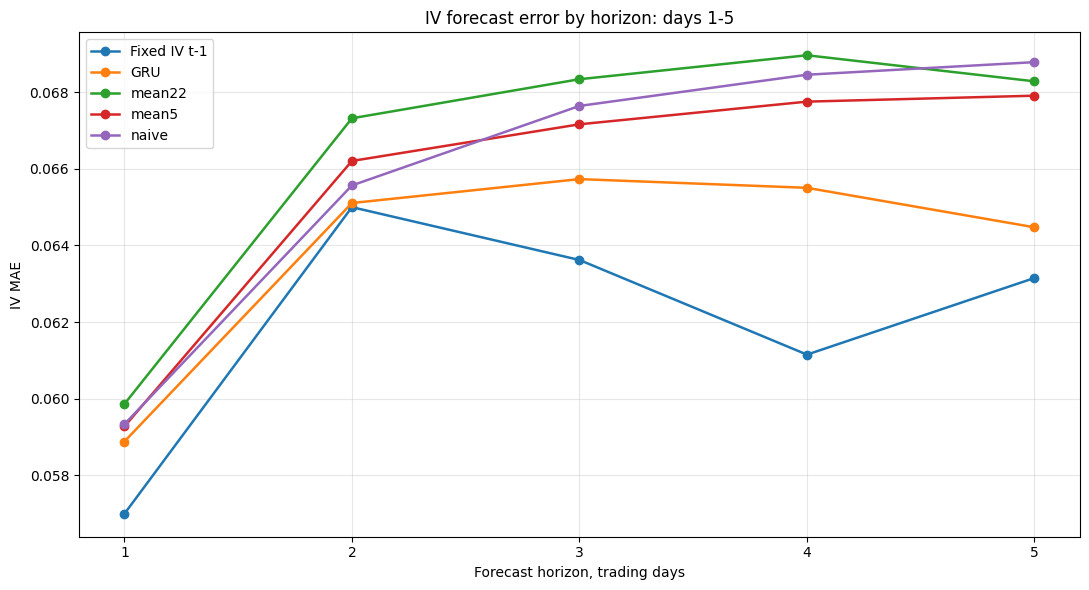

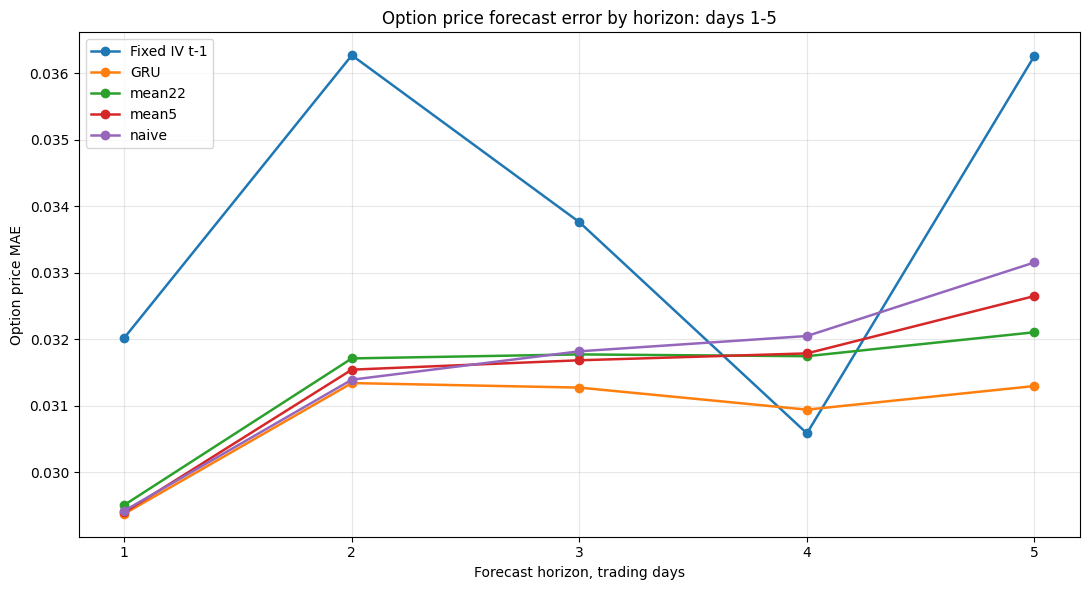


================ IMPROVEMENT VS FIXED IV t-1 BY HORIZON ================


,horizon_day,model,error_type,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,model_pretty,MAE_improvement_vs_fixed_tminus1_pct
0,1,bench_iv_fixed_tminus1,IV,1206,0.056991,0.094567,-0.014270,0.034334,26.658236,Fixed IV t-1,0.000000
1,1,pred_iv_sabr_sigma_gru_h5_ann,IV,1206,0.058879,0.100827,-0.028049,0.035313,27.541194,GRU,-3.312140
2,1,pred_iv_sabr_sigma_mean5_h5_ann,IV,1206,0.059273,0.102011,-0.029228,0.035388,27.725235,mean5,-4.002511
3,1,pred_iv_sabr_sigma_naive_h5_ann,IV,1206,0.059331,0.101740,-0.028762,0.035604,27.752710,naive,-4.105577
4,1,pred_iv_sabr_sigma_mean22_h5_ann,IV,1206,0.059859,0.102494,-0.030133,0.035274,27.999603,mean22,-5.031719
5,2,bench_iv_fixed_tminus1,IV,1086,0.065001,0.104866,-0.016902,0.039830,30.058892,Fixed IV t-1,0.000000
6,2,pred_iv_sabr_sigma_gru_h5_ann,IV,1086,0.065109,0.110441,-0.033642,0.037351,30.108716,GRU,-0.165753
7,2,pred_iv_sabr_sigma_naive_h5_ann,IV,1086,0.065569,0.112170,-0.034391,0.037369,30.321198,naive,-0.872640
8,2,pred_iv_sabr_sigma_mean5_h5_ann,IV,1086,0.066208,0.112550,-0.035784,0.038118,30.616905,mean5,-1.856398
9,2,pred_iv_sabr_sigma_mean22_h5_ann,IV,1086,0.067323,0.113601,-0.037663,0.038254,31.132378,mean22,-3.571274



Saved:
outputs/oos_error_by_horizon_1_5_metrics.csv
outputs/oos_error_by_horizon_1_5_predictions.csv


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

HORIZONS_TO_PLOT = [1, 2, 3, 4, 5]


FORECAST_KINDS_TO_PLOT = ["sabr"]


PRICE_STATE_MODE_FOR_HORIZON_PLOT = "future_realized_state"


year_start = pd.Timestamp(f"{EVAL_YEAR}-01-01")
year_end = pd.Timestamp(f"{EVAL_YEAR + 1}-01-01")
valid_start = year_start + pd.DateOffset(months=TRAIN_MONTHS)
oos_start = valid_start + pd.DateOffset(months=VALIDATION_MONTHS)


def ensure_trade_date_ranks_for_horizon(signal_df, target_df):
    signal = signal_df.copy()
    target = target_df.copy()

    all_dates = (
        pd.Series(
            pd.concat([signal[DATE_COL], target[DATE_COL]], ignore_index=True)
            .dropna()
            .unique()
        )
        .sort_values()
        .reset_index(drop=True)
    )

    date_rank = pd.DataFrame({
        DATE_COL: all_dates,
        "trade_date_rank_tmp": np.arange(len(all_dates)),
    })

    signal = signal.drop(columns=["trade_date_rank_tmp"], errors="ignore")
    target = target.drop(columns=["trade_date_rank_tmp"], errors="ignore")

    signal = signal.merge(date_rank, on=DATE_COL, how="left")
    target = target.merge(date_rank, on=DATE_COL, how="left")

    rank_to_date = dict(zip(date_rank["trade_date_rank_tmp"], date_rank[DATE_COL]))

    return signal, target, rank_to_date


def build_horizon_eval_df(signal_df, target_source_df, horizon):
\
\


    signal, target_source, rank_to_date = ensure_trade_date_ranks_for_horizon(
        signal_df,
        target_source_df,
    )

    signal = signal.copy()
    signal["target_trade_date_h"] = signal["trade_date_rank_tmp"].map(
        lambda x: rank_to_date.get(x + horizon, pd.NaT)
    )

    target_cols = [
        "market_price",
        "iv",
        "spot_for_pricing",
        "forward_for_pricing",
        "T_model",
        "T_days",
        "rd",
        "rf",
        "moneyness",
    ]

    target_cols = [c for c in target_cols if c in target_source.columns]

    future = (
        target_source[CONTRACT_KEYS + [DATE_COL] + target_cols]
        .copy()
        .rename(columns={DATE_COL: "target_trade_date_h"})
    )

    rename_map = {c: f"target_{c}_h" for c in target_cols}
    future = future.rename(columns=rename_map)

    group_cols = CONTRACT_KEYS + ["target_trade_date_h"]
    num_cols = [c for c in future.columns if c not in group_cols]

    future = (
        future
        .groupby(group_cols, as_index=False)[num_cols]
        .median()
    )

    out = signal.merge(
        future,
        on=CONTRACT_KEYS + ["target_trade_date_h"],
        how="left",
    )

    out["horizon_day"] = horizon

    out = out[
        out["target_trade_date_h"].notna()
        & np.isfinite(out["target_market_price_h"]) & (out["target_market_price_h"] > 0)
        & np.isfinite(out["target_iv_h"]) & (out["target_iv_h"] > IV_MIN) & (out["target_iv_h"] < IV_MAX)
    ].copy()

    return out


def add_pricing_state_for_horizon(df_in, mode=PRICE_STATE_MODE_FOR_HORIZON_PLOT):
    out = df_in.copy()

    if mode == "future_realized_state":
        out["pricing_spot"] = pd.to_numeric(out["target_spot_for_pricing_h"], errors="coerce")
        out["pricing_T"] = pd.to_numeric(out["target_T_model_h"], errors="coerce")
        out["pricing_rd"] = pd.to_numeric(out["target_rd_h"], errors="coerce")
        out["pricing_rf"] = pd.to_numeric(out["target_rf_h"], errors="coerce")

        if "target_forward_for_pricing_h" in out.columns:
            out["pricing_forward"] = pd.to_numeric(out["target_forward_for_pricing_h"], errors="coerce")
        else:
            out["pricing_forward"] = np.nan

    elif mode == "current_state":
        out["pricing_spot"] = pd.to_numeric(out["spot_for_pricing"], errors="coerce")
        out["pricing_T"] = pd.to_numeric(out["T_model"], errors="coerce")
        out["pricing_rd"] = pd.to_numeric(out["rd"], errors="coerce")
        out["pricing_rf"] = pd.to_numeric(out["rf"], errors="coerce")
        out["pricing_forward"] = pd.to_numeric(out["forward_for_pricing"], errors="coerce")

    else:
        raise ValueError("mode must be 'future_realized_state' or 'current_state'.")

    bad_forward = (
        ~np.isfinite(out["pricing_forward"])
        | (out["pricing_forward"] <= 0)
    )

    out.loc[bad_forward, "pricing_forward"] = (
        out.loc[bad_forward, "pricing_spot"]
        * np.exp(
            (out.loc[bad_forward, "pricing_rd"] - out.loc[bad_forward, "pricing_rf"])
            * out.loc[bad_forward, "pricing_T"]
        )
    )

    out["pricing_moneyness"] = np.log(out["strike"] / out["pricing_forward"])

    out = out[
        np.isfinite(out["pricing_spot"]) & (out["pricing_spot"] > 0)
        & np.isfinite(out["pricing_forward"]) & (out["pricing_forward"] > 0)
        & np.isfinite(out["pricing_T"]) & (out["pricing_T"] > 0)
        & np.isfinite(out["pricing_rd"])
        & np.isfinite(out["pricing_rf"])
        & np.isfinite(out["pricing_moneyness"])
    ].copy()

    lower, upper = gk_bounds_state(out)

    out["price_lower_bound"] = lower
    out["price_upper_bound"] = upper

    return out


def horizon_metric(df_in, pred_col, target_col, horizon, error_type):
    d = (
        df_in[[pred_col, target_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    if len(d) == 0:
        return {
            "horizon_day": horizon,
            "model": pred_col,
            "error_type": error_type,
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "MedianAE": np.nan,
            "WMAPE_pct": np.nan,
        }

    err = d[pred_col] - d[target_col]

    return {
        "horizon_day": horizon,
        "model": pred_col,
        "error_type": error_type,
        "n": len(d),
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "Bias": float(np.mean(err)),
        "MedianAE": float(np.median(np.abs(err))),
        "WMAPE_pct": float(100 * np.sum(np.abs(err)) / max(np.sum(np.abs(d[target_col])), EPS)),
    }


horizon_metric_rows = []
horizon_eval_list = []


signal_source = df_signal.copy()
target_source = df.copy()

for h in HORIZONS_TO_PLOT:
    print(f"\n================ HORIZON t+{h} ================")


    RV_HORIZON_DAYS = h

    h_df = build_horizon_eval_df(
        signal_df=signal_source,
        target_source_df=target_source,
        horizon=h,
    )


    h_df = h_df[
        (h_df["target_trade_date_h"] >= oos_start)
        & (h_df["target_trade_date_h"] < year_end)
    ].copy()

    if len(h_df) == 0:
        print(f"No OOS rows for horizon {h}.")
        continue

    h_df = add_pricing_state_for_horizon(
        h_df,
        mode=PRICE_STATE_MODE_FOR_HORIZON_PLOT,
    )

    h_df = add_fixed_iv_tminus1_benchmark(h_df)

    iv_cols_h = ["bench_iv_fixed_tminus1"]
    price_cols_h = ["bench_price_fixed_tminus1"]

    for sig_col in rv_cols_existing:
        if sig_col not in h_df.columns:
            continue

        h_df = compute_forecasts_for_sigma(h_df, sig_col)

        for kind in FORECAST_KINDS_TO_PLOT:
            iv_col = f"pred_iv_{kind}_{sig_col}"
            price_col = f"pred_price_{kind}_{sig_col}"

            if iv_col in h_df.columns:
                iv_cols_h.append(iv_col)

            if price_col in h_df.columns:
                price_cols_h.append(price_col)

    iv_cols_h = list(dict.fromkeys(iv_cols_h))
    price_cols_h = list(dict.fromkeys(price_cols_h))

    for c in iv_cols_h:
        horizon_metric_rows.append(
            horizon_metric(
                h_df,
                pred_col=c,
                target_col="target_iv_h",
                horizon=h,
                error_type="IV",
            )
        )

    for c in price_cols_h:
        horizon_metric_rows.append(
            horizon_metric(
                h_df,
                pred_col=c,
                target_col="target_market_price_h",
                horizon=h,
                error_type="PRICE",
            )
        )

    keep_cols = (
        CONTRACT_KEYS
        + [
            DATE_COL,
            "target_trade_date_h",
            "horizon_day",
            "target_iv_h",
            "target_market_price_h",
        ]
        + iv_cols_h
        + price_cols_h
    )

    keep_cols = [c for c in keep_cols if c in h_df.columns]
    keep_cols = list(dict.fromkeys(keep_cols))

    horizon_eval_list.append(h_df[keep_cols].copy())

    print("Rows:", len(h_df))


horizon_metrics = pd.DataFrame(horizon_metric_rows)

if len(horizon_eval_list) > 0:
    horizon_eval_df = pd.concat(horizon_eval_list, ignore_index=True)
else:
    horizon_eval_df = pd.DataFrame()

print("\n================ HORIZON METRICS 1-5 ================")
display(
    horizon_metrics
    .sort_values(["error_type", "horizon_day", "MAE"])
    .reset_index(drop=True)
)


def pretty_model_name(x):
    if x == "bench_iv_fixed_tminus1":
        return "Fixed IV t-1"
    if x == "bench_price_fixed_tminus1":
        return "Fixed IV t-1"

    name = x

    name = name.replace("pred_iv_sabr_", "")
    name = name.replace("pred_price_sabr_", "")
    name = name.replace("pred_iv_quad_", "")
    name = name.replace("pred_price_quad_", "")
    name = name.replace("pred_iv_flat_", "")
    name = name.replace("pred_price_flat_", "")

    name = name.replace("sigma_", "")
    name = name.replace("_h5_ann", "")
    name = name.replace("_", " ")

    return name.upper() if name in ["gru"] else name


horizon_metrics["model_pretty"] = horizon_metrics["model"].apply(pretty_model_name)


iv_plot_df = horizon_metrics[
    horizon_metrics["error_type"] == "IV"
].copy()

plt.figure(figsize=(11, 6))

for model, g in iv_plot_df.groupby("model_pretty"):
    g = g.sort_values("horizon_day")
    plt.plot(
        g["horizon_day"],
        g["MAE"],
        marker="o",
        linewidth=1.8,
        label=model,
    )

plt.xlabel("Forecast horizon, trading days")
plt.ylabel("IV MAE")
plt.title("IV forecast error by horizon: days 1-5")
plt.xticks(HORIZONS_TO_PLOT)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


price_plot_df = horizon_metrics[
    horizon_metrics["error_type"] == "PRICE"
].copy()

plt.figure(figsize=(11, 6))

for model, g in price_plot_df.groupby("model_pretty"):
    g = g.sort_values("horizon_day")
    plt.plot(
        g["horizon_day"],
        g["MAE"],
        marker="o",
        linewidth=1.8,
        label=model,
    )

plt.xlabel("Forecast horizon, trading days")
plt.ylabel("Option price MAE")
plt.title("Option price forecast error by horizon: days 1-5")
plt.xticks(HORIZONS_TO_PLOT)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


def add_improvement_vs_fixed(group):
    group = group.copy()

    if group["error_type"].iloc[0] == "IV":
        bench_name = "bench_iv_fixed_tminus1"
    else:
        bench_name = "bench_price_fixed_tminus1"

    bench = group.loc[group["model"] == bench_name, "MAE"]

    if len(bench) == 0 or not np.isfinite(bench.iloc[0]):
        group["MAE_improvement_vs_fixed_tminus1_pct"] = np.nan
    else:
        b = bench.iloc[0]
        group["MAE_improvement_vs_fixed_tminus1_pct"] = 100 * (b - group["MAE"]) / max(b, EPS)

    return group


horizon_metrics_with_improvement = (
    horizon_metrics
    .groupby(["error_type", "horizon_day"], group_keys=False)
    .apply(add_improvement_vs_fixed)
    .reset_index(drop=True)
)

print("\n================ IMPROVEMENT VS FIXED IV t-1 BY HORIZON ================")
display(
    horizon_metrics_with_improvement
    .sort_values(["error_type", "horizon_day", "MAE"])
    .reset_index(drop=True)
)


out_horizon_metrics = f"{OUT_DIR}/oos_error_by_horizon_1_5_metrics.csv"
out_horizon_eval = f"{OUT_DIR}/oos_error_by_horizon_1_5_predictions.csv"

horizon_metrics_with_improvement.to_csv(out_horizon_metrics, index=False)

if len(horizon_eval_df) > 0:
    horizon_eval_df.to_csv(out_horizon_eval, index=False)

print("\nSaved:")
print(out_horizon_metrics)
if len(horizon_eval_df) > 0:
    print(out_horizon_eval)


In [8]:
def gk_vega_vec_for_state(df_in, sigma_col):
    S = pd.to_numeric(df_in["pricing_spot"], errors="coerce").astype(float).values
    K = pd.to_numeric(df_in["strike"], errors="coerce").astype(float).values
    T = pd.to_numeric(df_in["pricing_T"], errors="coerce").astype(float).values
    rd = pd.to_numeric(df_in["pricing_rd"], errors="coerce").astype(float).values
    rf = pd.to_numeric(df_in["pricing_rf"], errors="coerce").astype(float).values
    sigma = pd.to_numeric(df_in[sigma_col], errors="coerce").astype(float).values

    out = np.full(len(df_in), np.nan)

    ok = (
        np.isfinite(S) & np.isfinite(K) & np.isfinite(T)
        & np.isfinite(rd) & np.isfinite(rf) & np.isfinite(sigma)
        & (S > 0) & (K > 0) & (T > 0) & (sigma > 0)
    )

    if ok.sum() == 0:
        return pd.Series(out, index=df_in.index)

    vol_sqrt = sigma[ok] * np.sqrt(T[ok])

    d1 = (
        np.log(S[ok] / K[ok])
        + (rd[ok] - rf[ok] + 0.5 * sigma[ok] ** 2) * T[ok]
    ) / vol_sqrt

    out[ok] = S[ok] * np.exp(-rf[ok] * T[ok]) * norm.pdf(d1) * np.sqrt(T[ok])

    return pd.Series(out, index=df_in.index)


weighted_rows = []

for c in iv_forecast_cols:
    d = oos_result[[c, "target_iv_h5"]].replace([np.inf, -np.inf], np.nan).dropna().copy()


    tmp = oos_result.loc[d.index].copy()
    tmp["_target_iv_for_vega"] = tmp["target_iv_h5"]

    vega = gk_vega_vec_for_state(tmp, "_target_iv_for_vega")
    vega = vega.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    err = d[c] - d["target_iv_h5"]

    weighted_rows.append({
        "model": c,
        "n": len(d),
        "IV_MAE": np.mean(np.abs(err)),
        "Vega_weighted_IV_MAE": np.sum(vega.loc[d.index] * np.abs(err)) / max(np.sum(vega.loc[d.index]), EPS),
        "Bias": np.mean(err),
    })

vega_weighted_iv_metrics = (
    pd.DataFrame(weighted_rows)
    .sort_values("Vega_weighted_IV_MAE")
    .reset_index(drop=True)
)

display(vega_weighted_iv_metrics)


,model,n,IV_MAE,Vega_weighted_IV_MAE,Bias
0,pred_iv_sabr_sigma_gru_h5_ann,807,0.064475,0.047136,-0.039605
1,pred_iv_sabr_sigma_mean22_h5_ann,807,0.068288,0.049060,-0.046908
2,bench_iv_fixed_tminus1,807,0.063151,0.049126,-0.013301
3,pred_iv_sabr_sigma_mean5_h5_ann,807,0.067913,0.049504,-0.044226
4,pred_iv_sabr_sigma_naive_h5_ann,807,0.068789,0.050185,-0.042701
5,pred_iv_quad_sigma_gru_h5_ann,807,0.065793,0.051331,-0.022491
6,pred_iv_quad_sigma_mean22_h5_ann,807,0.068939,0.052849,-0.029799
7,pred_iv_quad_sigma_mean5_h5_ann,807,0.068775,0.053423,-0.027114
8,pred_iv_quad_sigma_naive_h5_ann,807,0.069687,0.054041,-0.025591
9,pred_iv_flat_sigma_gru_h5_ann,807,0.079690,0.065563,-0.070764



================ PRICE-AWARE ML SETUP ================
Train rows before filters: 1186
OOS rows before filters: 807
PRICE_STATE_MODE: future_realized_state
By call/put models: False

================ sigma_gru_h5_ann ================
ML train rows: 1186
ML OOS rows: 807

================ sigma_naive_h5_ann ================
ML train rows: 1186
ML OOS rows: 807

================ sigma_mean5_h5_ann ================
ML train rows: 1186
ML OOS rows: 807

================ sigma_mean22_h5_ann ================
ML train rows: 1186
ML OOS rows: 807

================ PRICE-AWARE ML MODEL INFO ================


,sigma_col,ml_price_col,ml_iv_col,target_col,spec_key,by_option_type,train_rows,oos_rows,fitted_groups
0,sigma_gru_h5_ann,ml_price_residual_price_global_sigma_gru_h5_ann,ml_iv_from_price_residual_price_global_sigma_gru_h5_ann,target_residual_price,residual_price,False,1186,807,ALL
1,sigma_gru_h5_ann,ml_price_log_price_ratio_global_sigma_gru_h5_ann,ml_iv_from_price_log_price_ratio_global_sigma_gru_h5_ann,target_log_price_ratio,log_price_ratio,False,1186,807,ALL
2,sigma_gru_h5_ann,ml_price_vega_residual_global_sigma_gru_h5_ann,ml_iv_from_price_vega_residual_global_sigma_gru_h5_ann,target_vega_residual,vega_residual,False,1186,807,ALL
3,sigma_naive_h5_ann,ml_price_residual_price_global_sigma_naive_h5_ann,ml_iv_from_price_residual_price_global_sigma_naive_h5_ann,target_residual_price,residual_price,False,1186,807,ALL
4,sigma_naive_h5_ann,ml_price_log_price_ratio_global_sigma_naive_h5_ann,ml_iv_from_price_log_price_ratio_global_sigma_naive_h5_ann,target_log_price_ratio,log_price_ratio,False,1186,807,ALL
5,sigma_naive_h5_ann,ml_price_vega_residual_global_sigma_naive_h5_ann,ml_iv_from_price_vega_residual_global_sigma_naive_h5_ann,target_vega_residual,vega_residual,False,1186,807,ALL
6,sigma_mean5_h5_ann,ml_price_residual_price_global_sigma_mean5_h5_ann,ml_iv_from_price_residual_price_global_sigma_mean5_h5_ann,target_residual_price,residual_price,False,1186,807,ALL
7,sigma_mean5_h5_ann,ml_price_log_price_ratio_global_sigma_mean5_h5_ann,ml_iv_from_price_log_price_ratio_global_sigma_mean5_h5_ann,target_log_price_ratio,log_price_ratio,False,1186,807,ALL
8,sigma_mean5_h5_ann,ml_price_vega_residual_global_sigma_mean5_h5_ann,ml_iv_from_price_vega_residual_global_sigma_mean5_h5_ann,target_vega_residual,vega_residual,False,1186,807,ALL
9,sigma_mean22_h5_ann,ml_price_residual_price_global_sigma_mean22_h5_ann,ml_iv_from_price_residual_price_global_sigma_mean22_h5_ann,target_residual_price,residual_price,False,1186,807,ALL



================ FULL OOS IV METRICS ================


,model,target,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,category,MAE_improvement_vs_fixed_iv_tminus1_pct,RMSE_improvement_vs_fixed_iv_tminus1_pct,WMAPE_improvement_vs_fixed_iv_tminus1_pct
0,ml_iv_from_price_log_price_ratio_global_sigma_mean22_h5_ann,target_iv_h5,807,0.043176,0.061842,-0.004578,0.029975,20.496329,3_priceaware_ml_residual,31.630232,44.586404,31.630232
1,ml_iv_from_price_residual_price_global_sigma_mean22_h5_ann,target_iv_h5,804,0.044072,0.060373,0.015414,0.032003,20.922488,3_priceaware_ml_residual,30.211435,45.902707,30.208690
2,ml_iv_from_price_vega_residual_global_sigma_mean22_h5_ann,target_iv_h5,807,0.045225,0.060105,0.017084,0.033876,21.468809,3_priceaware_ml_residual,28.386323,46.142934,28.386323
3,ml_iv_from_price_log_price_ratio_global_sigma_mean5_h5_ann,target_iv_h5,807,0.046887,0.065971,0.013810,0.033664,22.257936,3_priceaware_ml_residual,25.754027,40.886713,25.754027
4,ml_iv_from_price_log_price_ratio_global_sigma_naive_h5_ann,target_iv_h5,807,0.047774,0.068965,0.022225,0.033561,22.679001,3_priceaware_ml_residual,24.349477,38.203465,24.349477
5,ml_iv_from_price_residual_price_global_sigma_mean5_h5_ann,target_iv_h5,807,0.047911,0.064903,0.019435,0.035368,22.743874,3_priceaware_ml_residual,24.133080,41.843159,24.133080
6,ml_iv_from_price_residual_price_global_sigma_gru_h5_ann,target_iv_h5,807,0.049962,0.067785,0.026389,0.037000,23.717648,3_priceaware_ml_residual,20.884851,39.260935,20.884851
7,ml_iv_from_price_vega_residual_global_sigma_mean5_h5_ann,target_iv_h5,807,0.050739,0.065483,0.027305,0.041771,24.086600,3_priceaware_ml_residual,19.654136,41.323918,19.654136
8,ml_iv_from_price_residual_price_global_sigma_naive_h5_ann,target_iv_h5,807,0.051867,0.069635,0.031446,0.036816,24.621800,3_priceaware_ml_residual,17.868865,37.603045,17.868865
9,ml_iv_from_price_vega_residual_global_sigma_gru_h5_ann,target_iv_h5,807,0.052593,0.068170,0.029992,0.042360,24.966461,3_priceaware_ml_residual,16.719177,38.916366,16.719177



================ FULL OOS PRICE METRICS ================


,model,target,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,category,MAE_improvement_vs_fixed_iv_tminus1_pct,RMSE_improvement_vs_fixed_iv_tminus1_pct,WMAPE_improvement_vs_fixed_iv_tminus1_pct
0,ml_price_log_price_ratio_global_sigma_mean22_h5_ann,target_market_price_h5,807,0.025587,0.035177,-0.001427,0.018413,11.756212,3_priceaware_ml_residual,29.435282,61.004281,29.435282
1,ml_price_residual_price_global_sigma_mean22_h5_ann,target_market_price_h5,807,0.026469,0.035832,0.007064,0.020571,12.161444,3_priceaware_ml_residual,27.002944,60.278033,27.002944
2,ml_price_log_price_ratio_global_sigma_naive_h5_ann,target_market_price_h5,807,0.027899,0.037498,0.009420,0.021451,12.818440,3_priceaware_ml_residual,23.059431,58.432141,23.059431
3,ml_price_log_price_ratio_global_sigma_mean5_h5_ann,target_market_price_h5,807,0.028701,0.039326,0.007347,0.020991,13.187006,3_priceaware_ml_residual,20.847179,56.405348,20.847179
4,ml_price_residual_price_global_sigma_mean5_h5_ann,target_market_price_h5,807,0.029085,0.038894,0.009328,0.023123,13.363338,3_priceaware_ml_residual,19.788771,56.884702,19.788771
5,ml_price_residual_price_global_sigma_gru_h5_ann,target_market_price_h5,807,0.029309,0.038089,0.012909,0.023930,13.466345,3_priceaware_ml_residual,19.170493,57.776838,19.170493
6,ml_price_vega_residual_global_sigma_mean22_h5_ann,target_market_price_h5,807,0.029723,0.040701,0.011195,0.021992,13.656450,3_priceaware_ml_residual,18.029419,54.880802,18.029419
7,ml_price_residual_price_global_sigma_naive_h5_ann,target_market_price_h5,807,0.030138,0.038910,0.014598,0.023892,13.847017,3_priceaware_ml_residual,16.885573,56.865990,16.885573
8,ml_price_log_price_ratio_global_sigma_gru_h5_ann,target_market_price_h5,807,0.030973,0.042158,0.012354,0.022179,14.230962,3_priceaware_ml_residual,14.581003,53.265346,14.581003
9,pred_price_sabr_sigma_gru_h5_ann,target_market_price_h5,807,0.031299,0.042853,-0.011288,0.022438,14.380591,2_pure_sabr_anchor,13.682880,52.495810,13.682880



================ BEST PRICE MODELS BY CATEGORY ================


,model,target,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,category,MAE_improvement_vs_fixed_iv_tminus1_pct,RMSE_improvement_vs_fixed_iv_tminus1_pct,WMAPE_improvement_vs_fixed_iv_tminus1_pct
0,bench_price_fixed_tminus1,target_market_price_h5,807,0.036261,0.090208,0.006495,0.022712,16.660184,1_fixed_iv_tminus1_benchmark,0.000000,0.000000,0.000000
1,pred_price_flat_sigma_gru_h5_ann,target_market_price_h5,807,0.041442,0.053910,-0.035818,0.032428,19.040645,2_pure_flat_volatility,-14.288323,40.238299,-14.288323
2,pred_price_flat_sigma_mean22_h5_ann,target_market_price_h5,807,0.049284,0.062266,-0.047270,0.040737,22.643887,2_pure_flat_volatility,-35.916188,30.974728,-35.916188
3,pred_price_flat_sigma_mean5_h5_ann,target_market_price_h5,807,0.049864,0.065460,-0.043940,0.037777,22.910223,2_pure_flat_volatility,-37.514827,27.434279,-37.514827
4,pred_price_flat_sigma_naive_h5_ann,target_market_price_h5,807,0.053156,0.070746,-0.041059,0.039445,24.422953,2_pure_flat_volatility,-46.594740,21.574433,-46.594740
5,pred_price_quad_sigma_gru_h5_ann,target_market_price_h5,807,0.037688,0.092855,0.001999,0.022112,17.316180,2_pure_quadratic_anchor,-3.937507,-2.934697,-3.937507
6,pred_price_quad_sigma_mean22_h5_ann,target_market_price_h5,807,0.038239,0.092905,-0.001304,0.022551,17.569080,2_pure_quadratic_anchor,-5.455500,-2.989557,-5.455500
7,pred_price_quad_sigma_mean5_h5_ann,target_market_price_h5,807,0.038880,0.093004,-0.000259,0.023876,17.863659,2_pure_quadratic_anchor,-7.223660,-3.099062,-7.223660
8,pred_price_quad_sigma_naive_h5_ann,target_market_price_h5,807,0.039392,0.093523,0.000926,0.025713,18.098894,2_pure_quadratic_anchor,-8.635616,-3.674924,-8.635616
9,pred_price_sabr_sigma_gru_h5_ann,target_market_price_h5,807,0.031299,0.042853,-0.011288,0.022438,14.380591,2_pure_sabr_anchor,13.682880,52.495810,13.682880



================ BEST IV MODELS BY CATEGORY ================


,model,target,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,category,MAE_improvement_vs_fixed_iv_tminus1_pct,RMSE_improvement_vs_fixed_iv_tminus1_pct,WMAPE_improvement_vs_fixed_iv_tminus1_pct
0,bench_iv_fixed_tminus1,target_iv_h5,807,0.063151,0.111601,-0.013301,0.035534,29.978644,1_fixed_iv_tminus1_benchmark,0.000000,0.000000,0.000000
1,pred_iv_flat_sigma_gru_h5_ann,target_iv_h5,807,0.079690,0.117768,-0.070764,0.057305,37.829936,2_pure_flat_volatility,-26.189617,-5.526028,-26.189617
2,pred_iv_flat_sigma_mean22_h5_ann,target_iv_h5,807,0.093299,0.128741,-0.089522,0.072594,44.289988,2_pure_flat_volatility,-47.738466,-15.358627,-47.738466
3,pred_iv_flat_sigma_mean5_h5_ann,target_iv_h5,807,0.094069,0.128703,-0.085194,0.078749,44.655530,2_pure_flat_volatility,-48.957808,-15.324313,-48.957808
4,pred_iv_flat_sigma_naive_h5_ann,target_iv_h5,807,0.099968,0.136975,-0.084292,0.083918,47.456032,2_pure_flat_volatility,-58.299465,-22.736543,-58.299465
5,pred_iv_quad_sigma_gru_h5_ann,target_iv_h5,807,0.065793,0.116130,-0.022491,0.036439,31.232841,2_pure_quadratic_anchor,-4.183637,-4.058873,-4.183637
6,pred_iv_quad_sigma_mean5_h5_ann,target_iv_h5,807,0.068775,0.118100,-0.027114,0.040008,32.648136,2_pure_quadratic_anchor,-8.904647,-5.823875,-8.904647
7,pred_iv_quad_sigma_mean22_h5_ann,target_iv_h5,807,0.068939,0.119481,-0.029799,0.038915,32.725979,2_pure_quadratic_anchor,-9.164309,-7.061104,-9.164309
8,pred_iv_quad_sigma_naive_h5_ann,target_iv_h5,807,0.069687,0.120005,-0.025591,0.041236,33.081510,2_pure_quadratic_anchor,-10.350258,-7.530591,-10.350258
9,pred_iv_sabr_sigma_gru_h5_ann,target_iv_h5,807,0.064475,0.105959,-0.039605,0.039306,30.607213,2_pure_sabr_anchor,-2.096725,5.055398,-2.096725


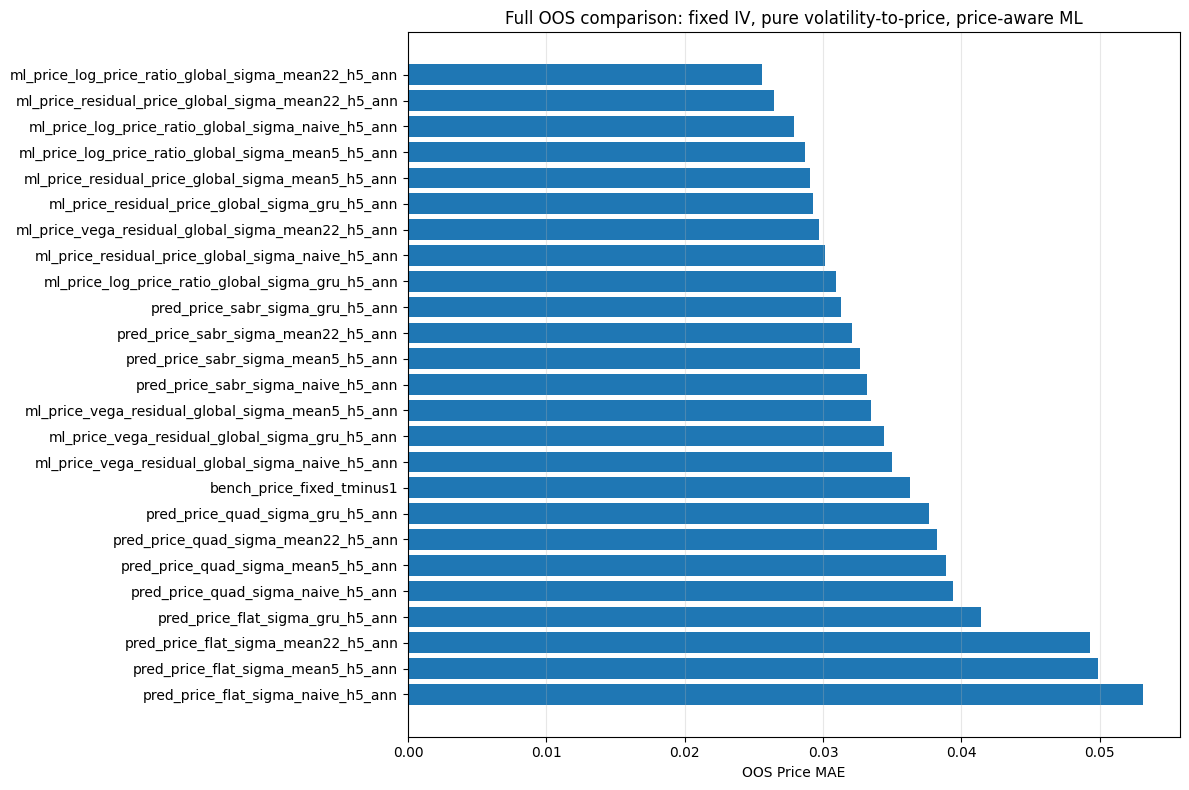

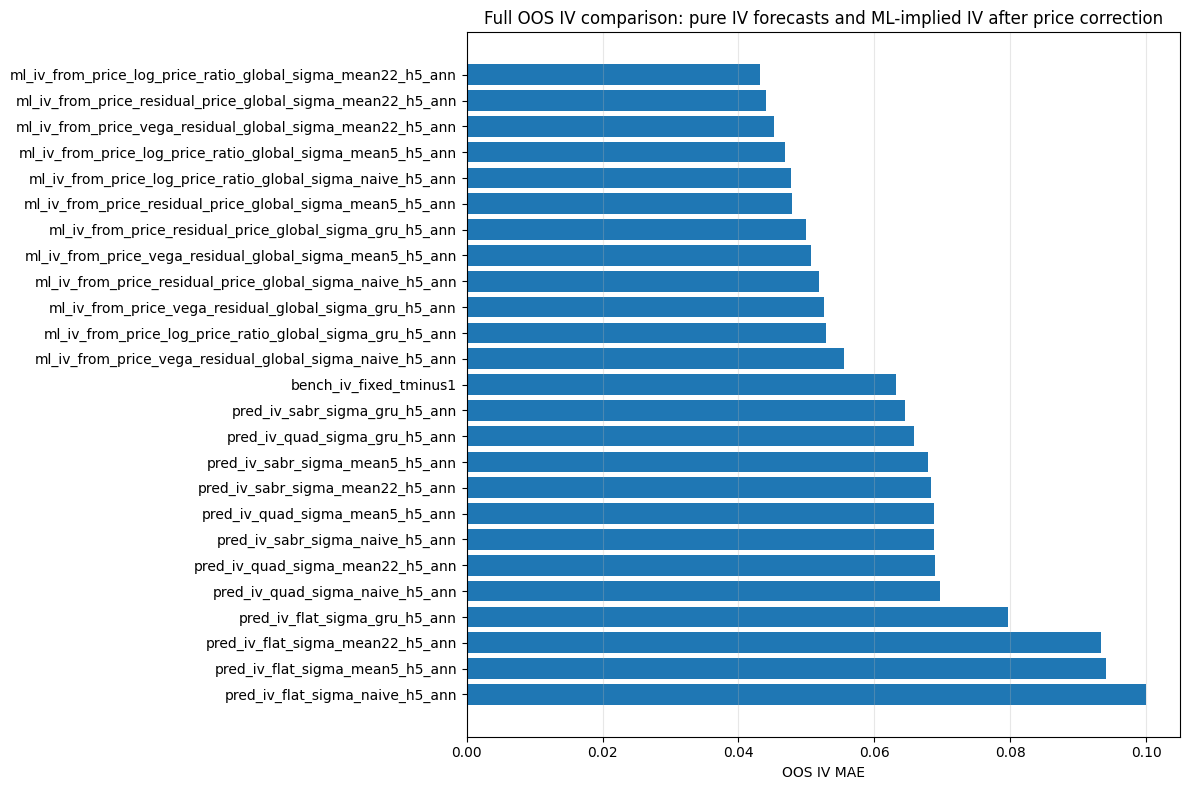


Saved:
outputs/full_oos_5d_fixed_pure_priceaware_predictions.csv
outputs/full_oos_5d_iv_metrics_fixed_pure_priceaware.csv
outputs/full_oos_5d_price_metrics_fixed_pure_priceaware.csv
outputs/full_oos_5d_best_price_by_category.csv
outputs/full_oos_5d_best_iv_by_category.csv
outputs/full_oos_5d_priceaware_ml_model_info.csv


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

try:
    from IPython.display import display
except Exception:
    display = print


PRICEAWARE_REFIT_ON_TRAIN_PLUS_VALIDATION = True


PRICEAWARE_USE_BY_CP = False

PRICEAWARE_RANDOM_STATE = 42

PRICEAWARE_TARGET_SPECS = [
    ("residual_price", "target_residual_price"),
    ("log_price_ratio", "target_log_price_ratio"),
    ("vega_residual", "target_vega_residual"),
]

PRICEAWARE_EPS = 1e-12
PRICEAWARE_PRICE_EPS = 1e-4


required_objects = [
    "train_base",
    "valid_base",
    "oos_base",
    "rv_cols_existing",
    "add_pricing_state",
    "add_fixed_iv_tminus1_benchmark",
    "compute_forecasts_for_sigma",
    "gk_price_vec",
    "gk_iv_vec",
]

missing_objects = [x for x in required_objects if x not in globals()]
if missing_objects:
    raise ValueError(
        "Missing objects from the previous 5D cell: "
        + ", ".join(missing_objects)
    )


def gk_vega_vec_state(df_in, sigma_col):
    S = pd.to_numeric(df_in["pricing_spot"], errors="coerce").astype(float).values
    K = pd.to_numeric(df_in["strike"], errors="coerce").astype(float).values
    T = pd.to_numeric(df_in["pricing_T"], errors="coerce").astype(float).values
    rd = pd.to_numeric(df_in["pricing_rd"], errors="coerce").astype(float).values
    rf = pd.to_numeric(df_in["pricing_rf"], errors="coerce").astype(float).values
    sigma = pd.to_numeric(df_in[sigma_col], errors="coerce").astype(float).values

    out = np.full(len(df_in), np.nan)

    ok = (
        np.isfinite(S) & np.isfinite(K) & np.isfinite(T)
        & np.isfinite(rd) & np.isfinite(rf) & np.isfinite(sigma)
        & (S > 0) & (K > 0) & (T > 0) & (sigma > 0)
    )

    if ok.sum() == 0:
        return pd.Series(out, index=df_in.index)

    vol_sqrt = sigma[ok] * np.sqrt(T[ok])

    d1 = (
        np.log(S[ok] / K[ok])
        + (rd[ok] - rf[ok] + 0.5 * sigma[ok] ** 2) * T[ok]
    ) / vol_sqrt

    out[ok] = S[ok] * np.exp(-rf[ok] * T[ok]) * norm.pdf(d1) * np.sqrt(T[ok])

    return pd.Series(out, index=df_in.index)


def normalize_cp_local(cp):
    s = pd.Series(cp).astype(str).str.upper().str.strip()
    return np.where(
        s.str.startswith("C"),
        "C",
        np.where(s.str.startswith("P"), "P", s),
    )


def prepare_priceaware_dataset(base_df, sigma_col):
\
\
\

    out = base_df.copy()

    out = add_pricing_state(out, mode=PRICE_STATE_MODE)
    out = add_fixed_iv_tminus1_benchmark(out)
    out = compute_forecasts_for_sigma(out, sigma_col)

    prefix = sigma_col

    required_cols = [
        f"pred_price_sabr_{prefix}",
        f"pred_iv_sabr_{prefix}",
        f"pred_iv_quad_{prefix}",
        f"pred_atm_iv_anchor_{prefix}",
        "target_market_price_h5",
        "target_iv_h5",
    ]

    missing = [c for c in required_cols if c not in out.columns]
    if missing:
        raise ValueError(f"Missing columns for {sigma_col}: {missing}")

    out["base_price_sabr"] = pd.to_numeric(out[f"pred_price_sabr_{prefix}"], errors="coerce")
    out["base_iv_sabr"] = pd.to_numeric(out[f"pred_iv_sabr_{prefix}"], errors="coerce")
    out["base_iv_quad"] = pd.to_numeric(out[f"pred_iv_quad_{prefix}"], errors="coerce")
    out["base_atm_iv"] = pd.to_numeric(out[f"pred_atm_iv_anchor_{prefix}"], errors="coerce")
    out["base_sigma_input"] = pd.to_numeric(out[sigma_col], errors="coerce")

    out["base_vega_sabr"] = gk_vega_vec_state(out, "base_iv_sabr")

    out["base_time_value"] = (
        pd.to_numeric(out["base_price_sabr"], errors="coerce")
        - pd.to_numeric(out["price_lower_bound"], errors="coerce")
    ).clip(lower=0.0)

    out = out[
        np.isfinite(out["base_price_sabr"])
        & np.isfinite(out["base_iv_sabr"])
        & np.isfinite(out["base_vega_sabr"])
        & np.isfinite(out["target_market_price_h5"])
        & np.isfinite(out["target_iv_h5"])
        & (out["target_market_price_h5"] > 0)
        & (out["target_iv_h5"] > IV_MIN)
        & (out["target_iv_h5"] < IV_MAX)
    ].copy()

    return out


PRICEAWARE_FEATURES = [
    "base_price_sabr",
    "base_iv_sabr",
    "base_iv_quad",
    "base_atm_iv",
    "base_sigma_input",
    "base_vega_sabr",
    "base_time_value",
    "price_lower_bound",
    "price_upper_bound",
    "m",
    "m2",
    "abs_m",
    "T",
    "sqrt_T",
    "log_T",
    "T_days",
    "put",
    "put_m",
    "put_abs_m",
    "rd",
    "rf",
    "rd_rf_spread",
    "lag_atm_iv",
    "lag_skew",
    "lag_curvature",
    "lag_sabr_rho",
    "lag_sabr_nu",
    "log_base_price",
    "log_vega",
    "log_base_iv_var",
    "log_sigma_var",
]


def make_priceaware_features(df_in):
    X = pd.DataFrame(index=df_in.index)

    m = pd.to_numeric(df_in["pricing_moneyness"], errors="coerce").astype(float)
    T = pd.to_numeric(df_in["pricing_T"], errors="coerce").astype(float).clip(lower=PRICEAWARE_EPS)
    put = (pd.Series(normalize_cp_local(df_in["option_type"]), index=df_in.index) == "P").astype(float)

    base_price = pd.to_numeric(df_in["base_price_sabr"], errors="coerce").astype(float)
    base_iv = pd.to_numeric(df_in["base_iv_sabr"], errors="coerce").astype(float).clip(IV_MIN, IV_MAX)
    base_iv_quad = pd.to_numeric(df_in["base_iv_quad"], errors="coerce").astype(float).clip(IV_MIN, IV_MAX)
    base_sigma = pd.to_numeric(df_in["base_sigma_input"], errors="coerce").astype(float).clip(SIGMA_MIN, SIGMA_MAX)
    vega = pd.to_numeric(df_in["base_vega_sabr"], errors="coerce").astype(float)

    X["base_price_sabr"] = base_price
    X["base_iv_sabr"] = base_iv
    X["base_iv_quad"] = base_iv_quad
    X["base_atm_iv"] = pd.to_numeric(df_in["base_atm_iv"], errors="coerce")
    X["base_sigma_input"] = base_sigma
    X["base_vega_sabr"] = vega
    X["base_time_value"] = pd.to_numeric(df_in["base_time_value"], errors="coerce")

    X["price_lower_bound"] = pd.to_numeric(df_in["price_lower_bound"], errors="coerce")
    X["price_upper_bound"] = pd.to_numeric(df_in["price_upper_bound"], errors="coerce")

    X["m"] = m
    X["m2"] = m ** 2
    X["abs_m"] = np.abs(m)

    X["T"] = T
    X["sqrt_T"] = np.sqrt(T)
    X["log_T"] = np.log(T)
    X["T_days"] = T * 365.0

    X["put"] = put
    X["put_m"] = put * m
    X["put_abs_m"] = put * np.abs(m)

    X["rd"] = pd.to_numeric(df_in["pricing_rd"], errors="coerce")
    X["rf"] = pd.to_numeric(df_in["pricing_rf"], errors="coerce")
    X["rd_rf_spread"] = X["rd"] - X["rf"]

    X["lag_atm_iv"] = pd.to_numeric(df_in["lag_quad_a"], errors="coerce")
    X["lag_skew"] = pd.to_numeric(df_in["lag_quad_b"], errors="coerce")
    X["lag_curvature"] = pd.to_numeric(df_in["lag_quad_c"], errors="coerce")
    X["lag_sabr_rho"] = pd.to_numeric(df_in["lag_sabr_rho"], errors="coerce")
    X["lag_sabr_nu"] = pd.to_numeric(df_in["lag_sabr_nu"], errors="coerce")

    X["log_base_price"] = np.log(base_price.clip(lower=PRICEAWARE_PRICE_EPS))
    X["log_vega"] = np.log(pd.Series(vega, index=df_in.index).clip(lower=PRICEAWARE_PRICE_EPS))
    X["log_base_iv_var"] = np.log((base_iv ** 2).clip(lower=PRICEAWARE_EPS))
    X["log_sigma_var"] = np.log((base_sigma ** 2).clip(lower=PRICEAWARE_EPS))

    return X[PRICEAWARE_FEATURES].replace([np.inf, -np.inf], np.nan)


def add_priceaware_targets(df_in):
    out = df_in.copy()

    market = pd.to_numeric(out["target_market_price_h5"], errors="coerce").astype(float)
    base = pd.to_numeric(out["base_price_sabr"], errors="coerce").astype(float)
    vega = pd.to_numeric(out["base_vega_sabr"], errors="coerce").astype(float)

    finite_vega = vega[np.isfinite(vega)]

    if len(finite_vega) > 0:
        vega_floor = max(np.nanpercentile(finite_vega, 10), 1e-4)
    else:
        vega_floor = 1e-4

    vega_eff = pd.Series(vega, index=out.index).clip(lower=vega_floor)

    out["target_residual_price"] = market - base
    out["target_log_price_ratio"] = np.log(
        (market + PRICEAWARE_PRICE_EPS) / (base + PRICEAWARE_PRICE_EPS)
    )
    out["target_vega_residual"] = (market - base) / vega_eff

    lo = out["target_vega_residual"].quantile(0.01)
    hi = out["target_vega_residual"].quantile(0.99)

    out["target_vega_residual"] = out["target_vega_residual"].clip(lo, hi)

    return out, vega_floor


def make_priceaware_model():
    try:
        reg = HistGradientBoostingRegressor(
            loss="absolute_error",
            max_iter=300,
            learning_rate=0.035,
            max_leaf_nodes=15,
            min_samples_leaf=30,
            l2_regularization=1.0,
            random_state=PRICEAWARE_RANDOM_STATE,
        )
    except TypeError:
        reg = HistGradientBoostingRegressor(
            loss="squared_error",
            max_iter=300,
            learning_rate=0.035,
            max_leaf_nodes=15,
            min_samples_leaf=30,
            l2_regularization=1.0,
            random_state=PRICEAWARE_RANDOM_STATE,
        )

    return make_pipeline(SimpleImputer(strategy="median"), reg)


def fit_priceaware_residual_model(train_df, target_col, by_option_type=False):
    train_df, vega_floor = add_priceaware_targets(train_df)

    fitted = {
        "target_col": target_col,
        "by_option_type": by_option_type,
        "models": {},
        "vega_floor": vega_floor,
    }

    groups = ["C", "P"] if by_option_type else ["ALL"]

    for group in groups:
        if group == "ALL":
            g = train_df.copy()
        else:
            cp_norm = pd.Series(normalize_cp_local(train_df["option_type"]), index=train_df.index)
            g = train_df[cp_norm == group].copy()

        g = g[np.isfinite(g[target_col])].copy()

        if len(g) < 80:
            continue

        X = make_priceaware_features(g)
        y = g[target_col].astype(float)

        model = make_priceaware_model()
        model.fit(X, y)

        fitted["models"][group] = model

    return fitted


def predict_priceaware_residual(df_in, fitted):
    pred = pd.Series(np.nan, index=df_in.index)

    groups = ["C", "P"] if fitted["by_option_type"] else ["ALL"]

    for group in groups:
        if group == "ALL":
            idx = df_in.index
            model = fitted["models"].get("ALL")
        else:
            cp_norm = pd.Series(normalize_cp_local(df_in["option_type"]), index=df_in.index)
            idx = df_in.index[cp_norm == group]
            model = fitted["models"].get(group)

        if model is None or len(idx) == 0:
            continue

        X = make_priceaware_features(df_in.loc[idx])
        pred.loc[idx] = model.predict(X)

    return pred


def apply_priceaware_correction(df_in, fitted, pred_price_col):
    out = df_in.copy()

    pred = predict_priceaware_residual(out, fitted)

    base = pd.to_numeric(out["base_price_sabr"], errors="coerce").astype(float)
    vega = pd.to_numeric(out["base_vega_sabr"], errors="coerce").astype(float)

    target_col = fitted["target_col"]

    if target_col == "target_residual_price":
        corrected = base + pred

    elif target_col == "target_log_price_ratio":
        corrected = (base + PRICEAWARE_PRICE_EPS) * np.exp(pred) - PRICEAWARE_PRICE_EPS

    elif target_col == "target_vega_residual":
        vega_floor = fitted.get("vega_floor", 1e-4)
        vega_eff = pd.Series(vega, index=out.index).clip(lower=vega_floor)
        corrected = base + vega_eff * pred

    else:
        raise ValueError(f"Unknown target_col: {target_col}")

    corrected = pd.Series(corrected, index=out.index).clip(lower=0.0)

    lower = pd.to_numeric(out["price_lower_bound"], errors="coerce").fillna(0.0)
    upper = pd.to_numeric(out["price_upper_bound"], errors="coerce")

    corrected = pd.Series(np.maximum(corrected.values, lower.values), index=out.index)

    upper_ok = np.isfinite(upper)
    corrected.loc[upper_ok] = np.minimum(corrected.loc[upper_ok], upper.loc[upper_ok])

    out[pred_price_col] = corrected

    return out


def calc_metrics_general(df_in, pred_col, target_col, label=None):
    d = (
        df_in[[pred_col, target_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    d = d[np.isfinite(d[pred_col]) & np.isfinite(d[target_col])]

    if len(d) == 0:
        return {
            "model": label or pred_col,
            "target": target_col,
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "MedianAE": np.nan,
            "WMAPE_pct": np.nan,
        }

    err = d[pred_col] - d[target_col]

    return {
        "model": label or pred_col,
        "target": target_col,
        "n": int(len(d)),
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "Bias": float(np.mean(err)),
        "MedianAE": float(np.median(np.abs(err))),
        "WMAPE_pct": float(100.0 * np.sum(np.abs(err)) / max(np.sum(np.abs(d[target_col])), PRICEAWARE_EPS)),
    }


def model_category(model_name):
    if model_name in ["bench_iv_fixed_tminus1", "bench_price_fixed_tminus1"]:
        return "1_fixed_iv_tminus1_benchmark"

    if model_name.startswith("pred_iv_flat_") or model_name.startswith("pred_price_flat_"):
        return "2_pure_flat_volatility"

    if model_name.startswith("pred_iv_quad_") or model_name.startswith("pred_price_quad_"):
        return "2_pure_quadratic_anchor"

    if model_name.startswith("pred_iv_sabr_") or model_name.startswith("pred_price_sabr_"):
        return "2_pure_sabr_anchor"

    if model_name.startswith("ml_iv_") or model_name.startswith("ml_price_"):
        return "3_priceaware_ml_residual"

    return "other"


def add_improvement_vs_benchmark(metrics_df, benchmark_model):
    out = metrics_df.copy()

    bench = out[out["model"] == benchmark_model]

    if len(bench) == 0:
        out["MAE_improvement_vs_fixed_iv_tminus1_pct"] = np.nan
        out["RMSE_improvement_vs_fixed_iv_tminus1_pct"] = np.nan
        out["WMAPE_improvement_vs_fixed_iv_tminus1_pct"] = np.nan
        return out

    b = bench.iloc[0]

    out["MAE_improvement_vs_fixed_iv_tminus1_pct"] = (
        100.0 * (b["MAE"] - out["MAE"]) / max(b["MAE"], PRICEAWARE_EPS)
    )

    out["RMSE_improvement_vs_fixed_iv_tminus1_pct"] = (
        100.0 * (b["RMSE"] - out["RMSE"]) / max(b["RMSE"], PRICEAWARE_EPS)
    )

    out["WMAPE_improvement_vs_fixed_iv_tminus1_pct"] = (
        100.0 * (b["WMAPE_pct"] - out["WMAPE_pct"]) / max(b["WMAPE_pct"], PRICEAWARE_EPS)
    )

    return out


if PRICEAWARE_REFIT_ON_TRAIN_PLUS_VALIDATION:
    pa_train_base = pd.concat([train_base, valid_base], ignore_index=True)
else:
    pa_train_base = train_base.copy()

pa_oos_base = oos_base.copy()

print("\n================ PRICE-AWARE ML SETUP ================")
print("Train rows before filters:", len(pa_train_base))
print("OOS rows before filters:", len(pa_oos_base))
print("PRICE_STATE_MODE:", PRICE_STATE_MODE)
print("By call/put models:", PRICEAWARE_USE_BY_CP)


oos_full = add_pricing_state(pa_oos_base.copy(), mode=PRICE_STATE_MODE)
oos_full = add_fixed_iv_tminus1_benchmark(oos_full)

iv_cols_full = ["bench_iv_fixed_tminus1"]
price_cols_full = ["bench_price_fixed_tminus1"]

ml_model_info_rows = []

for sig_col in rv_cols_existing:
    print(f"\n================ {sig_col} ================")


    oos_sig = compute_forecasts_for_sigma(oos_full.copy(), sig_col)

    pure_iv_cols = [
        f"pred_iv_flat_{sig_col}",
        f"pred_iv_quad_{sig_col}",
        f"pred_iv_sabr_{sig_col}",
    ]

    pure_price_cols = [
        f"pred_price_flat_{sig_col}",
        f"pred_price_quad_{sig_col}",
        f"pred_price_sabr_{sig_col}",
    ]

    for c in pure_iv_cols:
        if c in oos_sig.columns:
            oos_full[c] = oos_sig[c].values
            iv_cols_full.append(c)

    for c in pure_price_cols:
        if c in oos_sig.columns:
            oos_full[c] = oos_sig[c].values
            price_cols_full.append(c)


    train_sig = prepare_priceaware_dataset(pa_train_base.copy(), sig_col)
    oos_pa_sig = prepare_priceaware_dataset(pa_oos_base.copy(), sig_col)

    print("ML train rows:", len(train_sig))
    print("ML OOS rows:", len(oos_pa_sig))

    for spec_key, target_col in PRICEAWARE_TARGET_SPECS:
        by_options = [False, True] if PRICEAWARE_USE_BY_CP else [False]

        for by_cp in by_options:
            cp_suffix = "byCP" if by_cp else "global"

            fitted = fit_priceaware_residual_model(
                train_sig,
                target_col=target_col,
                by_option_type=by_cp,
            )

            if len(fitted["models"]) == 0:
                print(f"Skipped {spec_key}_{cp_suffix}: no fitted models.")
                continue

            ml_price_col = f"ml_price_{spec_key}_{cp_suffix}_{sig_col}"
            ml_iv_col = f"ml_iv_from_price_{spec_key}_{cp_suffix}_{sig_col}"

            pred_tmp = apply_priceaware_correction(
                oos_pa_sig.copy(),
                fitted,
                pred_price_col=ml_price_col,
            )


            pred_tmp[ml_iv_col] = gk_iv_vec(
                pred_tmp[ml_price_col],
                pred_tmp["pricing_spot"],
                pred_tmp["strike"],
                pred_tmp["pricing_T"],
                pred_tmp["pricing_rd"],
                pred_tmp["pricing_rf"],
                pred_tmp["option_type"],
            ).values

            oos_full.loc[pred_tmp.index, ml_price_col] = pred_tmp[ml_price_col]
            oos_full.loc[pred_tmp.index, ml_iv_col] = pred_tmp[ml_iv_col]

            price_cols_full.append(ml_price_col)
            iv_cols_full.append(ml_iv_col)

            ml_model_info_rows.append({
                "sigma_col": sig_col,
                "ml_price_col": ml_price_col,
                "ml_iv_col": ml_iv_col,
                "target_col": target_col,
                "spec_key": spec_key,
                "by_option_type": by_cp,
                "train_rows": len(train_sig),
                "oos_rows": len(oos_pa_sig),
                "fitted_groups": ",".join(fitted["models"].keys()),
            })

iv_cols_full = list(dict.fromkeys(iv_cols_full))
price_cols_full = list(dict.fromkeys(price_cols_full))

ml_model_info = pd.DataFrame(ml_model_info_rows)

print("\n================ PRICE-AWARE ML MODEL INFO ================")
display(ml_model_info)


full_iv_metrics = pd.DataFrame([
    calc_metrics_general(
        oos_full,
        pred_col=c,
        target_col="target_iv_h5",
        label=c,
    )
    for c in iv_cols_full
])

full_price_metrics = pd.DataFrame([
    calc_metrics_general(
        oos_full,
        pred_col=c,
        target_col="target_market_price_h5",
        label=c,
    )
    for c in price_cols_full
])

full_iv_metrics["category"] = full_iv_metrics["model"].apply(model_category)
full_price_metrics["category"] = full_price_metrics["model"].apply(model_category)

full_iv_metrics = add_improvement_vs_benchmark(
    full_iv_metrics,
    benchmark_model="bench_iv_fixed_tminus1",
)

full_price_metrics = add_improvement_vs_benchmark(
    full_price_metrics,
    benchmark_model="bench_price_fixed_tminus1",
)

full_iv_metrics = (
    full_iv_metrics
    .sort_values(["MAE", "RMSE"])
    .reset_index(drop=True)
)

full_price_metrics = (
    full_price_metrics
    .sort_values(["MAE", "RMSE"])
    .reset_index(drop=True)
)

print("\n================ FULL OOS IV METRICS ================")
display(full_iv_metrics)

print("\n================ FULL OOS PRICE METRICS ================")
display(full_price_metrics)


best_by_category_price = (
    full_price_metrics
    .sort_values(["category", "MAE", "RMSE"])
    .groupby("category", as_index=False)
    .head(5)
    .reset_index(drop=True)
)

best_by_category_iv = (
    full_iv_metrics
    .sort_values(["category", "MAE", "RMSE"])
    .groupby("category", as_index=False)
    .head(5)
    .reset_index(drop=True)
)

print("\n================ BEST PRICE MODELS BY CATEGORY ================")
display(best_by_category_price)

print("\n================ BEST IV MODELS BY CATEGORY ================")
display(best_by_category_iv)


plot_price = full_price_metrics.head(25).copy()

plt.figure(figsize=(12, 8))
plt.barh(plot_price["model"][::-1], plot_price["MAE"][::-1])
plt.xlabel("OOS Price MAE")
plt.title("Full OOS comparison: fixed IV, pure volatility-to-price, price-aware ML")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plot_iv = full_iv_metrics.head(25).copy()

plt.figure(figsize=(12, 8))
plt.barh(plot_iv["model"][::-1], plot_iv["MAE"][::-1])
plt.xlabel("OOS IV MAE")
plt.title("Full OOS IV comparison: pure IV forecasts and ML-implied IV after price correction")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


out_full_oos = f"{OUT_DIR}/full_oos_5d_fixed_pure_priceaware_predictions.csv"
out_full_iv_metrics = f"{OUT_DIR}/full_oos_5d_iv_metrics_fixed_pure_priceaware.csv"
out_full_price_metrics = f"{OUT_DIR}/full_oos_5d_price_metrics_fixed_pure_priceaware.csv"
out_best_price = f"{OUT_DIR}/full_oos_5d_best_price_by_category.csv"
out_best_iv = f"{OUT_DIR}/full_oos_5d_best_iv_by_category.csv"
out_ml_info = f"{OUT_DIR}/full_oos_5d_priceaware_ml_model_info.csv"

oos_full.to_csv(out_full_oos, index=False)
full_iv_metrics.to_csv(out_full_iv_metrics, index=False)
full_price_metrics.to_csv(out_full_price_metrics, index=False)
best_by_category_price.to_csv(out_best_price, index=False)
best_by_category_iv.to_csv(out_best_iv, index=False)
ml_model_info.to_csv(out_ml_info, index=False)

print("\nSaved:")
print(out_full_oos)
print(out_full_iv_metrics)
print(out_full_price_metrics)
print(out_best_price)
print(out_best_iv)
print(out_ml_info)


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


if "horizon_full_metrics_improvement" in globals():
    plot_metrics = horizon_full_metrics_improvement.copy()
    print("Using existing horizon_full_metrics_improvement")

elif "horizon_full_metrics" in globals():
    plot_metrics = horizon_full_metrics.copy()
    print("Using existing horizon_full_metrics")

elif os.path.exists(f"{OUT_DIR}/full_oos_error_by_horizon_1_5_fixed_pure_priceaware_metrics.csv"):
    plot_metrics = pd.read_csv(
        f"{OUT_DIR}/full_oos_error_by_horizon_1_5_fixed_pure_priceaware_metrics.csv"
    )
    print("Loaded saved horizon metrics from CSV")

else:
    raise ValueError(

    )

plot_metrics["horizon_day"] = pd.to_numeric(plot_metrics["horizon_day"], errors="coerce")
plot_metrics["MAE"] = pd.to_numeric(plot_metrics["MAE"], errors="coerce")


def pretty_model_name_fast(model):
    replacements = {

        "bench_iv_fixed_tminus1": "Fixed IV t-1",
        "bench_price_fixed_tminus1": "Fixed IV t-1",


        "pred_iv_sabr_sigma_gru_h5_ann": "GRU SABR",
        "pred_price_sabr_sigma_gru_h5_ann": "GRU SABR",

        "pred_iv_sabr_sigma_mean22_h5_ann": "Mean22 SABR",
        "pred_price_sabr_sigma_mean22_h5_ann": "Mean22 SABR",

        "pred_iv_sabr_sigma_mean5_h5_ann": "Mean5 SABR",
        "pred_price_sabr_sigma_mean5_h5_ann": "Mean5 SABR",

        "pred_iv_sabr_sigma_naive_h5_ann": "Naive SABR",
        "pred_price_sabr_sigma_naive_h5_ann": "Naive SABR",


        "ml_iv_from_price_residual_price_global_sigma_gru_h5_ann": "GRU ML residual price",
        "ml_price_residual_price_global_sigma_gru_h5_ann": "GRU ML residual price",

        "ml_iv_from_price_log_price_ratio_global_sigma_gru_h5_ann": "GRU ML log ratio",
        "ml_price_log_price_ratio_global_sigma_gru_h5_ann": "GRU ML log ratio",

        "ml_iv_from_price_vega_residual_global_sigma_gru_h5_ann": "GRU ML vega residual",
        "ml_price_vega_residual_global_sigma_gru_h5_ann": "GRU ML vega residual",
    }

    if model in replacements:
        return replacements[model]

    name = model
    name = name.replace("ml_iv_from_price_", "ML IV ")
    name = name.replace("ml_price_", "ML price ")
    name = name.replace("pred_iv_", "")
    name = name.replace("pred_price_", "")
    name = name.replace("sigma_", "")
    name = name.replace("_h5_ann", "")
    name = name.replace("_", " ")

    return name


iv_models_to_plot = [
    "bench_iv_fixed_tminus1",

    "pred_iv_sabr_sigma_gru_h5_ann",
    "pred_iv_sabr_sigma_mean22_h5_ann",
    "pred_iv_sabr_sigma_mean5_h5_ann",
    "pred_iv_sabr_sigma_naive_h5_ann",

    "ml_iv_from_price_residual_price_global_sigma_gru_h5_ann",
    "ml_iv_from_price_log_price_ratio_global_sigma_gru_h5_ann",
    "ml_iv_from_price_vega_residual_global_sigma_gru_h5_ann",
]

price_models_to_plot = [
    "bench_price_fixed_tminus1",

    "pred_price_sabr_sigma_gru_h5_ann",
    "pred_price_sabr_sigma_mean22_h5_ann",
    "pred_price_sabr_sigma_mean5_h5_ann",
    "pred_price_sabr_sigma_naive_h5_ann",

    "ml_price_residual_price_global_sigma_gru_h5_ann",
    "ml_price_log_price_ratio_global_sigma_gru_h5_ann",
    "ml_price_vega_residual_global_sigma_gru_h5_ann",
]

existing_models = set(plot_metrics["model"].dropna())

iv_models_to_plot = [m for m in iv_models_to_plot if m in existing_models]
price_models_to_plot = [m for m in price_models_to_plot if m in existing_models]

print("IV models plotted:")
for m in iv_models_to_plot:
    print("-", pretty_model_name_fast(m))

print("\nPrice models plotted:")
for m in price_models_to_plot:
    print("-", pretty_model_name_fast(m))


iv_plot_df = plot_metrics[
    (plot_metrics["error_type"] == "IV")
    & (plot_metrics["model"].isin(iv_models_to_plot))
].copy()

plt.figure(figsize=(12, 6))

for model, g in iv_plot_df.groupby("model"):
    g = g.sort_values("horizon_day")

    plt.plot(
        g["horizon_day"],
        g["MAE"],
        marker="o",
        linewidth=1.8,
        label=pretty_model_name_fast(model),
    )

plt.xlabel("Forecast horizon, trading days")
plt.ylabel("IV MAE")
plt.title("Implied volatility error by forecast horizon")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


price_plot_df = plot_metrics[
    (plot_metrics["error_type"] == "PRICE")
    & (plot_metrics["model"].isin(price_models_to_plot))
].copy()

plt.figure(figsize=(12, 6))

for model, g in price_plot_df.groupby("model"):
    g = g.sort_values("horizon_day")

    plt.plot(
        g["horizon_day"],
        g["MAE"],
        marker="o",
        linewidth=1.8,
        label=pretty_model_name_fast(model),
    )

plt.xlabel("Forecast horizon, trading days")
plt.ylabel("Option price MAE")
plt.title("Option price error by forecast horizon")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


print("\nIV plot data:")
display(
    iv_plot_df
    .assign(model_name=iv_plot_df["model"].apply(pretty_model_name_fast))
    [["horizon_day", "model_name", "n", "MAE", "RMSE", "Bias", "WMAPE_pct"]]
    .sort_values(["horizon_day", "MAE"])
)

print("\nPrice plot data:")
display(
    price_plot_df
    .assign(model_name=price_plot_df["model"].apply(pretty_model_name_fast))
    [["horizon_day", "model_name", "n", "MAE", "RMSE", "Bias", "WMAPE_pct"]]
    .sort_values(["horizon_day", "MAE"])
)


ValueError: Не нашла готовые результаты по горизонтам. Нужна таблица horizon_full_metrics_improvement / horizon_full_metrics или сохраненный CSV full_oos_error_by_horizon_1_5_fixed_pure_priceaware_metrics.csv


================ HORIZON t+1 ================
  Processing sigma_gru_h5_ann
  Processing sigma_naive_h5_ann
  Processing sigma_mean5_h5_ann
  Processing sigma_mean22_h5_ann
  OOS rows: 1206

================ HORIZON t+2 ================
  Processing sigma_gru_h5_ann
  Processing sigma_naive_h5_ann
  Processing sigma_mean5_h5_ann
  Processing sigma_mean22_h5_ann
  OOS rows: 1086

================ HORIZON t+3 ================
  Processing sigma_gru_h5_ann
  Processing sigma_naive_h5_ann
  Processing sigma_mean5_h5_ann
  Processing sigma_mean22_h5_ann
  OOS rows: 979

================ HORIZON t+4 ================
  Processing sigma_gru_h5_ann
  Processing sigma_naive_h5_ann
  Processing sigma_mean5_h5_ann
  Processing sigma_mean22_h5_ann
  OOS rows: 883

================ HORIZON t+5 ================
  Processing sigma_gru_h5_ann
  Processing sigma_naive_h5_ann
  Processing sigma_mean5_h5_ann
  Processing sigma_mean22_h5_ann
  OOS rows: 807

================ FULL HORIZON METRICS 1-5 =====

,horizon_day,model,category,error_type,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,model_pretty
0,1,ml_iv_from_price_residual_price_global_sigma_naive_h5_ann,Price-aware ML,IV,1200,0.045712,0.065030,0.009722,0.031298,21.387332,ML IV residual price global naive
1,1,ml_iv_from_price_vega_residual_global_sigma_naive_h5_ann,Price-aware ML,IV,1206,0.046721,0.064364,0.011943,0.033912,21.854076,ML IV vega residual global naive
2,1,ml_iv_from_price_residual_price_global_sigma_mean5_h5_ann,Price-aware ML,IV,1204,0.049184,0.068426,0.014841,0.036596,23.012348,ML IV residual price global mean5
3,1,ml_iv_from_price_residual_price_global_sigma_mean22_h5_ann,Price-aware ML,IV,1202,0.049264,0.068629,0.014688,0.035839,23.072327,ML IV residual price global mean22
4,1,ml_iv_from_price_vega_residual_global_sigma_mean5_h5_ann,Price-aware ML,IV,1205,0.049318,0.066910,0.015018,0.037377,23.072911,ML IV vega residual global mean5
...,...,...,...,...,...,...,...,...,...,...,...
245,5,pred_price_quad_sigma_naive_h5_ann,Pure quadratic,PRICE,807,0.039392,0.093523,0.000926,0.025713,18.098894,quad naive
246,5,pred_price_flat_sigma_gru_h5_ann,Pure flat,PRICE,807,0.041442,0.053910,-0.035818,0.032428,19.040645,flat gru
247,5,pred_price_flat_sigma_mean22_h5_ann,Pure flat,PRICE,807,0.049284,0.062266,-0.047270,0.040737,22.643887,flat mean22
248,5,pred_price_flat_sigma_mean5_h5_ann,Pure flat,PRICE,807,0.049864,0.065460,-0.043940,0.037777,22.910223,flat mean5


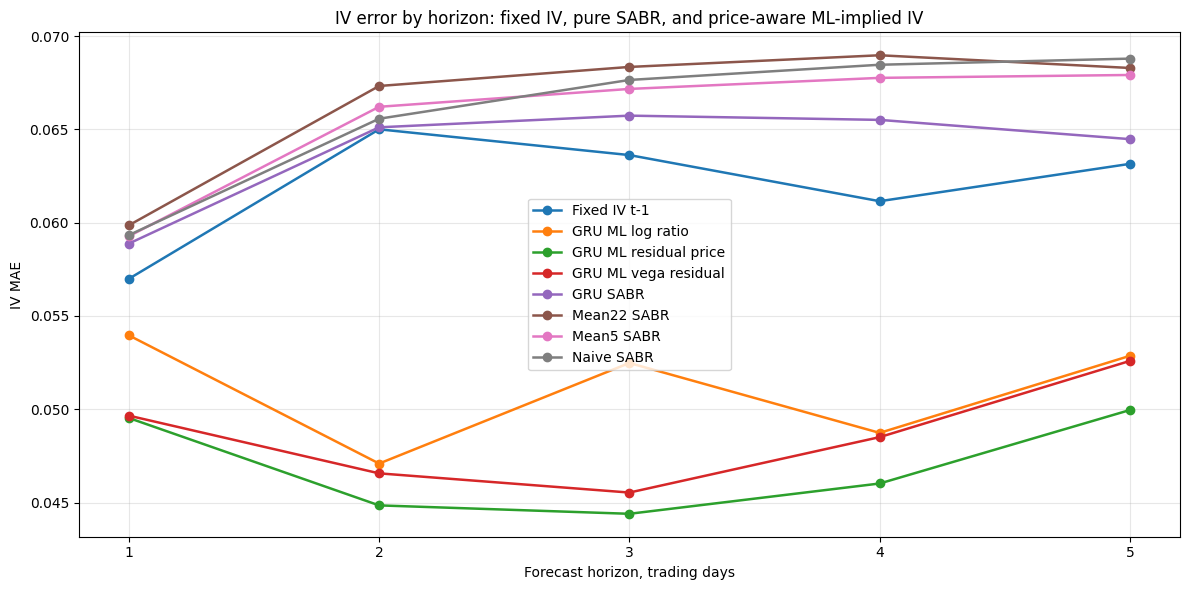

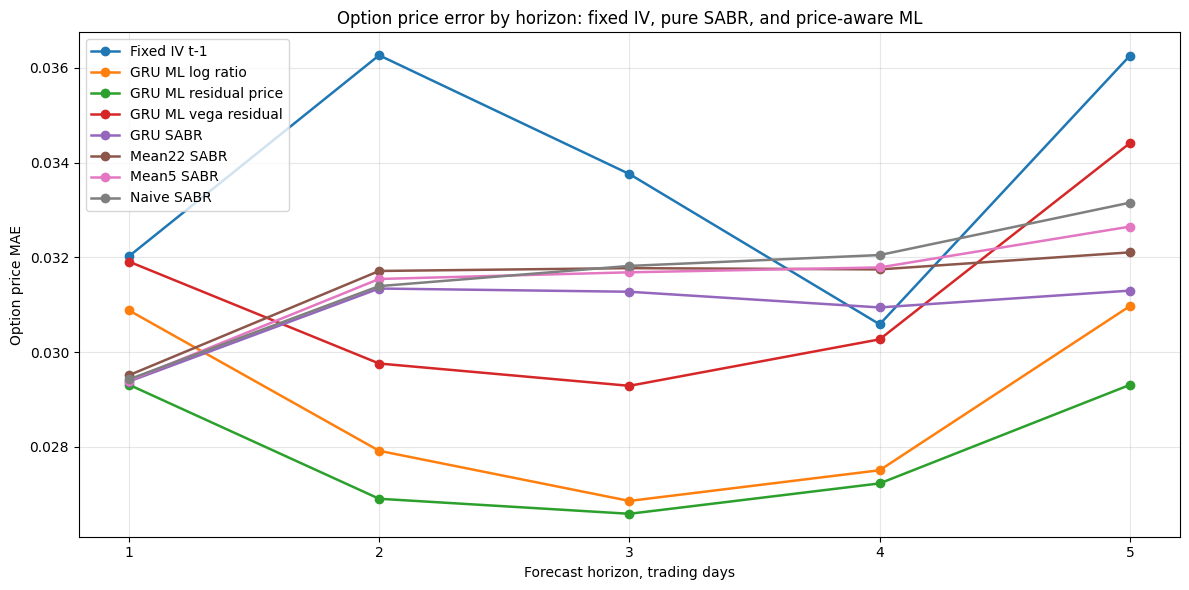


================ HORIZON IMPROVEMENT VS FIXED IV t-1 ================


,horizon_day,model,category,error_type,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,model_pretty,MAE_improvement_vs_fixed_tminus1_pct
0,1,ml_iv_from_price_residual_price_global_sigma_naive_h5_ann,Price-aware ML,IV,1200,0.045712,0.065030,0.009722,0.031298,21.387332,ML IV residual price global naive,19.791749
1,1,ml_iv_from_price_vega_residual_global_sigma_naive_h5_ann,Price-aware ML,IV,1206,0.046721,0.064364,0.011943,0.033912,21.854076,ML IV vega residual global naive,18.021296
2,1,ml_iv_from_price_residual_price_global_sigma_mean5_h5_ann,Price-aware ML,IV,1204,0.049184,0.068426,0.014841,0.036596,23.012348,ML IV residual price global mean5,13.698915
3,1,ml_iv_from_price_residual_price_global_sigma_mean22_h5_ann,Price-aware ML,IV,1202,0.049264,0.068629,0.014688,0.035839,23.072327,ML IV residual price global mean22,13.559608
4,1,ml_iv_from_price_vega_residual_global_sigma_mean5_h5_ann,Price-aware ML,IV,1205,0.049318,0.066910,0.015018,0.037377,23.072911,ML IV vega residual global mean5,13.464486
...,...,...,...,...,...,...,...,...,...,...,...,...
245,5,pred_price_quad_sigma_naive_h5_ann,Pure quadratic,PRICE,807,0.039392,0.093523,0.000926,0.025713,18.098894,quad naive,-8.635616
246,5,pred_price_flat_sigma_gru_h5_ann,Pure flat,PRICE,807,0.041442,0.053910,-0.035818,0.032428,19.040645,flat gru,-14.288323
247,5,pred_price_flat_sigma_mean22_h5_ann,Pure flat,PRICE,807,0.049284,0.062266,-0.047270,0.040737,22.643887,flat mean22,-35.916188
248,5,pred_price_flat_sigma_mean5_h5_ann,Pure flat,PRICE,807,0.049864,0.065460,-0.043940,0.037777,22.910223,flat mean5,-37.514827



Saved:
outputs/full_oos_error_by_horizon_1_5_fixed_pure_priceaware_metrics.csv
outputs/full_oos_error_by_horizon_1_5_fixed_pure_priceaware_predictions.csv


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print


HORIZONS_TO_PLOT = [1, 2, 3, 4, 5]


PURE_KINDS_FOR_HORIZON = ["flat", "quad", "sabr"]


PLOT_READABLE_SUBSET = True

PRICEAWARE_REFIT_ON_TRAIN_PLUS_VALIDATION = True
PRICEAWARE_USE_BY_CP = False

PRICEAWARE_TARGET_SPECS = [
    ("residual_price", "target_residual_price"),
    ("log_price_ratio", "target_log_price_ratio"),
    ("vega_residual", "target_vega_residual"),
]

required_objects = [
    "df",
    "df_signal",
    "rv_cols_existing",
    "CONTRACT_KEYS",
    "add_pricing_state",
    "add_fixed_iv_tminus1_benchmark",
    "compute_forecasts_for_sigma",
    "prepare_priceaware_dataset",
    "fit_priceaware_residual_model",
    "apply_priceaware_correction",
    "gk_iv_vec",
]

missing_objects = [x for x in required_objects if x not in globals()]

if missing_objects:
    raise ValueError(
        "Run the main 5D forecast cell and the full price-aware comparison cell first. "
        "Missing objects: " + ", ".join(missing_objects)
    )

year_start = pd.Timestamp(f"{EVAL_YEAR}-01-01")
year_end = pd.Timestamp(f"{EVAL_YEAR + 1}-01-01")
valid_start = year_start + pd.DateOffset(months=TRAIN_MONTHS)
oos_start = valid_start + pd.DateOffset(months=VALIDATION_MONTHS)


def ensure_trade_date_ranks_for_horizon(signal_df, target_df):
    signal = signal_df.copy()
    target = target_df.copy()

    all_dates = (
        pd.Series(
            pd.concat([signal[DATE_COL], target[DATE_COL]], ignore_index=True)
            .dropna()
            .unique()
        )
        .sort_values()
        .reset_index(drop=True)
    )

    date_rank = pd.DataFrame({
        DATE_COL: all_dates,
        "trade_date_rank_tmp": np.arange(len(all_dates)),
    })

    signal = signal.drop(columns=["trade_date_rank_tmp"], errors="ignore")
    target = target.drop(columns=["trade_date_rank_tmp"], errors="ignore")

    signal = signal.merge(date_rank, on=DATE_COL, how="left")
    target = target.merge(date_rank, on=DATE_COL, how="left")

    rank_to_date = dict(zip(date_rank["trade_date_rank_tmp"], date_rank[DATE_COL]))

    return signal, target, rank_to_date


def build_horizon_eval_df(signal_df, target_source_df, horizon):
    signal, target_source, rank_to_date = ensure_trade_date_ranks_for_horizon(
        signal_df,
        target_source_df,
    )

    signal = signal.copy()

    signal["target_trade_date_h"] = signal["trade_date_rank_tmp"].map(
        lambda x: rank_to_date.get(x + horizon, pd.NaT)
    )

    target_cols = [
        "market_price",
        "iv",
        "spot_for_pricing",
        "forward_for_pricing",
        "T_model",
        "T_days",
        "rd",
        "rf",
        "moneyness",
    ]

    target_cols = [c for c in target_cols if c in target_source.columns]

    future = (
        target_source[CONTRACT_KEYS + [DATE_COL] + target_cols]
        .copy()
        .rename(columns={DATE_COL: "target_trade_date_h"})
    )

    rename_map = {c: f"target_{c}_h" for c in target_cols}
    future = future.rename(columns=rename_map)

    group_cols = CONTRACT_KEYS + ["target_trade_date_h"]
    value_cols = [c for c in future.columns if c not in group_cols]

    future = (
        future
        .groupby(group_cols, as_index=False)[value_cols]
        .median()
    )

    out = signal.merge(
        future,
        on=CONTRACT_KEYS + ["target_trade_date_h"],
        how="left",
    )

    out["horizon_day"] = horizon

    out = out[
        out["target_trade_date_h"].notna()
        & np.isfinite(out["target_market_price_h"]) & (out["target_market_price_h"] > 0)
        & np.isfinite(out["target_iv_h"]) & (out["target_iv_h"] > IV_MIN) & (out["target_iv_h"] < IV_MAX)
    ].copy()

    return out


def alias_horizon_target_cols(df_in):
\
\
\

    out = df_in.copy()

    out["target_trade_date_h5"] = out["target_trade_date_h"]

    for c in list(out.columns):
        if c.startswith("target_") and c.endswith("_h"):
            out[c.replace("_h", "_h5")] = out[c]

    return out


def calc_horizon_metrics(df_in, pred_col, target_col, horizon, error_type, category):
    d = (
        df_in[[pred_col, target_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    if len(d) == 0:
        return {
            "horizon_day": horizon,
            "model": pred_col,
            "category": category,
            "error_type": error_type,
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "MedianAE": np.nan,
            "WMAPE_pct": np.nan,
        }

    err = d[pred_col] - d[target_col]

    return {
        "horizon_day": horizon,
        "model": pred_col,
        "category": category,
        "error_type": error_type,
        "n": int(len(d)),
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "Bias": float(np.mean(err)),
        "MedianAE": float(np.median(np.abs(err))),
        "WMAPE_pct": float(100 * np.sum(np.abs(err)) / max(np.sum(np.abs(d[target_col])), EPS)),
    }


def horizon_model_category(model_name):
    if model_name in ["bench_iv_fixed_tminus1", "bench_price_fixed_tminus1"]:
        return "Fixed IV t-1"

    if "_flat_" in model_name:
        return "Pure flat"

    if "_quad_" in model_name:
        return "Pure quadratic"

    if "_sabr_" in model_name:
        return "Pure SABR"

    if model_name.startswith("ml_iv_") or model_name.startswith("ml_price_"):
        return "Price-aware ML"

    return "Other"


def pretty_model_name(model):
    name = model

    replacements = {
        "bench_iv_fixed_tminus1": "Fixed IV t-1",
        "bench_price_fixed_tminus1": "Fixed IV t-1",

        "pred_iv_sabr_sigma_gru_h5_ann": "GRU SABR",
        "pred_price_sabr_sigma_gru_h5_ann": "GRU SABR",

        "pred_iv_sabr_sigma_mean22_h5_ann": "Mean22 SABR",
        "pred_price_sabr_sigma_mean22_h5_ann": "Mean22 SABR",

        "pred_iv_sabr_sigma_mean5_h5_ann": "Mean5 SABR",
        "pred_price_sabr_sigma_mean5_h5_ann": "Mean5 SABR",

        "pred_iv_sabr_sigma_naive_h5_ann": "Naive SABR",
        "pred_price_sabr_sigma_naive_h5_ann": "Naive SABR",

        "ml_iv_from_price_residual_price_global_sigma_gru_h5_ann": "GRU ML residual price",
        "ml_price_residual_price_global_sigma_gru_h5_ann": "GRU ML residual price",

        "ml_iv_from_price_log_price_ratio_global_sigma_gru_h5_ann": "GRU ML log ratio",
        "ml_price_log_price_ratio_global_sigma_gru_h5_ann": "GRU ML log ratio",

        "ml_iv_from_price_vega_residual_global_sigma_gru_h5_ann": "GRU ML vega residual",
        "ml_price_vega_residual_global_sigma_gru_h5_ann": "GRU ML vega residual",
    }

    if name in replacements:
        return replacements[name]

    name = name.replace("ml_iv_from_price_", "ML IV ")
    name = name.replace("ml_price_", "ML price ")

    name = name.replace("pred_iv_", "")
    name = name.replace("pred_price_", "")

    name = name.replace("sigma_", "")
    name = name.replace("_h5_ann", "")
    name = name.replace("_", " ")

    return name


all_horizon_metrics = []
all_horizon_predictions = []

for h in HORIZONS_TO_PLOT:
    print(f"\n================ HORIZON t+{h} ================")


    RV_HORIZON_DAYS = h

    h_df = build_horizon_eval_df(
        signal_df=df_signal.copy(),
        target_source_df=df.copy(),
        horizon=h,
    )


    h_train_part = h_df[
        (h_df["target_trade_date_h"] >= year_start)
        & (h_df["target_trade_date_h"] < oos_start)
    ].copy()

    h_oos_part = h_df[
        (h_df["target_trade_date_h"] >= oos_start)
        & (h_df["target_trade_date_h"] < year_end)
    ].copy()

    if len(h_train_part) == 0 or len(h_oos_part) == 0:
        print(f"Skipped horizon {h}: empty train or OOS.")
        continue

    h_train_part = alias_horizon_target_cols(h_train_part).reset_index(drop=True)
    h_oos_part = alias_horizon_target_cols(h_oos_part).reset_index(drop=True)


    h_oos_full = add_pricing_state(h_oos_part.copy(), mode=PRICE_STATE_MODE)
    h_oos_full = add_fixed_iv_tminus1_benchmark(h_oos_full)

    iv_cols_h = ["bench_iv_fixed_tminus1"]
    price_cols_h = ["bench_price_fixed_tminus1"]


    for sig_col in rv_cols_existing:
        print(f"  Processing {sig_col}")


        h_oos_full = compute_forecasts_for_sigma(h_oos_full, sig_col)

        for kind in PURE_KINDS_FOR_HORIZON:
            iv_col = f"pred_iv_{kind}_{sig_col}"
            price_col = f"pred_price_{kind}_{sig_col}"

            if iv_col in h_oos_full.columns:
                iv_cols_h.append(iv_col)

            if price_col in h_oos_full.columns:
                price_cols_h.append(price_col)


        train_sig = prepare_priceaware_dataset(h_train_part.copy(), sig_col)
        oos_sig = prepare_priceaware_dataset(h_oos_part.copy(), sig_col)

        if len(train_sig) == 0 or len(oos_sig) == 0:
            print(f"    Skipped ML for {sig_col}: empty prepared train or OOS.")
            continue

        for spec_key, target_col in PRICEAWARE_TARGET_SPECS:
            by_cp_options = [False, True] if PRICEAWARE_USE_BY_CP else [False]

            for by_cp in by_cp_options:
                cp_suffix = "byCP" if by_cp else "global"

                fitted = fit_priceaware_residual_model(
                    train_sig,
                    target_col=target_col,
                    by_option_type=by_cp,
                )

                if len(fitted["models"]) == 0:
                    print(f"    Skipped {spec_key}_{cp_suffix}: no fitted models.")
                    continue

                ml_price_col = f"ml_price_{spec_key}_{cp_suffix}_{sig_col}"
                ml_iv_col = f"ml_iv_from_price_{spec_key}_{cp_suffix}_{sig_col}"

                pred_tmp = apply_priceaware_correction(
                    oos_sig.copy(),
                    fitted,
                    pred_price_col=ml_price_col,
                )

                pred_tmp[ml_iv_col] = gk_iv_vec(
                    pred_tmp[ml_price_col],
                    pred_tmp["pricing_spot"],
                    pred_tmp["strike"],
                    pred_tmp["pricing_T"],
                    pred_tmp["pricing_rd"],
                    pred_tmp["pricing_rf"],
                    pred_tmp["option_type"],
                ).values


                h_oos_full.loc[pred_tmp.index, ml_price_col] = pred_tmp[ml_price_col]
                h_oos_full.loc[pred_tmp.index, ml_iv_col] = pred_tmp[ml_iv_col]

                price_cols_h.append(ml_price_col)
                iv_cols_h.append(ml_iv_col)

    iv_cols_h = list(dict.fromkeys(iv_cols_h))
    price_cols_h = list(dict.fromkeys(price_cols_h))


    for c in iv_cols_h:
        all_horizon_metrics.append(
            calc_horizon_metrics(
                h_oos_full,
                pred_col=c,
                target_col="target_iv_h5",
                horizon=h,
                error_type="IV",
                category=horizon_model_category(c),
            )
        )

    for c in price_cols_h:
        all_horizon_metrics.append(
            calc_horizon_metrics(
                h_oos_full,
                pred_col=c,
                target_col="target_market_price_h5",
                horizon=h,
                error_type="PRICE",
                category=horizon_model_category(c),
            )
        )

    keep_cols = (
        CONTRACT_KEYS
        + [
            DATE_COL,
            "target_trade_date_h",
            "horizon_day",
            "target_iv_h5",
            "target_market_price_h5",
        ]
        + iv_cols_h
        + price_cols_h
    )

    keep_cols = [c for c in keep_cols if c in h_oos_full.columns]
    keep_cols = list(dict.fromkeys(keep_cols))

    all_horizon_predictions.append(h_oos_full[keep_cols].copy())

    print("  OOS rows:", len(h_oos_full))


horizon_full_metrics = pd.DataFrame(all_horizon_metrics)

if len(all_horizon_predictions) > 0:
    horizon_full_predictions = pd.concat(all_horizon_predictions, ignore_index=True)
else:
    horizon_full_predictions = pd.DataFrame()

horizon_full_metrics["model_pretty"] = horizon_full_metrics["model"].apply(pretty_model_name)

print("\n================ FULL HORIZON METRICS 1-5 ================")
display(
    horizon_full_metrics
    .sort_values(["error_type", "horizon_day", "MAE"])
    .reset_index(drop=True)
)


if PLOT_READABLE_SUBSET:
    iv_models_to_plot = [
        "bench_iv_fixed_tminus1",

        "pred_iv_sabr_sigma_gru_h5_ann",
        "pred_iv_sabr_sigma_mean22_h5_ann",
        "pred_iv_sabr_sigma_mean5_h5_ann",
        "pred_iv_sabr_sigma_naive_h5_ann",

        "ml_iv_from_price_residual_price_global_sigma_gru_h5_ann",
        "ml_iv_from_price_log_price_ratio_global_sigma_gru_h5_ann",
        "ml_iv_from_price_vega_residual_global_sigma_gru_h5_ann",
    ]

    price_models_to_plot = [
        "bench_price_fixed_tminus1",

        "pred_price_sabr_sigma_gru_h5_ann",
        "pred_price_sabr_sigma_mean22_h5_ann",
        "pred_price_sabr_sigma_mean5_h5_ann",
        "pred_price_sabr_sigma_naive_h5_ann",

        "ml_price_residual_price_global_sigma_gru_h5_ann",
        "ml_price_log_price_ratio_global_sigma_gru_h5_ann",
        "ml_price_vega_residual_global_sigma_gru_h5_ann",
    ]
else:
    iv_models_to_plot = (
        horizon_full_metrics[horizon_full_metrics["error_type"] == "IV"]
        .groupby("model")["MAE"]
        .mean()
        .sort_values()
        .head(12)
        .index
        .tolist()
    )

    price_models_to_plot = (
        horizon_full_metrics[horizon_full_metrics["error_type"] == "PRICE"]
        .groupby("model")["MAE"]
        .mean()
        .sort_values()
        .head(12)
        .index
        .tolist()
    )


iv_models_to_plot = [
    m for m in iv_models_to_plot
    if m in set(horizon_full_metrics["model"])
]

price_models_to_plot = [
    m for m in price_models_to_plot
    if m in set(horizon_full_metrics["model"])
]


iv_plot_df = horizon_full_metrics[
    (horizon_full_metrics["error_type"] == "IV")
    & (horizon_full_metrics["model"].isin(iv_models_to_plot))
].copy()

plt.figure(figsize=(12, 6))

for model, g in iv_plot_df.groupby("model"):
    g = g.sort_values("horizon_day")

    plt.plot(
        g["horizon_day"],
        g["MAE"],
        marker="o",
        linewidth=1.8,
        label=pretty_model_name(model),
    )

plt.xlabel("Forecast horizon, trading days")
plt.ylabel("IV MAE")
plt.title("IV error by horizon: fixed IV, pure SABR, and price-aware ML-implied IV")
plt.xticks(HORIZONS_TO_PLOT)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


price_plot_df = horizon_full_metrics[
    (horizon_full_metrics["error_type"] == "PRICE")
    & (horizon_full_metrics["model"].isin(price_models_to_plot))
].copy()

plt.figure(figsize=(12, 6))

for model, g in price_plot_df.groupby("model"):
    g = g.sort_values("horizon_day")

    plt.plot(
        g["horizon_day"],
        g["MAE"],
        marker="o",
        linewidth=1.8,
        label=pretty_model_name(model),
    )

plt.xlabel("Forecast horizon, trading days")
plt.ylabel("Option price MAE")
plt.title("Option price error by horizon: fixed IV, pure SABR, and price-aware ML")
plt.xticks(HORIZONS_TO_PLOT)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


def add_improvement_vs_fixed_by_horizon(group):
    group = group.copy()

    if group["error_type"].iloc[0] == "IV":
        bench_model = "bench_iv_fixed_tminus1"
    else:
        bench_model = "bench_price_fixed_tminus1"

    bench = group.loc[group["model"] == bench_model, "MAE"]

    if len(bench) == 0 or not np.isfinite(bench.iloc[0]):
        group["MAE_improvement_vs_fixed_tminus1_pct"] = np.nan
    else:
        b = bench.iloc[0]
        group["MAE_improvement_vs_fixed_tminus1_pct"] = 100 * (b - group["MAE"]) / max(b, EPS)

    return group


horizon_full_metrics_improvement = (
    horizon_full_metrics
    .groupby(["error_type", "horizon_day"], group_keys=False)
    .apply(add_improvement_vs_fixed_by_horizon)
    .reset_index(drop=True)
)

print("\n================ HORIZON IMPROVEMENT VS FIXED IV t-1 ================")
display(
    horizon_full_metrics_improvement
    .sort_values(["error_type", "horizon_day", "MAE"])
    .reset_index(drop=True)
)


out_horizon_full_metrics = f"{OUT_DIR}/full_oos_error_by_horizon_1_5_fixed_pure_priceaware_metrics.csv"
out_horizon_full_predictions = f"{OUT_DIR}/full_oos_error_by_horizon_1_5_fixed_pure_priceaware_predictions.csv"

horizon_full_metrics_improvement.to_csv(out_horizon_full_metrics, index=False)

if len(horizon_full_predictions) > 0:
    horizon_full_predictions.to_csv(out_horizon_full_predictions, index=False)

print("\nSaved:")
print(out_horizon_full_metrics)
if len(horizon_full_predictions) > 0:
    print(out_horizon_full_predictions)


In [18]:
EXCLUDE_MODEL_PATTERNS = [
    "sigma_mean22",
    "sigma_mean5",
    "sigma_naive",
]

def keep_only_benchmark_and_gru_model_name(model):
    if model in ["bench_iv_fixed_tminus1", "bench_price_fixed_tminus1"]:
        return True

    if any(pattern in model for pattern in EXCLUDE_MODEL_PATTERNS):
        return False

    if "sigma_gru" in model:
        return True

    return False


if "daily_metrics" in globals():
    daily_metrics_gru_only = daily_metrics[
        daily_metrics["model"].apply(keep_only_benchmark_and_gru_model_name)
    ].copy()

    print("Filtered daily_metrics:")
    display(
        daily_metrics_gru_only
        .sort_values(["error_type", "horizon_day", "MAE"])
        .reset_index(drop=True)
    )

if "avg5_metrics" in globals():
    avg5_metrics_gru_only = avg5_metrics[
        avg5_metrics["model"].apply(keep_only_benchmark_and_gru_model_name)
    ].copy()

    print("Filtered avg5_metrics:")
    display(
        avg5_metrics_gru_only
        .sort_values(["error_type", "MAE"])
        .reset_index(drop=True)
    )


Filtered daily_metrics:


,model,target,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,horizon_day,error_type
0,ml_iv_from_price_residual_price_global_sigma_gru_h5_ann,target_iv_h5,1199,0.049536,0.071109,0.006075,0.035965,23.197748,1,IV
1,ml_iv_from_price_vega_residual_global_sigma_gru_h5_ann,target_iv_h5,1205,0.049661,0.067376,0.011254,0.036969,23.236967,1,IV
2,ml_iv_from_price_log_price_ratio_global_sigma_gru_h5_ann,target_iv_h5,1206,0.053963,0.085283,-0.000745,0.035190,25.241671,1,IV
3,bench_iv_fixed_tminus1,target_iv_h5,1206,0.056991,0.094567,-0.014270,0.034334,26.658236,1,IV
4,pred_iv_sabr_sigma_gru_h5_ann,target_iv_h5,1206,0.058879,0.100827,-0.028049,0.035313,27.541194,1,IV
...,...,...,...,...,...,...,...,...,...,...
65,pred_price_sabr_sigma_gru_h5_ann,target_market_price_h5,807,0.031299,0.042853,-0.011288,0.022438,14.380591,5,PRICE
66,ml_price_vega_residual_global_sigma_gru_h5_ann,target_market_price_h5,807,0.034414,0.045824,0.019202,0.026055,15.811597,5,PRICE
67,bench_price_fixed_tminus1,target_market_price_h5,807,0.036261,0.090208,0.006495,0.022712,16.660184,5,PRICE
68,pred_price_quad_sigma_gru_h5_ann,target_market_price_h5,807,0.037688,0.092855,0.001999,0.022112,17.316180,5,PRICE


Filtered avg5_metrics:


,model,target,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct,error_type,avg_horizons_required,mean_available_horizons
0,ml_iv_from_price_residual_price_global_sigma_gru_h5_ann,avg_1_5_target_iv_h5,310,0.027090,0.035728,0.012990,0.020106,13.964114,IV,True,5.0
1,ml_iv_from_price_log_price_ratio_global_sigma_gru_h5_ann,avg_1_5_target_iv_h5,311,0.027375,0.037612,0.004010,0.019531,14.098993,IV,True,5.0
2,ml_iv_from_price_vega_residual_global_sigma_gru_h5_ann,avg_1_5_target_iv_h5,311,0.029397,0.037911,0.017673,0.025449,15.139935,IV,True,5.0
3,pred_iv_quad_sigma_gru_h5_ann,avg_1_5_target_iv_h5,311,0.032424,0.050320,-0.012559,0.020837,16.698939,IV,True,5.0
4,bench_iv_fixed_tminus1,avg_1_5_target_iv_h5,311,0.034732,0.054162,-0.011752,0.021945,17.887948,IV,True,5.0
5,pred_iv_sabr_sigma_gru_h5_ann,avg_1_5_target_iv_h5,311,0.036149,0.054481,-0.021469,0.024860,18.617715,IV,True,5.0
6,pred_iv_flat_sigma_gru_h5_ann,avg_1_5_target_iv_h5,311,0.063558,0.079046,-0.061000,0.056409,32.734031,IV,True,5.0
7,ml_price_log_price_ratio_global_sigma_gru_h5_ann,avg_1_5_target_market_price_h5,311,0.017453,0.022466,0.002946,0.014897,9.179119,PRICE,True,5.0
8,ml_price_residual_price_global_sigma_gru_h5_ann,avg_1_5_target_market_price_h5,311,0.017472,0.022517,0.006417,0.014675,9.189397,PRICE,True,5.0
9,pred_price_quad_sigma_gru_h5_ann,avg_1_5_target_market_price_h5,311,0.018689,0.025205,-0.002229,0.013377,9.829141,PRICE,True,5.0


Using existing daily_metrics_gru_only
Using existing avg5_metrics_gru_only

IV models plotted:
- Fixed IV t-1
- GRU SABR
- GRU quadratic
- GRU flat
- GRU ML log ratio
- GRU ML residual price
- GRU ML vega residual

Price models plotted:
- Fixed IV t-1
- GRU SABR
- GRU quadratic
- GRU flat
- GRU ML log ratio
- GRU ML residual price
- GRU ML vega residual


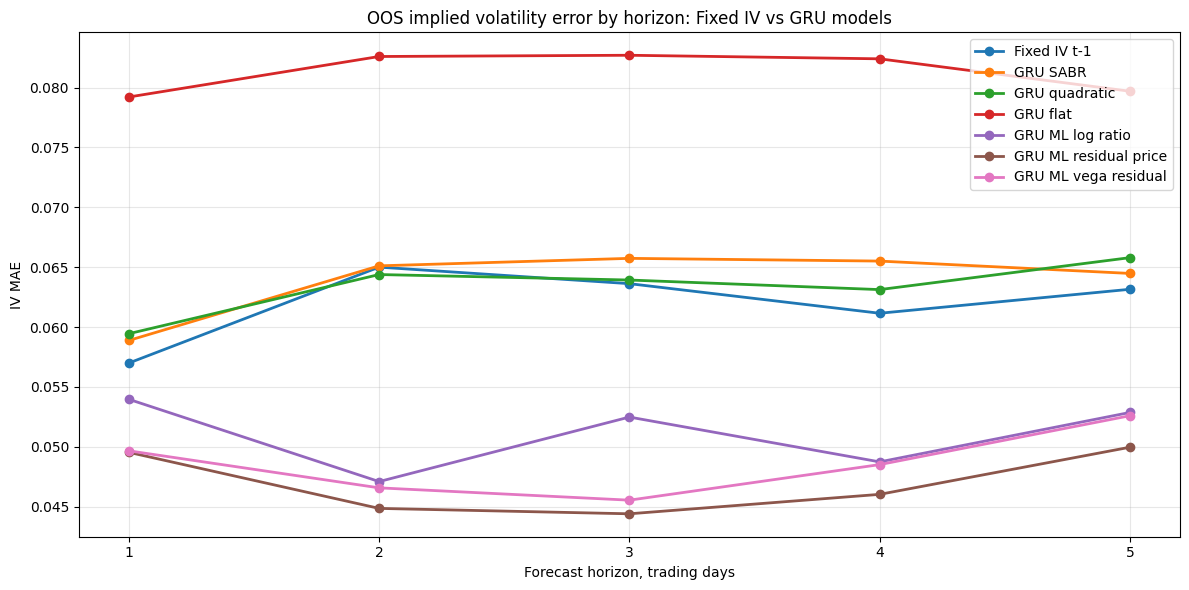

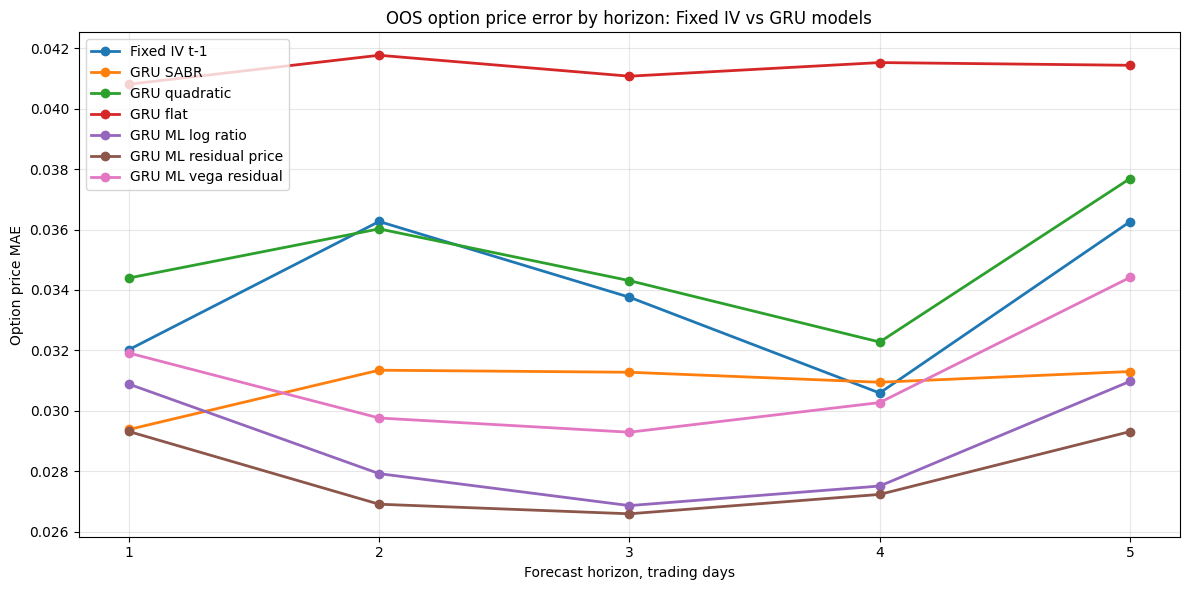

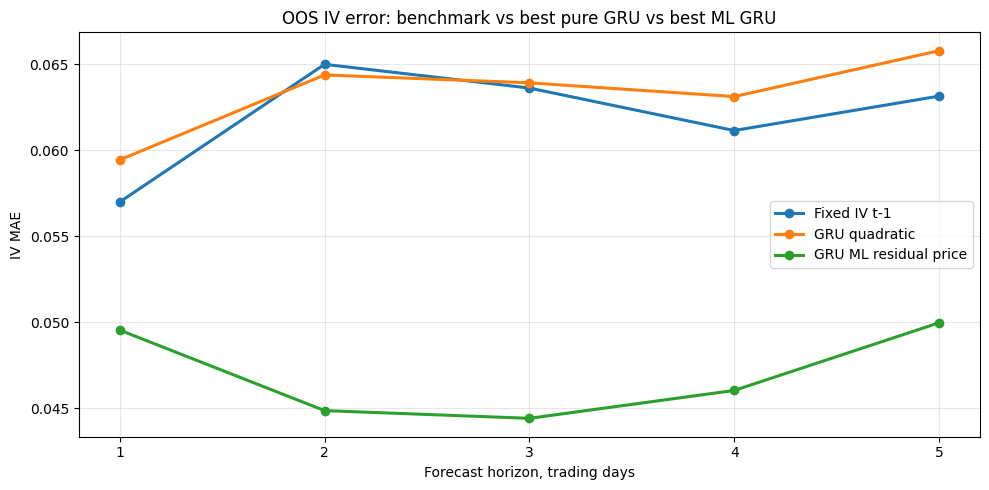

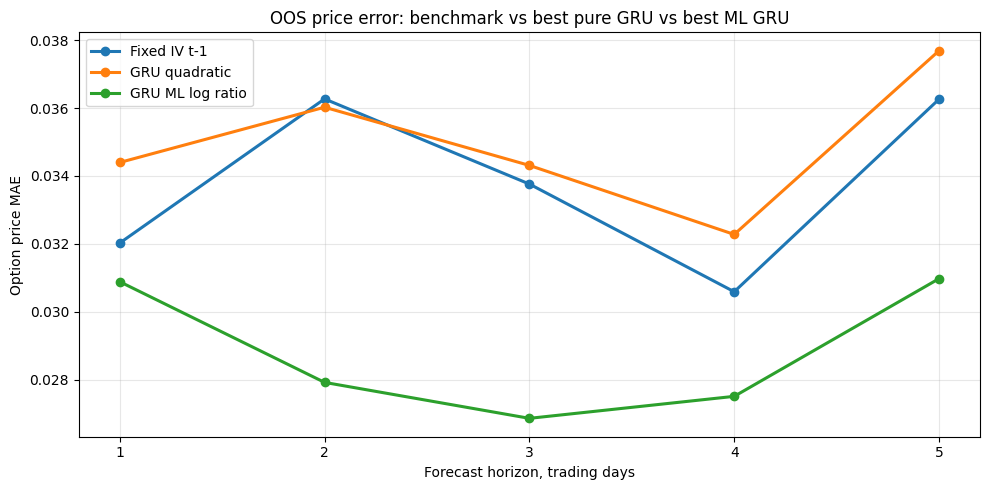


Filtered daily metrics used for plots:


,error_type,horizon_day,model_name,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct
5,IV,1,GRU ML residual price,1199,0.049536,0.071109,0.006075,0.035965,23.197748
6,IV,1,GRU ML vega residual,1205,0.049661,0.067376,0.011254,0.036969,23.236967
9,IV,1,GRU ML log ratio,1206,0.053963,0.085283,-0.000745,0.035190,25.241671
12,IV,1,Fixed IV t-1,1206,0.056991,0.094567,-0.014270,0.034334,26.658236
13,IV,1,GRU SABR,1206,0.058879,0.100827,-0.028049,0.035313,27.541194
...,...,...,...,...,...,...,...,...,...
234,PRICE,5,GRU SABR,807,0.031299,0.042853,-0.011288,0.022438,14.380591
239,PRICE,5,GRU ML vega residual,807,0.034414,0.045824,0.019202,0.026055,15.811597
241,PRICE,5,Fixed IV t-1,807,0.036261,0.090208,0.006495,0.022712,16.660184
242,PRICE,5,GRU quadratic,807,0.037688,0.092855,0.001999,0.022112,17.316180



Filtered average-over-1-5-days metrics:


,error_type,model_name,n,MAE,RMSE,Bias,MedianAE,WMAPE_pct
6,IV,GRU ML residual price,310,0.027090,0.035728,0.012990,0.020106,13.964114
7,IV,GRU ML log ratio,311,0.027375,0.037612,0.004010,0.019531,14.098993
10,IV,GRU ML vega residual,311,0.029397,0.037911,0.017673,0.025449,15.139935
12,IV,GRU quadratic,311,0.032424,0.050320,-0.012559,0.020837,16.698939
16,IV,Fixed IV t-1,311,0.034732,0.054162,-0.011752,0.021945,17.887948
17,IV,GRU SABR,311,0.036149,0.054481,-0.021469,0.024860,18.617715
21,IV,GRU flat,311,0.063558,0.079046,-0.061000,0.056409,32.734031
31,PRICE,GRU ML log ratio,311,0.017453,0.022466,0.002946,0.014897,9.179119
32,PRICE,GRU ML residual price,311,0.017472,0.022517,0.006417,0.014675,9.189397
34,PRICE,GRU quadratic,311,0.018689,0.025205,-0.002229,0.013377,9.829141


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

OUT_DIR_LOCAL = OUT_DIR if "OUT_DIR" in globals() else "/content"


daily_path = f"{OUT_DIR_LOCAL}/oos_daily_horizon_1_5_metrics_no_retrain.csv"
avg5_path = f"{OUT_DIR_LOCAL}/oos_average_over_1_5_days_metrics_no_retrain.csv"

if "daily_metrics_gru_only" in globals():
    plot_daily = daily_metrics_gru_only.copy()
    print("Using existing daily_metrics_gru_only")

elif "daily_metrics" in globals():
    plot_daily = daily_metrics.copy()
    print("Using existing daily_metrics")

elif os.path.exists(daily_path):
    plot_daily = pd.read_csv(daily_path)
    print("Loaded daily metrics from:", daily_path)

else:
    raise ValueError("-")

if "avg5_metrics_gru_only" in globals():
    plot_avg5 = avg5_metrics_gru_only.copy()
    print("Using existing avg5_metrics_gru_only")

elif "avg5_metrics" in globals():
    plot_avg5 = avg5_metrics.copy()
    print("Using existing avg5_metrics")

elif os.path.exists(avg5_path):
    plot_avg5 = pd.read_csv(avg5_path)
    print("Loaded avg5 metrics from:", avg5_path)

else:
    plot_avg5 = None
    print("avg5_metrics not found. Plots will use daily metrics only.")


def keep_only_benchmark_and_gru(model):
    model = str(model)

    if model in ["bench_iv_fixed_tminus1", "bench_price_fixed_tminus1"]:
        return True

    if "sigma_mean22" in model or "sigma_mean5" in model or "sigma_naive" in model:
        return False

    if "sigma_gru" in model:
        return True

    return False


plot_daily = plot_daily[
    plot_daily["model"].apply(keep_only_benchmark_and_gru)
].copy()

if plot_avg5 is not None:
    plot_avg5 = plot_avg5[
        plot_avg5["model"].apply(keep_only_benchmark_and_gru)
    ].copy()

plot_daily["horizon_day"] = pd.to_numeric(plot_daily["horizon_day"], errors="coerce")
plot_daily["MAE"] = pd.to_numeric(plot_daily["MAE"], errors="coerce")


def pretty_model_name(model):
    names = {
        "bench_iv_fixed_tminus1": "Fixed IV t-1",
        "bench_price_fixed_tminus1": "Fixed IV t-1",

        "pred_iv_sabr_sigma_gru_h5_ann": "GRU SABR",
        "pred_price_sabr_sigma_gru_h5_ann": "GRU SABR",

        "pred_iv_quad_sigma_gru_h5_ann": "GRU quadratic",
        "pred_price_quad_sigma_gru_h5_ann": "GRU quadratic",

        "pred_iv_flat_sigma_gru_h5_ann": "GRU flat",
        "pred_price_flat_sigma_gru_h5_ann": "GRU flat",

        "ml_iv_from_price_residual_price_global_sigma_gru_h5_ann": "GRU ML residual price",
        "ml_price_residual_price_global_sigma_gru_h5_ann": "GRU ML residual price",

        "ml_iv_from_price_log_price_ratio_global_sigma_gru_h5_ann": "GRU ML log ratio",
        "ml_price_log_price_ratio_global_sigma_gru_h5_ann": "GRU ML log ratio",

        "ml_iv_from_price_vega_residual_global_sigma_gru_h5_ann": "GRU ML vega residual",
        "ml_price_vega_residual_global_sigma_gru_h5_ann": "GRU ML vega residual",
    }

    return names.get(str(model), str(model))


iv_order = [
    "bench_iv_fixed_tminus1",

    "pred_iv_sabr_sigma_gru_h5_ann",
    "pred_iv_quad_sigma_gru_h5_ann",
    "pred_iv_flat_sigma_gru_h5_ann",

    "ml_iv_from_price_log_price_ratio_global_sigma_gru_h5_ann",
    "ml_iv_from_price_residual_price_global_sigma_gru_h5_ann",
    "ml_iv_from_price_vega_residual_global_sigma_gru_h5_ann",
]

price_order = [
    "bench_price_fixed_tminus1",

    "pred_price_sabr_sigma_gru_h5_ann",
    "pred_price_quad_sigma_gru_h5_ann",
    "pred_price_flat_sigma_gru_h5_ann",

    "ml_price_log_price_ratio_global_sigma_gru_h5_ann",
    "ml_price_residual_price_global_sigma_gru_h5_ann",
    "ml_price_vega_residual_global_sigma_gru_h5_ann",
]

existing_models = set(plot_daily["model"].dropna())

iv_order = [m for m in iv_order if m in existing_models]
price_order = [m for m in price_order if m in existing_models]

print("\nIV models plotted:")
for m in iv_order:
    print("-", pretty_model_name(m))

print("\nPrice models plotted:")
for m in price_order:
    print("-", pretty_model_name(m))


iv_plot = plot_daily[
    (plot_daily["error_type"] == "IV")
    & (plot_daily["model"].isin(iv_order))
].copy()

plt.figure(figsize=(12, 6))

for model in iv_order:
    g = iv_plot[iv_plot["model"] == model].sort_values("horizon_day")

    if len(g) == 0:
        continue

    plt.plot(
        g["horizon_day"],
        g["MAE"],
        marker="o",
        linewidth=2,
        label=pretty_model_name(model),
    )

plt.xlabel("Forecast horizon, trading days")
plt.ylabel("IV MAE")
plt.title("OOS implied volatility error by horizon: Fixed IV vs GRU models")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


price_plot = plot_daily[
    (plot_daily["error_type"] == "PRICE")
    & (plot_daily["model"].isin(price_order))
].copy()

plt.figure(figsize=(12, 6))

for model in price_order:
    g = price_plot[price_plot["model"] == model].sort_values("horizon_day")

    if len(g) == 0:
        continue

    plt.plot(
        g["horizon_day"],
        g["MAE"],
        marker="o",
        linewidth=2,
        label=pretty_model_name(model),
    )

plt.xlabel("Forecast horizon, trading days")
plt.ylabel("Option price MAE")
plt.title("OOS option price error by horizon: Fixed IV vs GRU models")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


def best_model_from_avg_or_daily(error_type, prefixes, benchmark):
    if plot_avg5 is not None and len(plot_avg5) > 0:
        source = plot_avg5[plot_avg5["error_type"] == error_type].copy()
    else:
        source = (
            plot_daily[plot_daily["error_type"] == error_type]
            .groupby("model", as_index=False)
            .agg(MAE=("MAE", "mean"), RMSE=("RMSE", "mean"))
        )

    mask = False
    for p in prefixes:
        mask = mask | source["model"].astype(str).str.startswith(p)

    d = source[
        mask
        & source["model"].apply(keep_only_benchmark_and_gru)
        & (source["model"] != benchmark)
    ].copy()

    if len(d) == 0:
        return None

    return d.sort_values(["MAE", "RMSE"]).iloc[0]["model"]


best_pure_iv = best_model_from_avg_or_daily(
    error_type="IV",
    prefixes=["pred_iv_"],
    benchmark="bench_iv_fixed_tminus1",
)

best_ml_iv = best_model_from_avg_or_daily(
    error_type="IV",
    prefixes=["ml_iv_from_price_"],
    benchmark="bench_iv_fixed_tminus1",
)

best_pure_price = best_model_from_avg_or_daily(
    error_type="PRICE",
    prefixes=["pred_price_"],
    benchmark="bench_price_fixed_tminus1",
)

best_ml_price = best_model_from_avg_or_daily(
    error_type="PRICE",
    prefixes=["ml_price_"],
    benchmark="bench_price_fixed_tminus1",
)

compact_iv_models = [
    "bench_iv_fixed_tminus1",
    best_pure_iv,
    best_ml_iv,
]

compact_price_models = [
    "bench_price_fixed_tminus1",
    best_pure_price,
    best_ml_price,
]

compact_iv_models = [m for m in compact_iv_models if m is not None]
compact_price_models = [m for m in compact_price_models if m is not None]


plt.figure(figsize=(10, 5))

for model in compact_iv_models:
    g = plot_daily[
        (plot_daily["error_type"] == "IV")
        & (plot_daily["model"] == model)
    ].sort_values("horizon_day")

    if len(g) == 0:
        continue

    plt.plot(
        g["horizon_day"],
        g["MAE"],
        marker="o",
        linewidth=2.2,
        label=pretty_model_name(model),
    )

plt.xlabel("Forecast horizon, trading days")
plt.ylabel("IV MAE")
plt.title("OOS IV error: benchmark vs best pure GRU vs best ML GRU")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

for model in compact_price_models:
    g = plot_daily[
        (plot_daily["error_type"] == "PRICE")
        & (plot_daily["model"] == model)
    ].sort_values("horizon_day")

    if len(g) == 0:
        continue

    plt.plot(
        g["horizon_day"],
        g["MAE"],
        marker="o",
        linewidth=2.2,
        label=pretty_model_name(model),
    )

plt.xlabel("Forecast horizon, trading days")
plt.ylabel("Option price MAE")
plt.title("OOS price error: benchmark vs best pure GRU vs best ML GRU")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


print("\nFiltered daily metrics used for plots:")
display(
    plot_daily
    .assign(model_name=plot_daily["model"].apply(pretty_model_name))
    .sort_values(["error_type", "horizon_day", "MAE"])
    [["error_type", "horizon_day", "model_name", "n", "MAE", "RMSE", "Bias", "MedianAE", "WMAPE_pct"]]
)

if plot_avg5 is not None:
    print("\nFiltered average-over-1-5-days metrics:")
    display(
        plot_avg5
        .assign(model_name=plot_avg5["model"].apply(pretty_model_name))
        .sort_values(["error_type", "MAE"])
        [["error_type", "model_name", "n", "MAE", "RMSE", "Bias", "MedianAE", "WMAPE_pct"]]
    )
